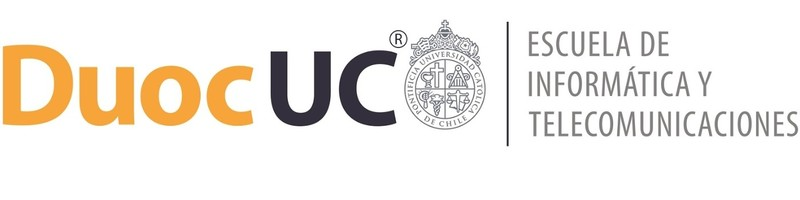

# Metodología CRISP-DM en Notebook
## Spotify Tracks: preparación, modelamiento supervisado y no supervisado

**Asignatura:** Machine Learning (MLY1101)
**Institución:** Duoc UC
**Evaluación:** Evaluación Parcial N.º 2 (continuación de la EP1)
**Integrantes:** Alejandra González, Constanza González, Diego Villar.

El proyecto estudia si los atributos medibles de una canción permiten anticipar su
popularidad en Spotify. La EP1 dejó una base limpia y un pipeline de preparación; esta
EP2 revisa y corrige esa base, entrena y compara **4 modelos de regresión**, **4 modelos
de clasificación** (con comparación de métodos de balanceo) y **2 modelos no
supervisados**, y traduce los resultados a recomendaciones de negocio.

### Metodología y alcance de la entrega

| Fase CRISP-DM | Contenido | Estado en EP2 |
|---|---|---|
| 1. Business Understanding | Problema, objetivos, KPIs (actualizados para EP2) | Completa |
| 2. Data Understanding | Carga, estructura, calidad y exploración inicial | Completa (EP1) |
| 3. Data Preparation | Limpieza, EDA, representación 1 canción = 1 fila, partición sin fuga, targets | Completa (corregida en EP2) |
| 4. Modeling | 4 regresiones, 4 clasificaciones + balanceo, K-Means y clustering jerárquico | **Nueva en EP2** |
| 5. Evaluation | Métricas en prueba, KPIs, sesgo por género, importancia de variables | **Nueva en EP2** |
| 6. Deployment | Modelos serializados, uso y plan de monitoreo | **Propuesta en EP2** |

CRISP-DM es iterativa: la revisión de la EP1 (sección 0) es justamente una vuelta a la
Fase 3 motivada por lo que exige el modelamiento.

> **Tiempo de ejecución:** "Restart & Run All" tarda aproximadamente 30–40 minutos en
> un equipo de 4 núcleos (la mayor parte corresponde a la validación cruzada de la
> Fase 4). Dependencias: `pip install -r requirements.txt`.

## 0. Revisión del notebook EP1 y correcciones aplicadas

Antes de modelar se revisó el notebook de la EP1 completo. Se mantienen sus reglas de
limpieza y su EDA (Fases 1–3), pero se detectaron los siguientes problemas, que se
corrigen en este notebook:

| # | Problema detectado en EP1 | Riesgo | Corrección en EP2 |
|---|---|---|---|
| 1 | El README planteaba **regresión** (MAE, RMSE, R²) y el notebook **clasificación** (accuracy, F1). | Objetivo y KPIs inconsistentes. | Se abordan ambos enfoques, tal como pide la pauta EP2, con KPIs unificados (sección 1.1). |
| 2 | Partición agrupada solo por `id_cancion`. Hay ~4.700 pares *artista + título* publicados con **IDs distintos** (reediciones, recopilatorios); cerca de la mitad tiene audio idéntico. | **Fuga de información**: la misma grabación puede quedar en train y en test con otro ID, inflando las métricas. | Partición y validación cruzada agrupadas por `clave_cancion` = artista + título normalizados (sección 3.12). |
| 3 | El pipeline usaba **una fila por canción-género**; la representación multi-género (1 canción = 1 fila) se construyó pero no se usó. | Canciones con varios géneros pesan más en el entrenamiento y en las métricas. | El modelamiento usa 1 canción = 1 fila con géneros *multi-hot* (sección 3.11). |
| 4 | `spotify_multigenero.csv` se construía desde `df_limpio`, con el compás **ya imputado** fuera del pipeline. | Imputación aprendida fuera de la validación cruzada. | Se construye desde `df_base` (compás sin imputar); la moda se aprende dentro del pipeline en cada pliegue. |
| 5 | Target de clasificación por **terciles** aprendidos en train (cortes ≈ 22 y 45). | "Alto" incluía canciones con popularidad 45, sin significado de negocio; clases artificialmente balanceadas que ocultan el desbalance real. | Umbrales de negocio fijos: bajo < 30, medio 30–59, alto ≥ 60 (sección 3.14). Al ser fijos, no se aprenden de los datos y no generan fuga. |
| 6 | `RUTA_DATOS = '../data/raw/...'` (ruta relativa fija). | Falla si el notebook no se ejecuta desde `notebooks/` (p. ej., Colab). | `RUTA_DATOS = None` por defecto: se usa la búsqueda automática de rutas candidatas. |
| 7 | Celdas de forma: "Conclusiones Fase 3" vacía, referencia a una celda "más abajo" que estaba arriba, código de sesgos antes de su título, celda que solo imprimía `sys.executable`. | Documentación incompleta. | Se completan y reordenan. |

Las reglas de limpieza de la EP1 (eliminación de 158 filas, imputación de álbum,
tratamiento de compás) **no cambian**: siguen justificadas y el balance de filas es el mismo.

## Fase 1: Business Understanding

---


### 1.1 Contexto, problema de negocio, objetivos y KPIs

### Problema de negocio
Un equipo de inteligencia musical necesita determinar si los **atributos medibles** de una
canción (características de audio, género y contenido explícito) permiten anticipar su
nivel de popularidad, para apoyar decisiones de curaduría editorial, armado de playlists y
promoción.

### Objetivo general
Desarrollar, comparar y evaluar modelos de Machine Learning que estimen la popularidad de
una canción, tanto como **valor continuo (regresión, 0–100)** como **nivel de popularidad
(clasificación: bajo / medio / alto)**, y descubrir mediante **aprendizaje no supervisado**
perfiles sonoros y familias de géneros útiles para la curaduría.

### Objetivos específicos
- **Analítico:** identificar qué atributos se asocian con mayor popularidad.
- **Regresión:** entrenar y comparar 4 algoritmos contra un baseline, con MAE, RMSE y R².
- **Clasificación:** entrenar y comparar 4 algoritmos, evaluando distintos métodos de
  balanceo de clases, con F1 macro, accuracy y recall de la clase "alto".
- **No supervisado:** (1) segmentar el catálogo en **perfiles sonoros** con K-Means;
  (2) agrupar los 114 géneros en **familias de géneros** con clustering jerárquico.
- **Ética:** cuantificar el error del modelo por género para detectar sesgos.

### KPIs
| KPI | Tipo | Umbral | Origen |
|-----|------|--------|--------|
| Cobertura de datos (filas conservadas) | Calidad | ≥ 99% | EP1 |
| Canciones (artista + título) compartidas entre train y test | Calidad | 0 | EP1, reforzado en EP2 |
| MAE | Regresión | < 10 puntos | EP1 (README) |
| RMSE | Regresión | < 15 puntos | EP1 (README) |
| R² | Regresión | > 0,20 | EP1 (README) |
| Accuracy | Clasificación | > 0,50 | EP1 (notebook) |
| F1 macro | Clasificación | > 0,45 | EP1 (notebook) |
| Recall de la clase "alto" | Clasificación | ≥ 0,60 | EP2: no dejar pasar posibles éxitos |
| Silhouette del K-Means | No supervisado | ≥ 0,15 | EP2: estructura de grupos al menos débil-moderada |

Todos los umbrales se fijan **antes** de mirar el conjunto de prueba. El modelo se
considera útil para el negocio si además **supera claramente al baseline** (predecir la
media o la clase más frecuente).

### 1.2 Fuente de datos y herramientas colaborativas

**Fuente:** Spotify_Tracks_Dataset.csv — Kaggle (*Spotify Tracks Dataset*, MaharshiPandya).

**Limitación:** sin fecha de extracción ni versión de API. La popularidad puede estar desactualizada.

| Herramienta | Uso |
|-------------|-----|
| Python / pandas / numpy | Manipulación de datos |
| matplotlib / seaborn | Visualización |
| scikit-learn | Pipeline ML |
| Jupyter Notebook | Documentación reproducible |
| Git / GitHub | Control de versiones grupal |
| Google Colab | Ejecución compartida |


### 1.3 Datos disponibles y diccionario de variables

| Variable | Tipo | Rol | Descripción |
|----------|------|-----|-------------|
| id_cancion | Texto | Identificador | ID único de Spotify — excluir del modelo |
| artistas | Texto | Metadato | Nombre(s) del artista |
| nombre_album | Texto | Metadato | Nombre del álbum |
| nombre_cancion | Texto | Metadato | Nombre de la canción |
| popularidad | Numérica (int) | **TARGET** | Popularidad 0–100 |
| duracion_ms | Numérica | Feature | Duración en ms |
| contenido_explicito | Booleana | Feature | Contenido explícito |
| bailabilidad | Float 0–1 | Feature | Aptitud para bailar |
| energia | Float 0–1 | Feature | Intensidad percibida |
| tonalidad | Categórica | Feature | Tonalidad (0=C…11=B) |
| volumen_db | Float (dB) | Feature | Volumen promedio |
| modo | Categórica | Feature | Mayor(1)/Menor(0) |
| presencia_habla | Float 0–1 | Feature | Presencia de voz hablada |
| acusticidad | Float 0–1 | Feature | Nivel acústico |
| instrumentalidad | Float 0–1 | Feature | Nivel instrumental |
| presencia_en_vivo | Float 0–1 | Feature | Presencia de audiencia en vivo |
| positividad | Float 0–1 | Feature | Positividad musical |
| tempo_bpm | Float (BPM) | Feature | Velocidad |
| compas | Categórica | Feature | Compás musical |
| genero_musical | Categórica | Feature | Género musical (cantidad calculada al ejecutar) |

> **Nota:** tonalidad, modo y compas son **códigos musicales**, no magnitudes. Se tratarán como categóricas.

### Equivalencias con el archivo original

| Original | Español |
|---|---|
| track_id | id_cancion |
| artists | artistas |
| album_name | nombre_album |
| track_name | nombre_cancion |
| popularity | popularidad |
| duration_ms | duracion_ms |
| explicit | contenido_explicito |
| danceability | bailabilidad |
| energy | energia |
| key | tonalidad |
| loudness | volumen_db |
| mode | modo |
| speechiness | presencia_habla |
| acousticness | acusticidad |
| instrumentalness | instrumentalidad |
| liveness | presencia_en_vivo |
| valence | positividad |
| tempo | tempo_bpm |
| time_signature | compas |
| track_genre | genero_musical |


### 1.4 Criterio de éxito

La entrega es exitosa si: (1) la base de modelamiento no tiene nulos ni fuga de
información entre entrenamiento y prueba; (2) al menos un modelo de regresión y uno de
clasificación superan al baseline y cumplen los KPIs de la sección 1.1, evaluados una sola
vez sobre el conjunto de prueba; (3) los modelos no supervisados entregan grupos
interpretables y accionables para la curaduría; y (4) se documentan los sesgos y
limitaciones observados.

## Fase 2: Data Understanding


### 2.1 Importaciones, traducción de variables y configuración

Los nombres se traducen al español desde la carga, antes de generar tablas o
gráficos. El CSV original no se modifica. Todas las librerías del proyecto se
importan en esta celda para que el notebook sea reproducible de principio a fin.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_validate
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer, silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
)
from imblearn.pipeline import Pipeline as PipelineImb
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from scipy.cluster.hierarchy import linkage, dendrogram
import joblib
import time
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
SEMILLA = 42

pd.set_option('display.max_columns', None)
# display() está disponible en Jupyter y Google Colab.
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Nombres de datos en español desde la primera lectura del CSV.
# Sin tildes ni espacios en el código; etiquetas legibles para la presentación.
COLUMNAS_ESPANOL = {
    'track_id': 'id_cancion', 'artists': 'artistas',
    'album_name': 'nombre_album', 'track_name': 'nombre_cancion',
    'popularity': 'popularidad', 'duration_ms': 'duracion_ms',
    'explicit': 'contenido_explicito', 'danceability': 'bailabilidad',
    'energy': 'energia', 'key': 'tonalidad', 'loudness': 'volumen_db',
    'mode': 'modo', 'speechiness': 'presencia_habla',
    'acousticness': 'acusticidad', 'instrumentalness': 'instrumentalidad',
    'liveness': 'presencia_en_vivo', 'valence': 'positividad',
    'tempo': 'tempo_bpm', 'time_signature': 'compas',
    'track_genre': 'genero_musical',
}
ETIQUETAS = {
    'id_cancion': 'ID de canción', 'artistas': 'Artistas',
    'nombre_album': 'Nombre del álbum', 'nombre_cancion': 'Nombre de la canción',
    'popularidad': 'Popularidad', 'duracion_ms': 'Duración (ms)',
    'duracion_min': 'Duración (min)', 'contenido_explicito': 'Contenido explícito',
    'bailabilidad': 'Bailabilidad', 'energia': 'Energía',
    'tonalidad': 'Tonalidad', 'volumen_db': 'Volumen (dB)', 'modo': 'Modo musical',
    'presencia_habla': 'Presencia de habla', 'acusticidad': 'Acusticidad',
    'instrumentalidad': 'Instrumentalidad', 'presencia_en_vivo': 'Presencia en vivo',
    'positividad': 'Positividad musical', 'tempo_bpm': 'Tempo (BPM)',
    'compas': 'Compás', 'genero_musical': 'Género musical',
}

# Opcional: indica aquí la ubicación exacta del CSV (por ejemplo, en Colab).
RUTA_DATOS = None  # Ejemplo en Colab: Path('/content/Spotify_Tracks_Dataset.csv')
carpeta_actual = Path.cwd()
PROJECT_ROOT = carpeta_actual.parent if carpeta_actual.name == 'notebooks' else carpeta_actual
candidatas = [
    PROJECT_ROOT / 'data' / 'raw' / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'Spotify_Tracks_Dataset.csv',
    carpeta_actual / 'upload' / 'Spotify_Tracks_Dataset.csv',
]
DATA_PATH = (Path(RUTA_DATOS).expanduser() if RUTA_DATOS is not None
             else next((p for p in candidatas if p.is_file()), candidatas[0]))
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMAGES_DIR = PROJECT_ROOT / 'images'
MODELS_DIR = PROJECT_ROOT / 'models'
print('Proyecto:', PROJECT_ROOT)
print('Dataset:', DATA_PATH)


Proyecto: /home/user/machine-learning-spotify
Dataset: /home/user/machine-learning-spotify/data/raw/Spotify_Tracks_Dataset.csv


### 2.2 Carga del dataset

El notebook busca Spotify_Tracks_Dataset.csv en data/raw/, junto al notebook o
en upload/. En el caso de Google Colab también se puede indicar la ruta exacta mediante
RUTA_DATOS.


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f'No se encontró {DATA_PATH}. Agrega Spotify_Tracks_Dataset.csv en '
        'data/raw/ o junto al notebook, o configura RUTA_DATOS en la sección 0.'
    )

# Renombrar ANTES de cualquier head(), tabla o gráfico.
df_crudo = pd.read_csv(DATA_PATH).rename(columns=COLUMNAS_ESPANOL)
df_crudo = df_crudo.drop(columns=['Unnamed: 0'], errors='ignore')
faltan_columnas = sorted(set(COLUMNAS_ESPANOL.values()) - set(df_crudo.columns))
if faltan_columnas:
    raise ValueError(f'Faltan columnas requeridas en el CSV: {faltan_columnas}')
if df_crudo.columns.duplicated().any():
    raise ValueError('Hay nombres de columna duplicados después de traducir.')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Datos cargados: {len(df_crudo):,} filas × {df_crudo.shape[1]} columnas útiles')
display(df_crudo.head(3))


Datos cargados: 114,000 filas × 20 columnas útiles


,id_cancion,artistas,nombre_album,nombre_cancion,popularidad,duracion_ms,contenido_explicito,bailabilidad,energia,tonalidad,volumen_db,modo,presencia_habla,acusticidad,instrumentalidad,presencia_en_vivo,positividad,tempo_bpm,compas,genero_musical
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.6760,0.4610,1,-6.7460,0,0.1430,0.0322,0.0000,0.3580,0.7150,87.9170,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.4200,0.1660,1,-17.2350,1,0.0763,0.9240,0.0000,0.1010,0.2670,77.4890,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.4380,0.3590,0,-9.7340,1,0.0557,0.2100,0.0000,0.1170,0.1200,76.3320,4,acoustic


### 2.3 Estructura y tipos de datos

Se revisan el tipo de dato, los registros no nulos, los nulos explícitos y la
cantidad de valores únicos de cada variable.


In [3]:
# Inspección de estructura
estructura = pd.DataFrame({
    'variable': df_crudo.columns,
    'tipo_dato':    df_crudo.dtypes.astype(str).values,
    'no_nulos': df_crudo.notna().sum().values,
    'nulos':    df_crudo.isna().sum().values,
    'unicos':   df_crudo.nunique(dropna=True).values
})
display(estructura)


,variable,tipo_dato,no_nulos,nulos,unicos
0,id_cancion,str,114000,0,89741
1,artistas,str,113999,1,31437
2,nombre_album,str,113999,1,46589
3,nombre_cancion,str,113999,1,73608
4,popularidad,int64,114000,0,101
5,duracion_ms,int64,114000,0,50697
6,contenido_explicito,bool,114000,0,2
7,bailabilidad,float64,114000,0,1174
8,energia,float64,114000,0,2083
9,tonalidad,int64,114000,0,12


### 2.4 Auditoría inicial de calidad

La auditoría distingue nulos explícitos, cadenas ?, textos vacíos y ceros. Los
conteos por indicador describen incidencias y no se suman como si fueran filas
únicas, porque un mismo registro puede presentar más de un problema.


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


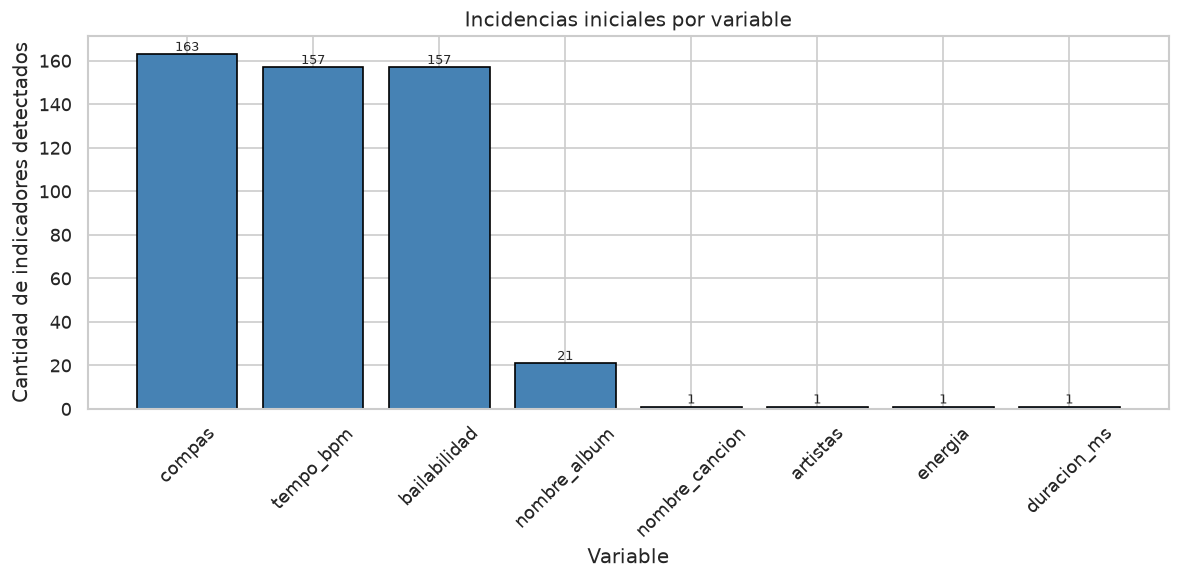

In [4]:
textos_auditoria = ['artistas', 'nombre_album', 'nombre_cancion']
numericas_cero = ['tempo_bpm', 'bailabilidad', 'energia', 'compas', 'duracion_ms']

auditoria_inicial = pd.DataFrame(index=textos_auditoria + numericas_cero)
auditoria_inicial.index.name = 'variable'
auditoria_inicial['nulos_explicitos'] = df_crudo[auditoria_inicial.index].isna().sum()
auditoria_inicial['interrogaciones'] = 0
auditoria_inicial['vacios'] = 0
auditoria_inicial['ceros'] = 0

for columna in textos_auditoria:
    texto = df_crudo[columna].astype('string').str.strip()
    auditoria_inicial.loc[columna, 'interrogaciones'] = int(texto.eq('?').sum())
    auditoria_inicial.loc[columna, 'vacios'] = int(texto.eq('').sum())

for columna in numericas_cero:
    valores = pd.to_numeric(df_crudo[columna], errors='coerce')
    auditoria_inicial.loc[columna, 'ceros'] = int(valores.eq(0).sum())

display(auditoria_inicial)

incidencias_por_variable = auditoria_inicial.sum(axis=1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(incidencias_por_variable.index, incidencias_por_variable.values,
       color='steelblue', edgecolor='black')
ax.set_title('Incidencias iniciales por variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Cantidad de indicadores detectados')
ax.tick_params(axis='x', rotation=45)
for barra, valor in zip(ax.patches, incidencias_por_variable.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f'{int(valor):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_calidad_datos_crudos.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.5 Estadística y distribución preliminar

Esta revisión se realiza sobre los datos crudos. Su finalidad es comprender la
fuente y detectar problemas; las cifras definitivas para presentación se vuelven
a calcular después de la limpieza en la Fase 3.


,count,mean,std,min,25%,50%,75%,max
popularidad,"114,000.0000",33.2385,22.3051,0.0000,17.0000,35.0000,50.0000,100.0000
duracion_ms,"114,000.0000","228,029.1531","107,297.7126",0.0000,"174,066.0000","212,906.0000","261,506.0000","5,237,295.0000"
bailabilidad,"114,000.0000",0.5668,0.1735,0.0000,0.4560,0.5800,0.6950,0.9850
energia,"114,000.0000",0.6414,0.2515,0.0000,0.4720,0.6850,0.8540,1.0000
volumen_db,"114,000.0000",-8.2590,5.0293,-49.5310,-10.0130,-7.0040,-5.0030,4.5320
presencia_habla,"114,000.0000",0.0847,0.1057,0.0000,0.0359,0.0489,0.0845,0.9650
acusticidad,"114,000.0000",0.3149,0.3325,0.0000,0.0169,0.1690,0.5980,0.9960
instrumentalidad,"114,000.0000",0.1560,0.3096,0.0000,0.0000,0.0000,0.0490,1.0000
presencia_en_vivo,"114,000.0000",0.2136,0.1904,0.0000,0.0980,0.1320,0.2730,1.0000
positividad,"114,000.0000",0.4741,0.2593,0.0000,0.2600,0.4640,0.6830,0.9950


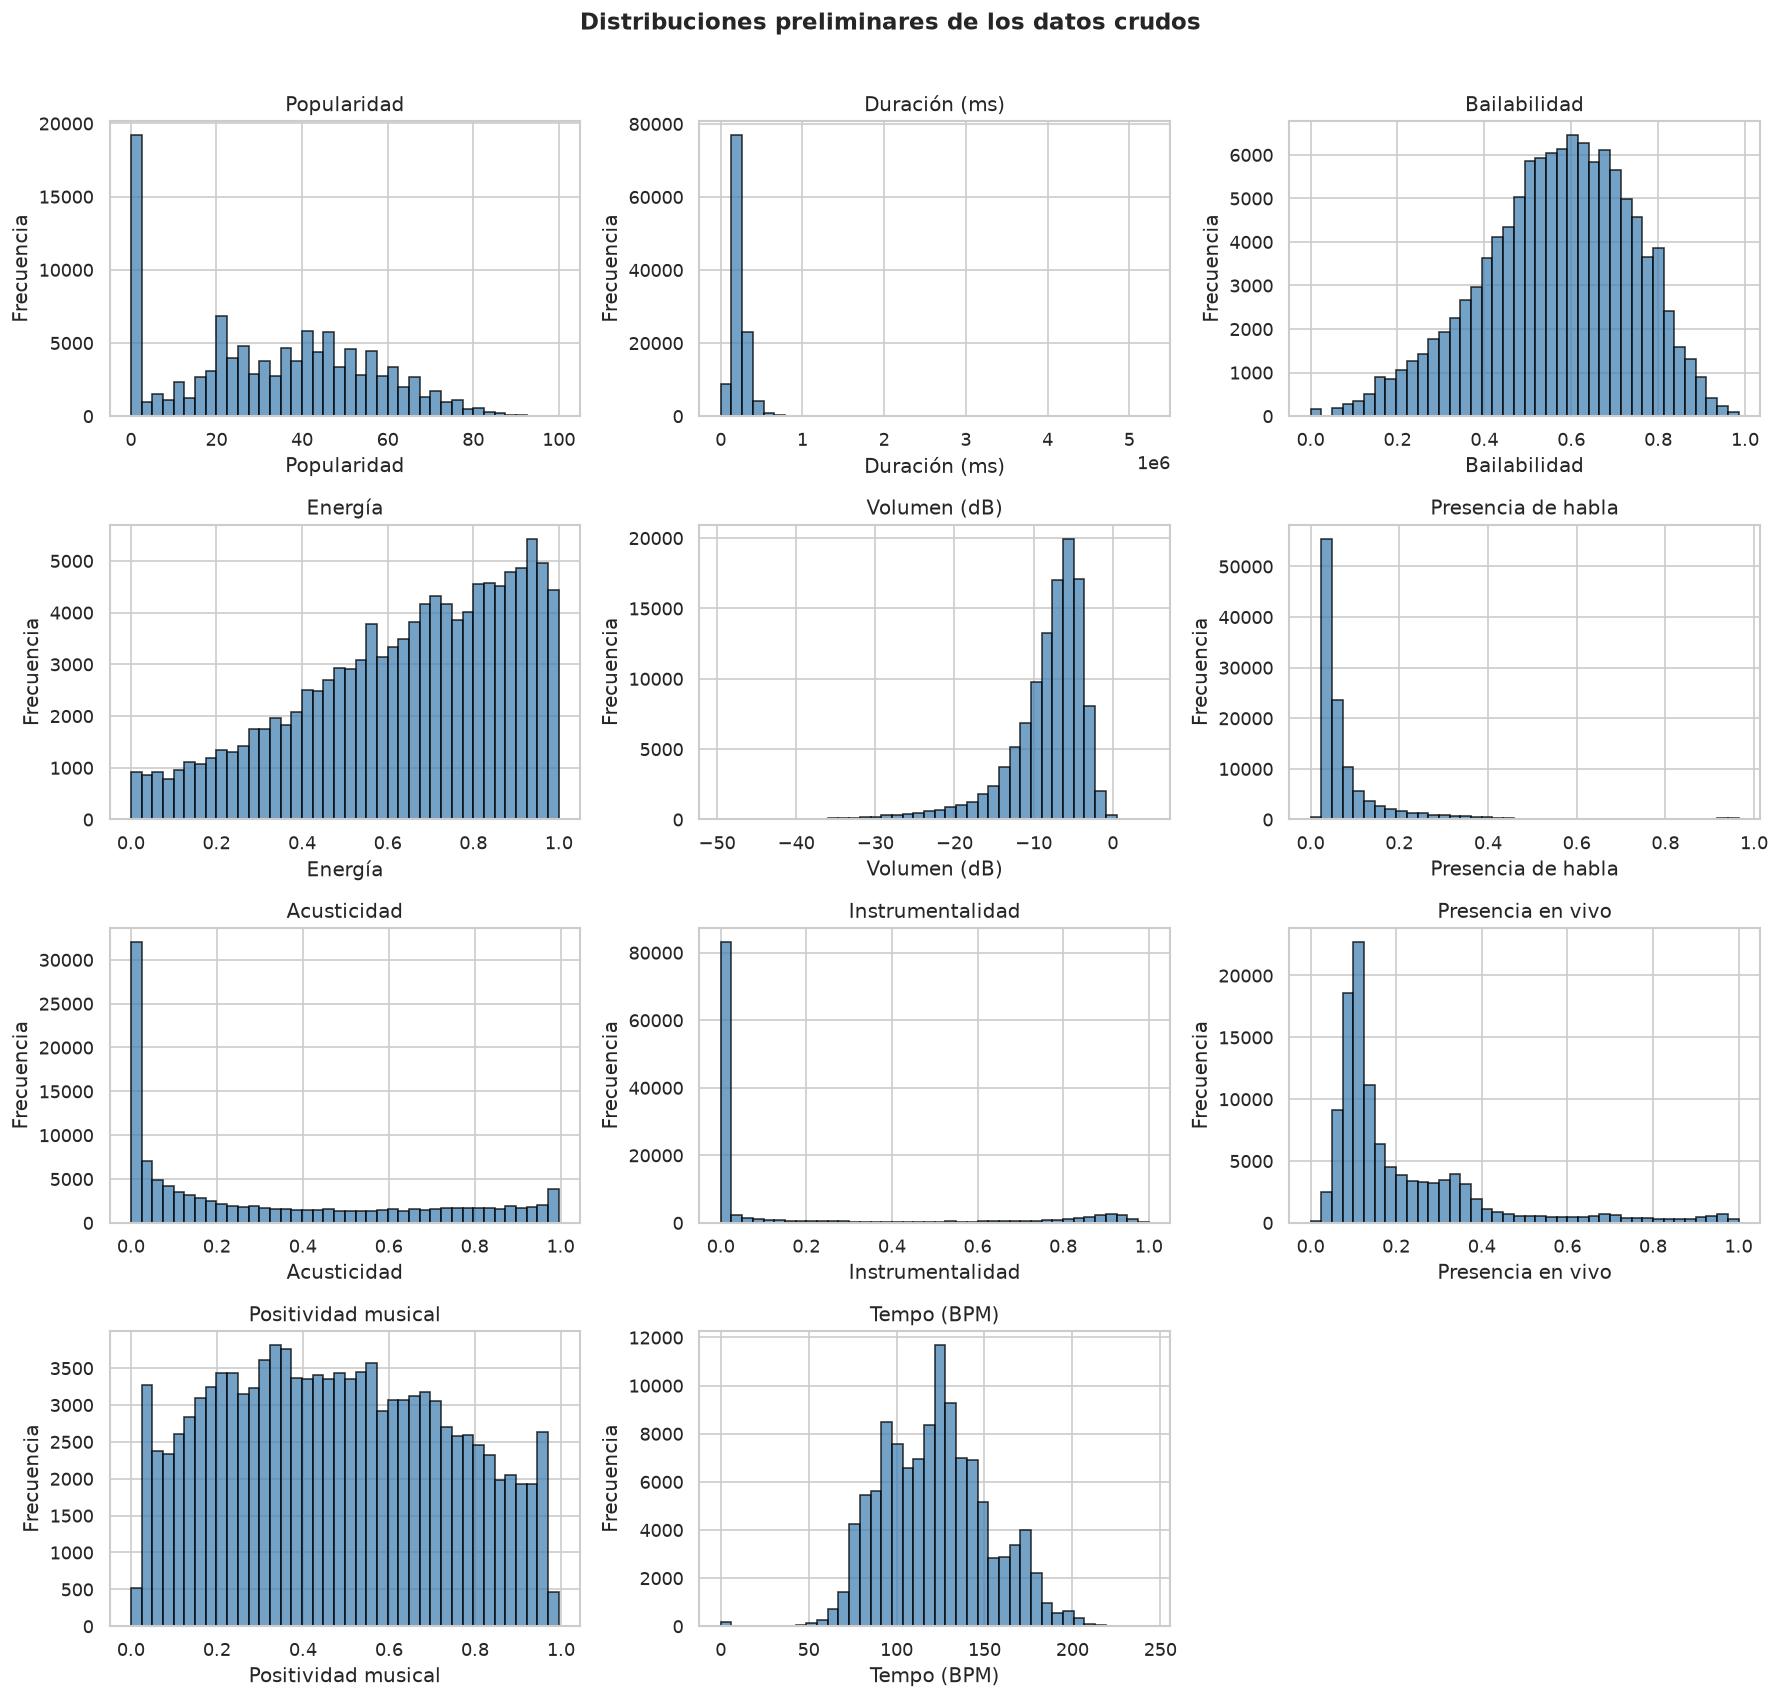

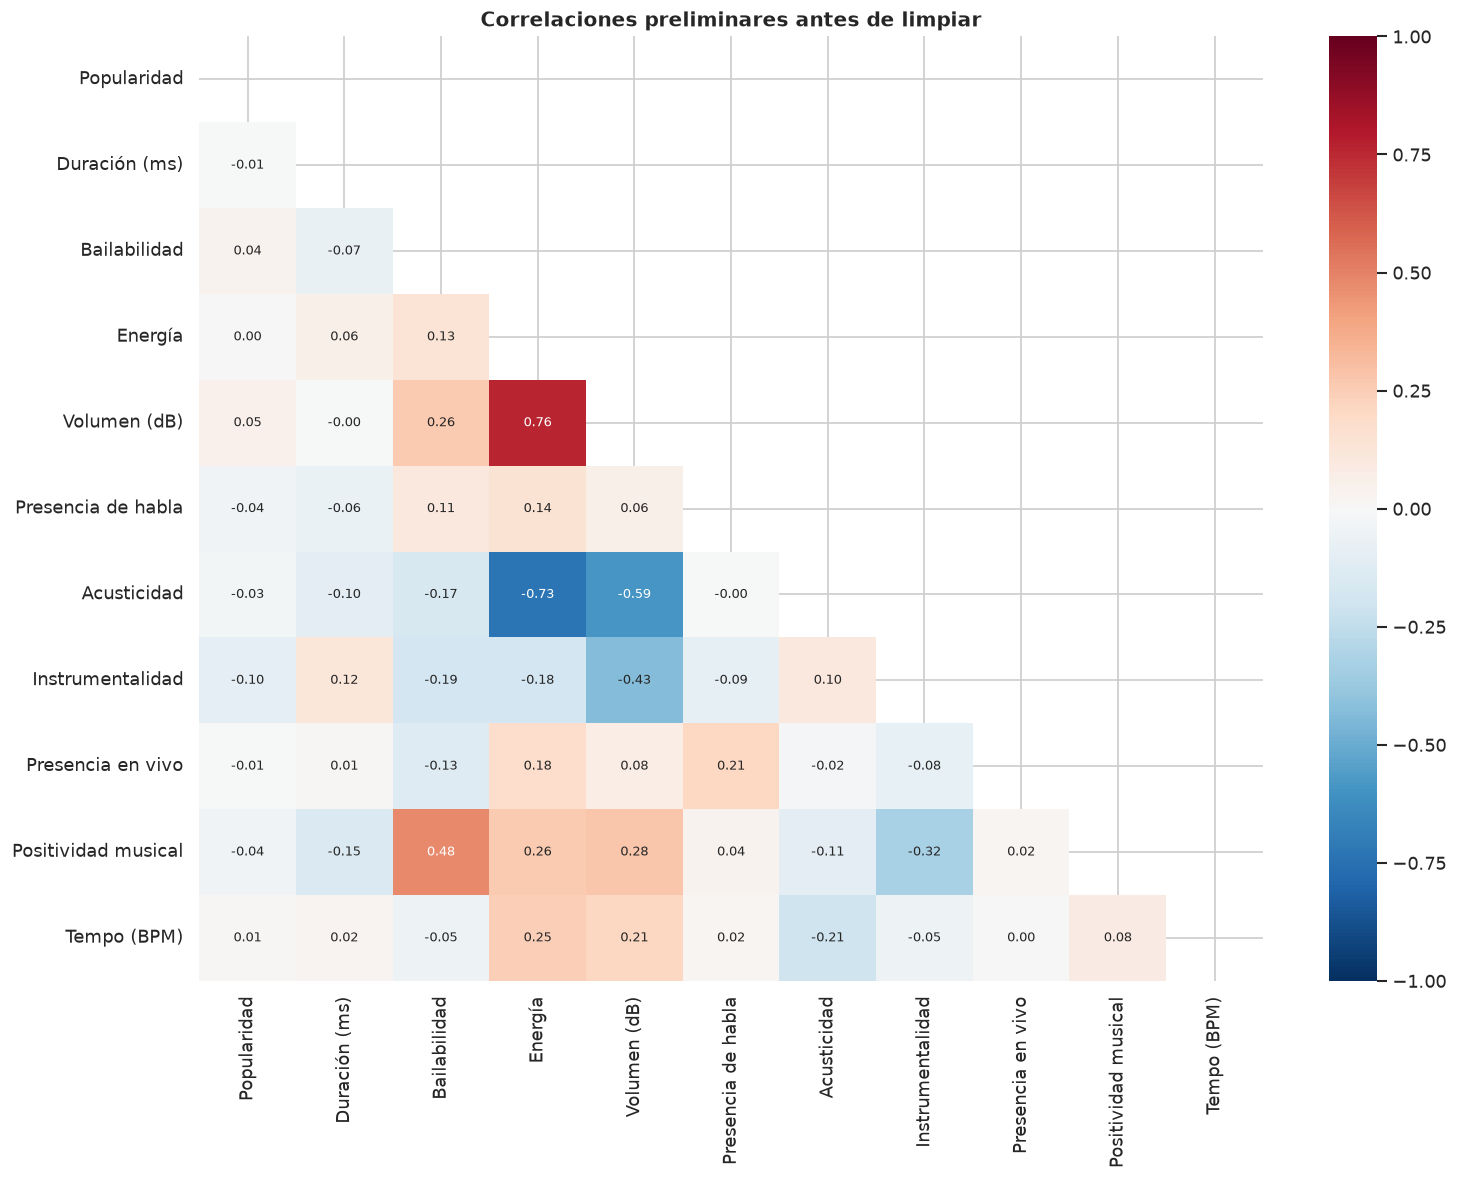

Filas originales: 114,000
Columnas útiles: 20
Duplicados exactos: 450
Canciones únicas por ID: 89,741


In [5]:
numericas_crudas = [
    'popularidad', 'duracion_ms', 'bailabilidad', 'energia', 'volumen_db',
    'presencia_habla', 'acusticidad', 'instrumentalidad',
    'presencia_en_vivo', 'positividad', 'tempo_bpm'
]

display(df_crudo[numericas_crudas].describe().T.round(4))

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, columna in enumerate(numericas_crudas):
    valores = pd.to_numeric(df_crudo[columna], errors='coerce').dropna()
    axes[i].hist(valores, bins=40, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].set_title(ETIQUETAS[columna])
    axes[i].set_xlabel(ETIQUETAS[columna])
    axes[i].set_ylabel('Frecuencia')
for j in range(len(numericas_crudas), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuciones preliminares de los datos crudos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '00_distribuciones_crudas.png', dpi=150, bbox_inches='tight')
plt.show()

correlacion_cruda = df_crudo[numericas_crudas].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(correlacion_cruda, dtype=bool))
sns.heatmap(
    correlacion_cruda.rename(index=ETIQUETAS, columns=ETIQUETAS),
    mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlaciones preliminares antes de limpiar', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Filas originales: {len(df_crudo):,}')
print(f'Columnas útiles: {df_crudo.shape[1]:,}')
print(f'Duplicados exactos: {df_crudo.duplicated().sum():,}')
print(f'Canciones únicas por ID: {df_crudo["id_cancion"].nunique(dropna=True):,}')


## Conclusiones Fase 2

- El dataset combina metadatos, variables numéricas de audio, categorías musicales
  y la variable objetivo popularidad.
- La auditoría separa los distintos tipos de incidencia para evitar confundir un
  cero con un nulo explícito.
- Los gráficos y tablas anteriores permiten observar forma, dispersión, valores
  extremos y asociaciones iniciales.
- Los valores calculados en esta fase no se utilizan todavía como entrada de un
  modelo. Primero se aplican las reglas documentadas de la Fase 3.
- La correlación describe asociación lineal; no demuestra causalidad ni garantiza
  desempeño predictivo.


## Fase 3: Data Preparation


### 3.1 Limpieza y transformaciones justificadas

| Variables en español | Condición | Tratamiento |
|---|---|---|
| artistas, nombre_cancion | Nulo, vacío o «?» | Eliminar la fila |
| nombre_album | Nulo, vacío o «?» | Imputar DESCONOCIDO en las filas conservadas |
| tempo_bpm, bailabilidad, energia | Al menos una igual a cero | Eliminar la fila una sola vez |
| Las tres métricas anteriores | Nulo explícito | Eliminar, sin KNN en esta versión |
| compas | Cero o nulo | Moda de los valores observados **solo en entrenamiento** |
| duracion_ms | Cero, negativo o nulo | Eliminar la fila |

- "?" y espacios vacíos se normalizan solo en los tres metadatos de texto.
- No se asigna SINGLE: la falta de nombre no demuestra que un lanzamiento sea un single.
- Los conteos informados (1 nulo de texto, 20 "?", 157 ceros de audio, 163 compases
  cero y 1 duración cero) son referencias a comprobar. Las filas pueden coincidir;
  **no se suman los conteos para calcular las eliminaciones**.
- Eliminar ceros de bailabilidad y energía es una **decisión de este proyecto**:
  cero pertenece a sus escalas y no demuestra un dato faltante. Puede sesgar la
  muestra hacia canciones más bailables y enérgicas.
- Se mantienen los ceros válidos de otras variables, como popularidad, modo,
  tonalidad e instrumentalidad.
- No se usa KNNImputer para compás: su promedio podría crear categorías
  fraccionarias. La moda conserva un valor observado; en empate se elige el menor.
- Los compases observados positivos se conservan si son enteros. Las categorías
  inusuales se reportan para revisión, sin inventar valores ni truncar decimales.
- Los valores extremos detectados por IQR se reportan; no se eliminan por IQR.

La partición por canción se reserva aquí para aprender la moda sin consultar el
conjunto de prueba. df_base conserva el compás sin imputar para el pipeline;
df_limpio incorpora esa moda para EDA y exportación. En EP2 se debe volver a
ajustar el pipeline dentro de cada pliegue de validación usando df_base.

> **Nota EP2:** esta partición por `id_cancion` solo se usa para aprender la moda del
> compás de `df_limpio` (EDA y exportación). La partición definitiva para modelar se
> redefine en la sección 3.12, agrupando por artista + título.

Referencias: [escalas de audio de Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features),
[moda con SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html).


In [6]:
def limpiar_spotify(datos, semilla=42):
    """Limpieza auditable, sin modificar la entrada ni aprender del test."""
    df = datos.copy()
    textos = ['artistas', 'nombre_album', 'nombre_cancion']
    audio_cero = ['tempo_bpm', 'bailabilidad', 'energia']

    # Diagnóstico ANTES de eliminar filas: separa nulos, ? y ceros.
    auditoria = pd.DataFrame(index=textos + audio_cero + ['compas', 'duracion_ms'])
    auditoria.index.name = 'variable'
    auditoria['nulos_explicitos'] = df[auditoria.index].isna().sum()
    auditoria['interrogaciones'] = 0
    auditoria['vacios'] = 0
    auditoria['ceros'] = 0
    for col in textos:
        texto = df[col].astype('string').str.strip()
        auditoria.loc[col, 'interrogaciones'] = int(texto.eq('?').sum())
        auditoria.loc[col, 'vacios'] = int(texto.eq('').sum())
        df[col] = texto.mask(texto.isin(['', '?']), pd.NA)
    for col in audio_cero + ['compas', 'duracion_ms']:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
        auditoria.loc[col, 'ceros'] = int(df[col].eq(0).sum())

    motivos = pd.DataFrame({
        'artista_o_cancion_faltante': df[['artistas', 'nombre_cancion']].isna().any(axis=1),
        'cero_en_audio': df[audio_cero].eq(0).any(axis=1),
        'nulo_en_audio': df[audio_cero].isna().any(axis=1),
        'duracion_invalida': df['duracion_ms'].isna() | df['duracion_ms'].le(0),
    }, index=df.index)
    eliminar = motivos.any(axis=1)
    resumen = pd.DataFrame({
        'criterio': motivos.columns,
        'filas_afectadas_pueden_coincidir': motivos.sum().values,
    })
    # Una fila con varias incidencias se elimina solo una vez.
    base = df.loc[~eliminar].copy()
    if base.empty:
        raise ValueError('No quedan filas después de la limpieza; revisa las incidencias.')
    albumes_imputados = int(base['nombre_album'].isna().sum())
    base['nombre_album'] = base['nombre_album'].fillna('DESCONOCIDO')
    base['compas'] = base['compas'].mask(base['compas'].eq(0), np.nan)
    observados = base['compas'].dropna()
    if ((observados <= 0) | ~np.isfinite(observados) | (observados % 1 != 0)).any():
        raise ValueError('Hay compases negativos, no finitos o decimales. Revisarlos sin truncar.')
    base['duracion_min'] = base['duracion_ms'] / 60000

    ids = base['id_cancion'].astype('string').str.strip()
    if ids.isna().any() or ids.isin(['', '?']).any():
        raise ValueError('Hay identificadores de canción faltantes; no se puede agrupar con seguridad.')
    base['id_cancion'] = ids
    if ids.nunique() < 2:
        raise ValueError('Se necesitan al menos dos canciones distintas para separar entrenamiento y prueba.')
    divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=semilla)
    idx_entrenamiento, idx_prueba = next(divisor.split(base, groups=ids))
    compas_entrenamiento = base.iloc[idx_entrenamiento][['compas']]
    if compas_entrenamiento['compas'].notna().sum() == 0:
        raise ValueError('No hay compases observados en entrenamiento para calcular la moda.')
    imputador = SimpleImputer(strategy='most_frequent')
    imputador.fit(compas_entrenamiento)
    moda = int(imputador.statistics_[0])
    limpio = base.copy()
    limpio['compas'] = imputador.transform(base[['compas']]).ravel().astype('int64')

    particion = pd.Series('prueba', index=base.index, name='particion')
    particion.iloc[idx_entrenamiento] = 'entrenamiento'
    imputaciones = pd.DataFrame({
        'particion': particion,
        'compas_imputado': base['compas'].isna(),
    }).groupby('particion')['compas_imputado'].sum().astype(int)
    balance = pd.DataFrame({
        'indicador': ['filas_originales', 'filas_eliminadas_sin_duplicar', 'filas_conservadas',
                      'albumes_imputados_en_filas_conservadas', 'compases_imputados',
                      'moda_compas_entrenamiento'],
        'cantidad': [len(df), int(eliminar.sum()), len(limpio), albumes_imputados,
                     int(base['compas'].isna().sum()), moda],
    })
    descartadas = datos.loc[eliminar].join(motivos.loc[eliminar].add_prefix('motivo_'))
    return base, limpio, idx_entrenamiento, idx_prueba, auditoria, resumen, balance, imputaciones, descartadas

(df_base, df_limpio, train_idx, test_idx, auditoria_faltantes, resumen_eliminacion,
 balance_limpieza, imputaciones_compas, filas_descartadas) = limpiar_spotify(df_crudo)

display(auditoria_faltantes)
display(resumen_eliminacion)
display(balance_limpieza)
display(imputaciones_compas.to_frame('cantidad_imputada'))
perdida_pct = 100 * (len(df_crudo) - len(df_limpio)) / len(df_crudo)
print(f'Pérdida real de filas: {perdida_pct:.4f}% (sin duplicar coincidencias)')

# Guardar datos limpios, base sin imputación aprendida y trazabilidad.
df_limpio.to_csv(PROCESSED_DIR / 'spotify_clean.csv', index=False)
df_base.to_csv(PROCESSED_DIR / 'spotify_base_modelo.csv', index=False)
auditoria_faltantes.to_csv(PROCESSED_DIR / 'auditoria_faltantes.csv')
resumen_eliminacion.to_csv(PROCESSED_DIR / 'resumen_eliminacion.csv', index=False)
balance_limpieza.to_csv(PROCESSED_DIR / 'balance_limpieza.csv', index=False)
filas_descartadas.to_csv(PROCESSED_DIR / 'filas_descartadas.csv', index_label='indice_origen')
particion = pd.DataFrame({'id_cancion': df_base['id_cancion'], 'particion': 'prueba'})
particion.iloc[train_idx, particion.columns.get_loc('particion')] = 'entrenamiento'
particion.to_csv(PROCESSED_DIR / 'particion_modelo.csv', index_label='indice_origen')
print('Datos y auditoría guardados; todos los nombres de columna están en español.')


,nulos_explicitos,interrogaciones,vacios,ceros
variable,,,,
artistas,1,0,0,0
nombre_album,1,20,0,0
nombre_cancion,1,0,0,0
tempo_bpm,0,0,0,157
bailabilidad,0,0,0,157
energia,0,0,0,1
compas,0,0,0,163
duracion_ms,0,0,0,1


,criterio,filas_afectadas_pueden_coincidir
0,artista_o_cancion_faltante,1
1,cero_en_audio,157
2,nulo_en_audio,0
3,duracion_invalida,1


,indicador,cantidad
0,filas_originales,114000
1,filas_eliminadas_sin_duplicar,158
2,filas_conservadas,113842
3,albumes_imputados_en_filas_conservadas,20
4,compases_imputados,6
5,moda_compas_entrenamiento,4


,cantidad_imputada
particion,
entrenamiento,4
prueba,2


Pérdida real de filas: 0.1386% (sin duplicar coincidencias)


Datos y auditoría guardados; todos los nombres de columna están en español.


In [7]:
# Clasificación de variables para el análisis
audio_numericas = [
    'duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla',
    'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm'
]
variables_categoricas = ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
metadatos_texto        = ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']
numericas_descriptivas = ['popularidad', 'duracion_ms', 'duracion_min'] + audio_numericas[1:]

print('Numéricas predictoras:', audio_numericas)
print('Categóricas predictoras:', variables_categoricas)
print('Metadatos (excluir del modelo):', metadatos_texto)

Numéricas predictoras: ['duracion_ms', 'bailabilidad', 'energia', 'volumen_db', 'presencia_habla', 'acusticidad', 'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm']
Categóricas predictoras: ['contenido_explicito', 'tonalidad', 'modo', 'compas', 'genero_musical']
Metadatos (excluir del modelo): ['id_cancion', 'artistas', 'nombre_album', 'nombre_cancion']


### 3.2 Estadística descriptiva posterior a la limpieza

Se calculan media, mediana, desviación estándar, percentiles 25/50/75/90/95/99, rango, skewness y curtosis para cada variable numérica.


In [8]:
# Estadística descriptiva extendida con skewness y curtosis
rows = []
for col in numericas_descriptivas:
    s = df_limpio[col].dropna()
    q25, q50, q75, q90, q95, q99 = s.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    rows.append({
        'variable':   col,
        'cantidad':      int(len(s)),
        'media':       s.mean(),
        'mediana':     s.median(),
        'desviacion_estandar':        s.std(),
        'minimo':        s.min(),
        'P25':        q25,
        'P75':        q75,
        'P90':        q90,
        'P95':        q95,
        'P99':        q99,
        'maximo':        s.max(),
        'rango':      s.max() - s.min(),
        'asimetria':   s.skew(),
        'curtosis':   s.kurtosis()
    })

stats_df = pd.DataFrame(rows).set_index('variable')
display(stats_df.round(4))
stats_df.to_csv(PROCESSED_DIR / 'descriptive_statistics.csv')
print('Estadísticas guardadas.')

,cantidad,media,mediana,desviacion_estandar,minimo,P25,P75,P90,P95,P99,maximo,rango,asimetria,curtosis
variable,,,,,,,,,,,,,,
popularidad,113842,33.2334,34.0000,22.3161,0.0000,17.0000,50.0000,63.0000,69.0000,80.0000,100.0000,100.0000,0.0469,-0.9297
duracion_ms,113842,"228,108.6597","213,000.0000","106,306.2429","15,800.0000","174,198.5000","261,583.0000","327,835.0000","387,168.9000","530,665.8100","5,237,295.0000","5,221,495.0000",10.9655,351.1657
duracion_min,113842,3.8018,3.5500,1.7718,0.2633,2.9033,4.3597,5.4639,6.4528,8.8444,87.2882,87.0249,10.9655,351.1657
bailabilidad,113842,0.5676,0.5800,0.1724,0.0513,0.4560,0.6950,0.7840,0.8240,0.9010,0.9850,0.9337,-0.3728,-0.2584
energia,113842,0.6421,0.6850,0.2508,0.0000,0.4730,0.8540,0.9410,0.9690,0.9930,1.0000,1.0000,-0.5941,-0.5309
volumen_db,113842,-8.2399,-6.9980,4.9937,-46.5910,-10.0020,-5.0000,-3.6770,-2.9731,-1.6340,4.5320,51.1230,-1.9861,5.7514
presencia_habla,113842,0.0848,0.0490,0.1058,0.0221,0.0359,0.0846,0.1760,0.2680,0.5070,0.9650,0.9429,4.6479,28.8154
acusticidad,113842,0.3147,0.1680,0.3323,0.0000,0.0169,0.5970,0.8660,0.9480,0.9920,0.9960,0.9960,0.7280,-0.9481
instrumentalidad,113842,0.1554,0.0000,0.3089,0.0000,0.0000,0.0477,0.8310,0.9040,0.9540,1.0000,1.0000,1.7403,1.2918


Estadísticas guardadas.


#### Interpretación de la tabla actualizada

Las cifras deben salir de la ejecución actual, porque la eliminación de ceros
cambia medias, percentiles y correlaciones. Comparar media y mediana permite
describir la distribución; asimetría y curtosis ayudan a revisar valores extremos.

No confundir una correlación débil con la imposibilidad de predecir: pueden existir
relaciones no lineales o interacciones. El rendimiento se comprobará en EP2.


### 3.3 Histogramas y distribuciones

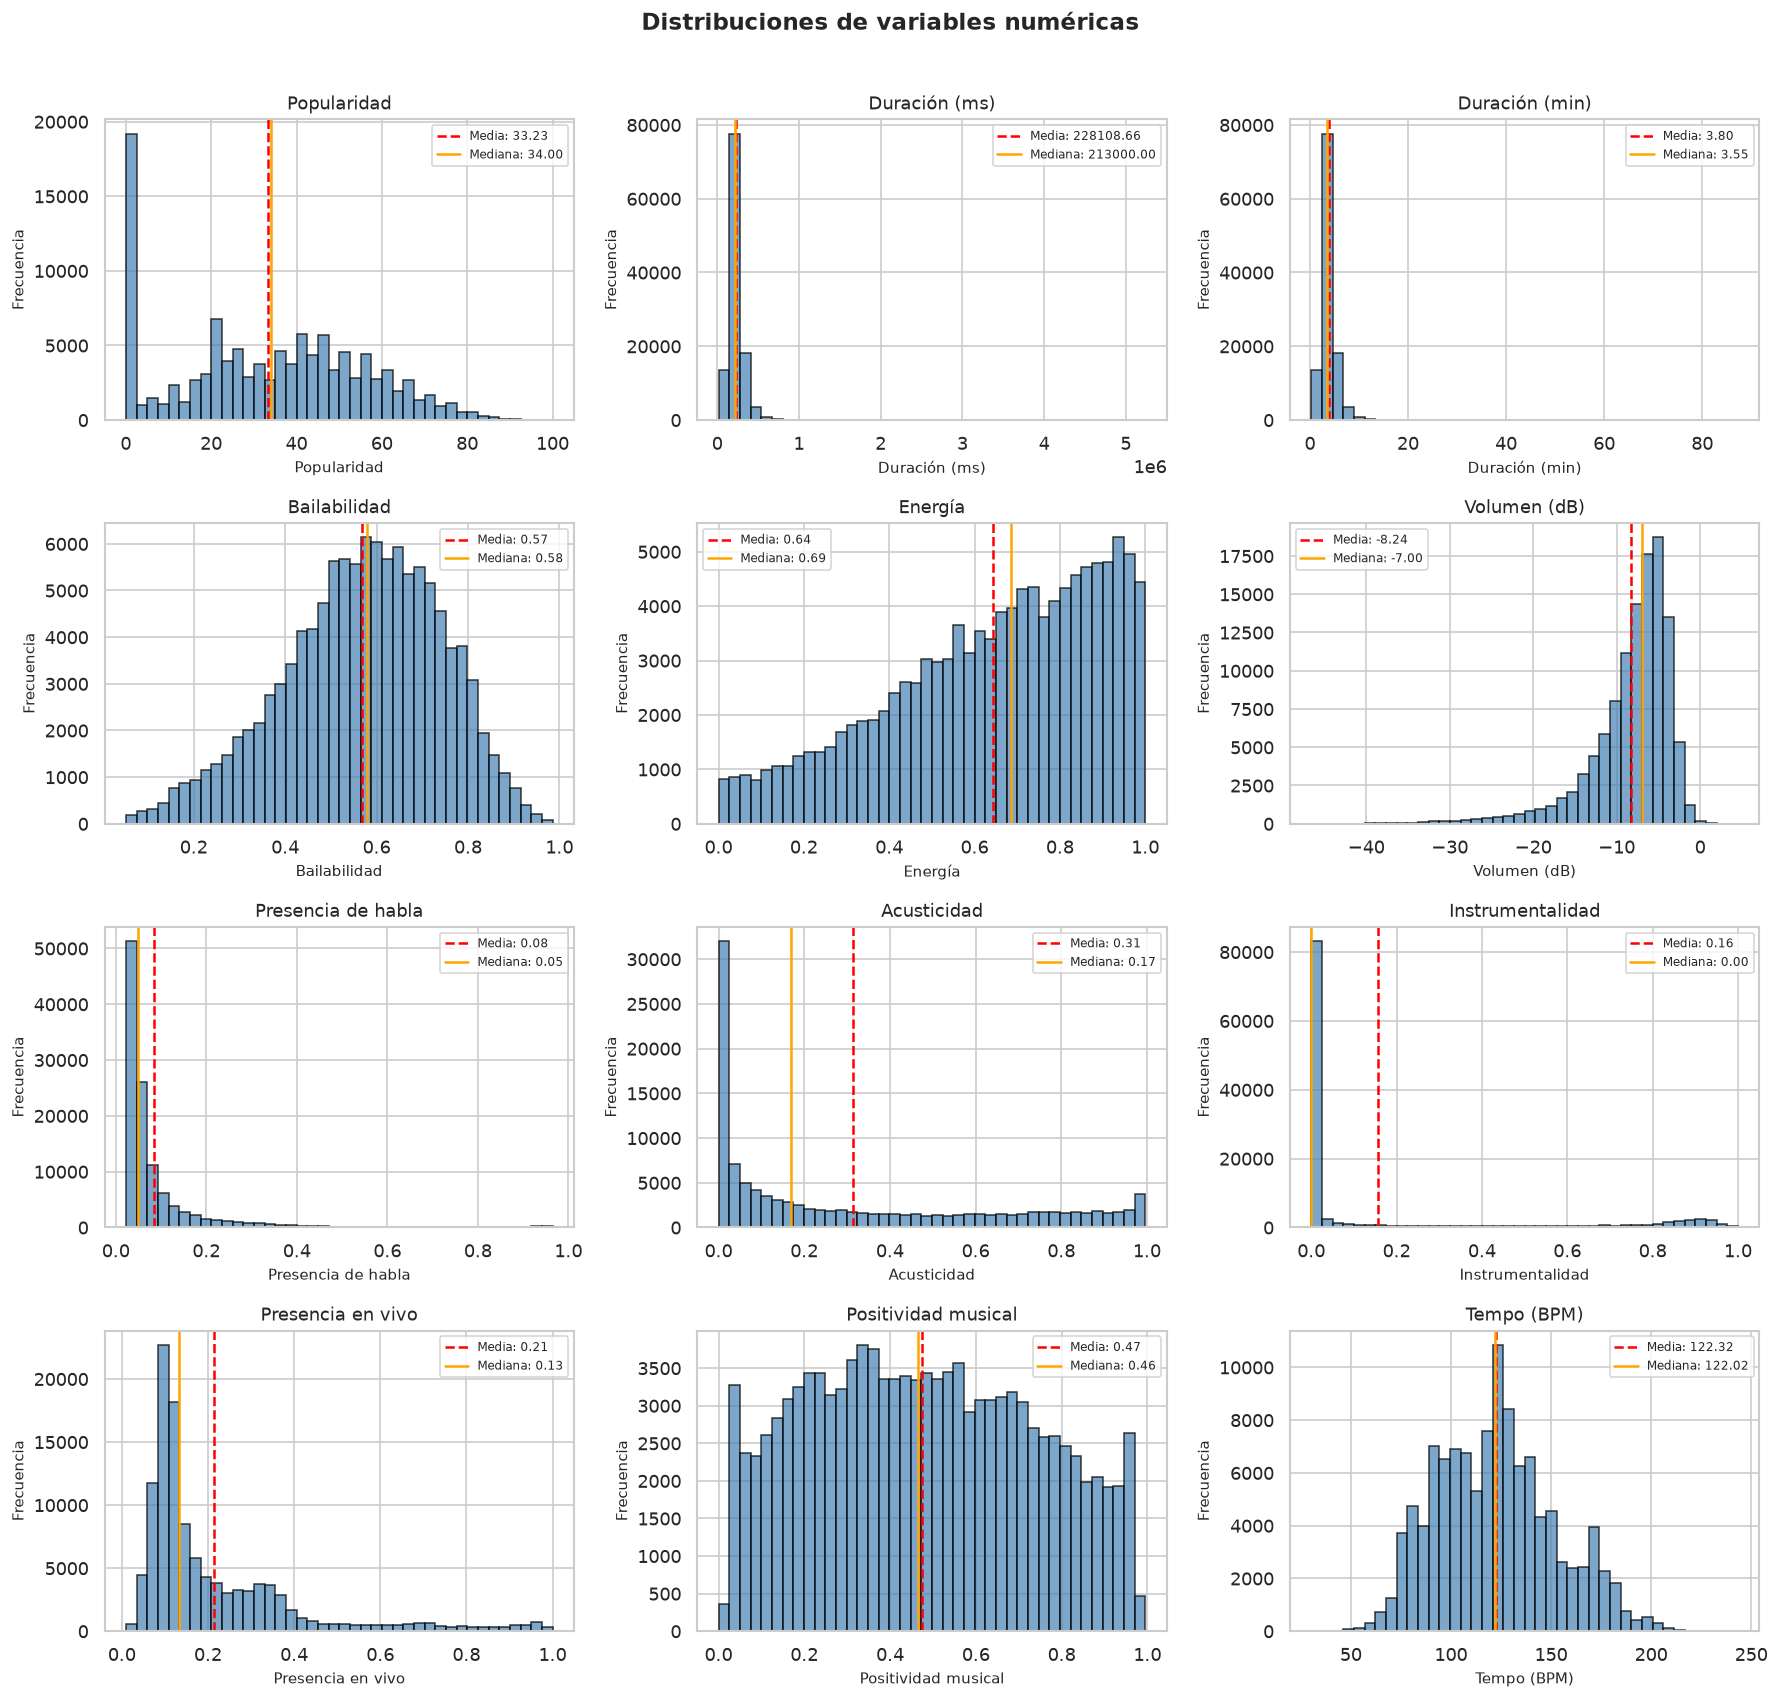

Gráfico guardado: 01_histogramas_numericas.png


In [9]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numericas_descriptivas):
    ax = axes[i]
    data = df_limpio[col].dropna()
    ax.hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(ETIQUETAS[col], fontsize=11)
    ax.set_xlabel(ETIQUETAS[col], fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    # Añadir líneas de media y mediana
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=7)

# Ocultar subplots vacíos
for j in range(len(numericas_descriptivas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '01_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: 01_histogramas_numericas.png')


### 3.4 Variables categóricas: frecuencias y proporciones

Se analiza la distribución de contenido_explicito, tonalidad, modo, compas y genero_musical.


In [10]:
def tabla_frecuencias(data, variable):
    counts = data[variable].value_counts(dropna=False)
    pct    = data[variable].value_counts(dropna=False, normalize=True) * 100
    return pd.DataFrame({'frecuencia': counts, 'proporcion_pct': pct.round(2)})

for variable in ['contenido_explicito', 'tonalidad', 'modo', 'compas']:
    print(f'\n── {variable} ──')
    display(tabla_frecuencias(df_limpio, variable))

print(f'\n── genero_musical: {df_limpio["genero_musical"].nunique()} géneros únicos (mostrando top 20) ──')
display(tabla_frecuencias(df_limpio, 'genero_musical').head(20))



── contenido_explicito ──


,frecuencia,proporcion_pct
contenido_explicito,,
False,104095,91.4400
True,9747,8.5600



── tonalidad ──


,frecuencia,proporcion_pct
tonalidad,,
7,13236,11.6300
0,13045,11.4600
2,11625,10.2100
9,11303,9.9300
1,10743,9.4400
5,9362,8.2200
11,9273,8.1500
4,9004,7.9100
6,7914,6.9500



── modo ──


,frecuencia,proporcion_pct
modo,,
1,72573,63.7500
0,41269,36.2500



── compas ──


,frecuencia,proporcion_pct
compas,,
4,101848,89.4600
3,9195,8.0800
5,1826,1.6000
1,973,0.8500



── genero_musical: 114 géneros únicos (mostrando top 20) ──


,frecuencia,proporcion_pct
genero_musical,,
acoustic,1000,0.8800
afrobeat,1000,0.8800
alt-rock,1000,0.8800
alternative,1000,0.8800
anime,1000,0.8800
black-metal,1000,0.8800
bluegrass,1000,0.8800
blues,1000,0.8800
brazil,1000,0.8800


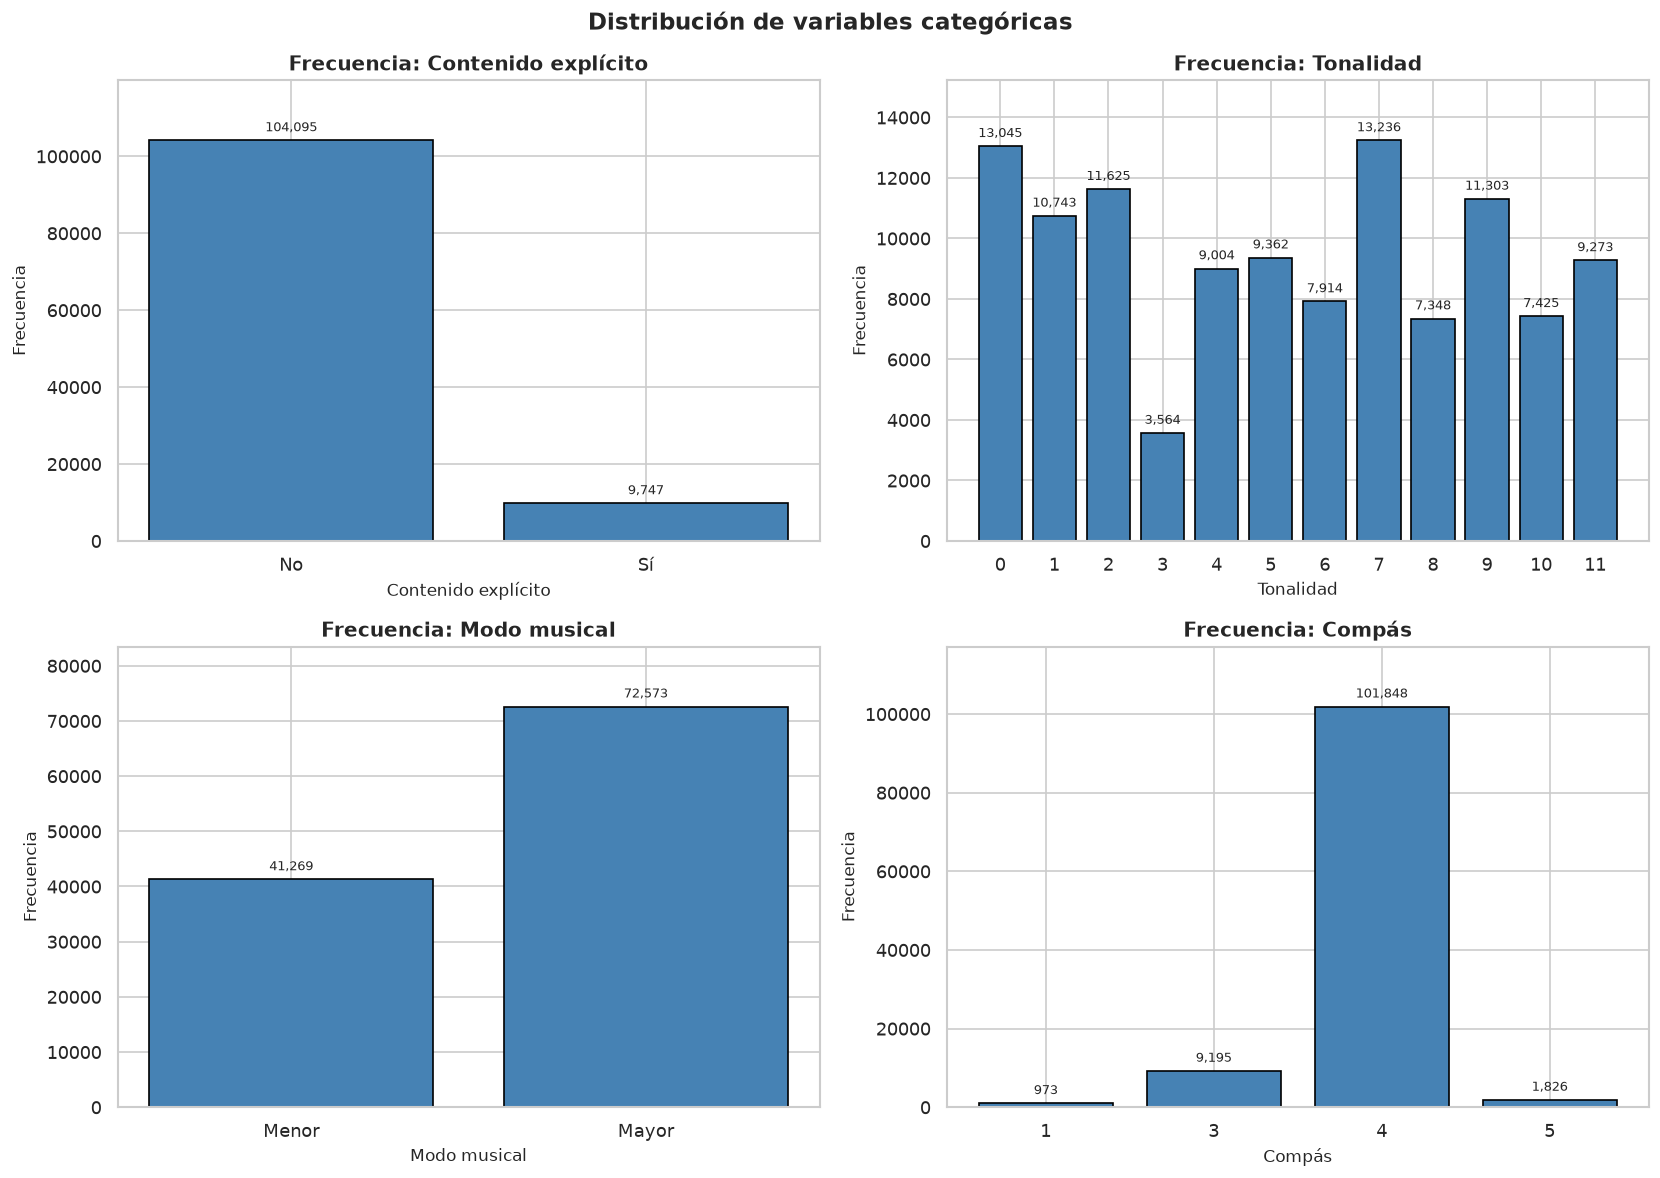

In [11]:
# Gráficos de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, variable in zip(axes.flatten(), ['contenido_explicito', 'tonalidad', 'modo', 'compas']):
    counts = df_limpio[variable].value_counts().sort_index()
    ax.bar([({False: 'No', True: 'Sí'}.get(v, str(v)) if variable == 'contenido_explicito'
            else {0: 'Menor', 1: 'Mayor'}.get(v, str(v)) if variable == 'modo'
            else str(v)) for v in counts.index], counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'Frecuencia: {ETIQUETAS[variable]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(ETIQUETAS[variable], fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_ylim(0, max(1, counts.max()) * 1.15)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max() * 0.015,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '02_variables_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Validación de calidad, dominios y duplicados

Se comprueba el resultado de la limpieza y se reportan valores inusuales. Las
reglas específicas del proyecto se distinguen de los dominios de las variables.
Los compases 1 y 2, si aparecen en el CSV histórico, se conservan como categorías
observadas pero se señalan: la documentación actual de Spotify describe 3–7.


In [12]:
checks = {
    'Nulos después de limpiar (todas las columnas)': int(df_limpio.isna().sum().sum()),
    'Artista o canción vacíos / interrogación': int(df_limpio[['artistas', 'nombre_cancion']].isin(['', '?']).sum().sum()),
    'Álbum vacío / interrogación': int(df_limpio['nombre_album'].isin(['', '?']).sum()),
    'Popularidad fuera de 0–100': int((~df_limpio['popularidad'].between(0, 100)).sum()),
    'Tonalidad fuera de códigos -1 a 11': int((~df_limpio['tonalidad'].isin(range(-1, 12))).sum()),
    'Modo fuera de {0, 1}': int((~df_limpio['modo'].isin([0, 1])).sum()),
    'Duración no positiva': int(df_limpio['duracion_ms'].le(0).sum()),
    'Tempo no positivo': int(df_limpio['tempo_bpm'].le(0).sum()),
    'Bailabilidad o energía cero (regla del proyecto)': int(df_limpio[['bailabilidad', 'energia']].eq(0).any(axis=1).sum()),
    'Compás nulo, no positivo o no entero': int((df_limpio['compas'].isna() | df_limpio['compas'].le(0) | df_limpio['compas'].mod(1).ne(0)).sum()),
    'Valores numéricos no finitos': int((~np.isfinite(df_limpio[audio_numericas + ['popularidad']])).sum().sum()),
}
for col in ['bailabilidad', 'energia', 'presencia_habla', 'acusticidad',
            'instrumentalidad', 'presencia_en_vivo', 'positividad']:
    checks[f'{ETIQUETAS[col]} fuera de 0–1'] = int((~df_limpio[col].between(0, 1)).sum())
checks_df = pd.DataFrame(list(checks.items()), columns=['Regla', 'Cantidad'])
checks_df['Estado'] = np.where(checks_df['Cantidad'].eq(0), 'OK', 'Revisar')
display(checks_df)
if checks_df['Cantidad'].gt(0).any():
    raise ValueError('Persisten incidencias de calidad; revisarlas antes del modelamiento.')

advertencias = pd.DataFrame({
    'Observación': ['Volumen positivo en dB: revisar fuente', 'Compás fuera del rango 3–7 documentado actualmente'],
    'Cantidad': [int(df_limpio['volumen_db'].gt(0).sum()), int((~df_limpio['compas'].between(3, 7)).sum())],
})
display(advertencias)
print(f'Duplicados exactos: {df_limpio.duplicated().sum():,}')
conteos_id = df_limpio['id_cancion'].value_counts()
print(f'Canciones únicas: {len(conteos_id):,}')
print(f'IDs con más de una fila: {conteos_id.gt(1).sum():,}')
print(f'Filas adicionales respecto de IDs únicos: {len(df_limpio) - len(conteos_id):,}')
print('La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.')


,Regla,Cantidad,Estado
0,Nulos después de limpiar (todas las columnas),0,OK
1,Artista o canción vacíos / interrogación,0,OK
2,Álbum vacío / interrogación,0,OK
3,Popularidad fuera de 0–100,0,OK
4,Tonalidad fuera de códigos -1 a 11,0,OK
5,"Modo fuera de {0, 1}",0,OK
6,Duración no positiva,0,OK
7,Tempo no positivo,0,OK
8,Bailabilidad o energía cero (regla del proyecto),0,OK
9,"Compás nulo, no positivo o no entero",0,OK


,Observación,Cantidad
0,Volumen positivo en dB: revisar fuente,90
1,Compás fuera del rango 3–7 documentado actualm...,973


Duplicados exactos: 450
Canciones únicas: 89,583
IDs con más de una fila: 16,641
Filas adicionales respecto de IDs únicos: 24,259
La separación por ID evita compartir canciones entre entrenamiento y prueba; no elimina duplicados.


### 3.6 Valores extremos mediante IQR

El criterio IQR se usa para **detectar**, no para eliminar automáticamente.
Cada caso se evalúa individualmente antes de tomar una decisión.


In [13]:
outlier_rows = []
for col in audio_numericas + ['popularidad']:
    s = df_limpio[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_rows.append({
        'variable':      col,
        'Q1':            q1,
        'Q3':            q3,
        'limite_inf':    low,
        'limite_sup':    high,
        'n_outliers':    int(mask.sum()),
        'pct_outliers':  round(mask.mean() * 100, 2),
        'decision':      'Conservar'
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outliers_df.round(3))
outliers_df.to_csv(PROCESSED_DIR / 'outliers_iqr_summary.csv', index=False)
print('\nResumen de outliers guardado.')


,variable,Q1,Q3,limite_inf,limite_sup,n_outliers,pct_outliers,decision
6,instrumentalidad,0.0000,0.0480,-0.0720,0.1190,25186,22.1200,Conservar
4,presencia_habla,0.0360,0.0850,-0.0370,0.1580,13211,11.6000,Conservar
7,presencia_en_vivo,0.0980,0.2730,-0.1640,0.5360,8579,7.5400,Conservar
3,volumen_db,-10.0020,-5.0000,-17.5050,2.5030,6099,5.3600,Conservar
0,duracion_ms,"174,198.5000","261,583.0000","43,121.7500","392,659.7500",5607,4.9300,Conservar
9,tempo_bpm,99.4300,140.0780,38.4570,201.0500,470,0.4100,Conservar
1,bailabilidad,0.4560,0.6950,0.0980,1.0530,463,0.4100,Conservar
2,energia,0.4730,0.8540,-0.0990,1.4260,0,0.0000,Conservar
5,acusticidad,0.0170,0.5970,-0.8530,1.4670,0,0.0000,Conservar
8,positividad,0.2610,0.6830,-0.3720,1.3160,0,0.0000,Conservar



Resumen de outliers guardado.


#### Justificación de las decisiones

El IQR identifica valores alejados del centro de la distribución, pero no demuestra
que sean errores. Se conservan los valores extremos para revisar su contexto
musical. Duraciones largas, grabaciones instrumentales o con habla pueden ser
reales; no se afirma que todos los extremos hayan sido verificados individualmente.

Las eliminaciones de ceros de audio y duración corresponden a las reglas de la
subsección 3.1, aplicadas **antes** del IQR. Sus cantidades no se mezclan con outliers.


### 3.7 Correlaciones y relaciones entre variables

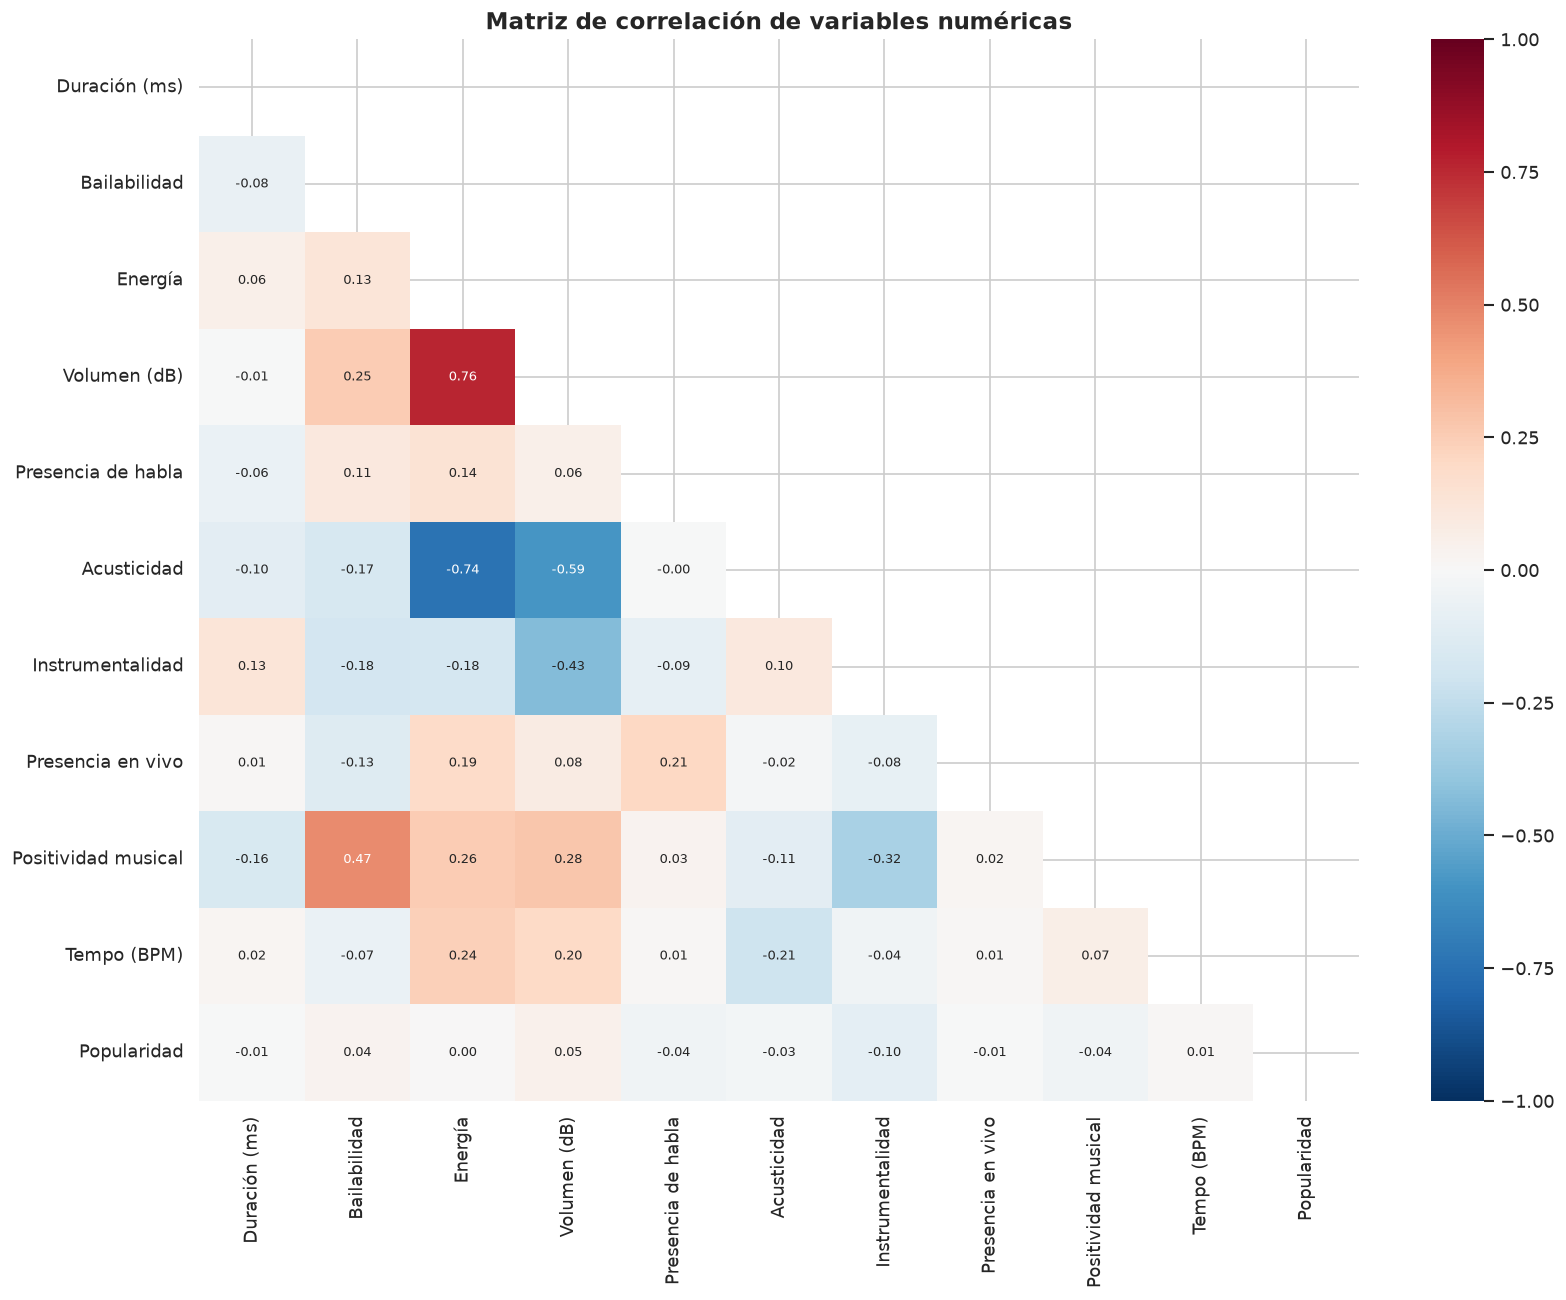

=== Correlaciones con popularidad (ordenadas por valor absoluto) ===


,correlacion_con_popularidad
instrumentalidad,-0.0959
volumen_db,0.0515
presencia_habla,-0.0448
positividad,-0.0402
bailabilidad,0.0365
acusticidad,-0.0256
tempo_bpm,0.0144
duracion_ms,-0.0070
presencia_en_vivo,-0.0057
energia,0.0015


Correlaciones con |r| >= 0.10: 0 de 10 calculables.
La correlación describe asociación lineal, no causalidad ni desempeño del modelo.


In [14]:
corr_cols = audio_numericas + ['popularidad']
corr = df_limpio[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr.rename(index=ETIQUETAS, columns=ETIQUETAS), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '03_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con popularidad
corr_pop = corr['popularidad'].drop('popularidad').sort_values(key=lambda s: s.abs(), ascending=False)
print('=== Correlaciones con popularidad (ordenadas por valor absoluto) ===')
display(corr_pop.to_frame('correlacion_con_popularidad').round(4))
print(f'Correlaciones con |r| >= 0.10: {corr_pop.abs().ge(0.10).sum()} de {corr_pop.notna().sum()} calculables.')
print('La correlación describe asociación lineal, no causalidad ni desempeño del modelo.')


### 3.8 Popularidad por grupos

In [15]:
# Por género
estadisticas_genero = (
    df_limpio.groupby('genero_musical')
    .agg(
        n               = ('id_cancion', 'size'),
        popularidad_media = ('popularidad', 'mean'),
        popularidad_mediana  = ('popularidad', 'median'),
        popularidad_desviacion  = ('popularidad', 'std'),
        bailabilidad_media      = ('bailabilidad', 'mean'),
        energia_media     = ('energia', 'mean')
    )
    .sort_values('popularidad_media', ascending=False)
    .round(2)
)

print('=== 10 primeros géneros por popularidad media ===')
display(estadisticas_genero.head(10))
print('\n=== 10 últimos géneros por popularidad media ===')
display(estadisticas_genero.tail(10))

estadisticas_genero.to_csv(PROCESSED_DIR / 'genre_popularity_stats.csv')


=== 10 primeros géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
pop-film,1000,59.2800,60.0000,10.2500,0.6000,0.6000
k-pop,999,56.9500,60.0000,16.8600,0.6500,0.6800
chill,1000,53.6500,57.0000,14.9500,0.6600,0.4300
sad,1000,52.3800,54.0000,11.4900,0.6900,0.4600
grunge,1000,49.5900,55.0000,18.4900,0.4600,0.8000
indian,1000,49.5400,49.0000,11.3500,0.5900,0.5700
anime,1000,48.7700,50.0000,11.8100,0.5400,0.6700
emo,1000,48.1300,51.0000,17.5900,0.6000,0.6700
sertanejo,1000,47.8700,47.0000,3.9400,0.5900,0.7100



=== 10 últimos géneros por popularidad media ===


,n,popularidad_media,popularidad_mediana,popularidad_desviacion,bailabilidad_media,energia_media
genero_musical,,,,,,
idm,1000,15.7700,12.0000,10.2700,0.5300,0.5600
kids,1000,14.8900,12.0000,9.2400,0.7800,0.6100
grindcore,1000,14.6200,14.0000,4.5000,0.2700,0.9200
jazz,999,13.5800,0.0000,23.1400,0.5100,0.3500
classical,1000,13.0600,3.0000,18.0900,0.3800,0.1900
chicago-house,1000,12.3400,10.0000,9.5800,0.7700,0.7300
detroit-techno,1000,11.1700,8.0000,8.9500,0.7200,0.7100
latin,1000,8.3000,0.0000,21.9600,0.7200,0.7300
romance,999,3.2200,0.0000,6.2600,0.4300,0.2900


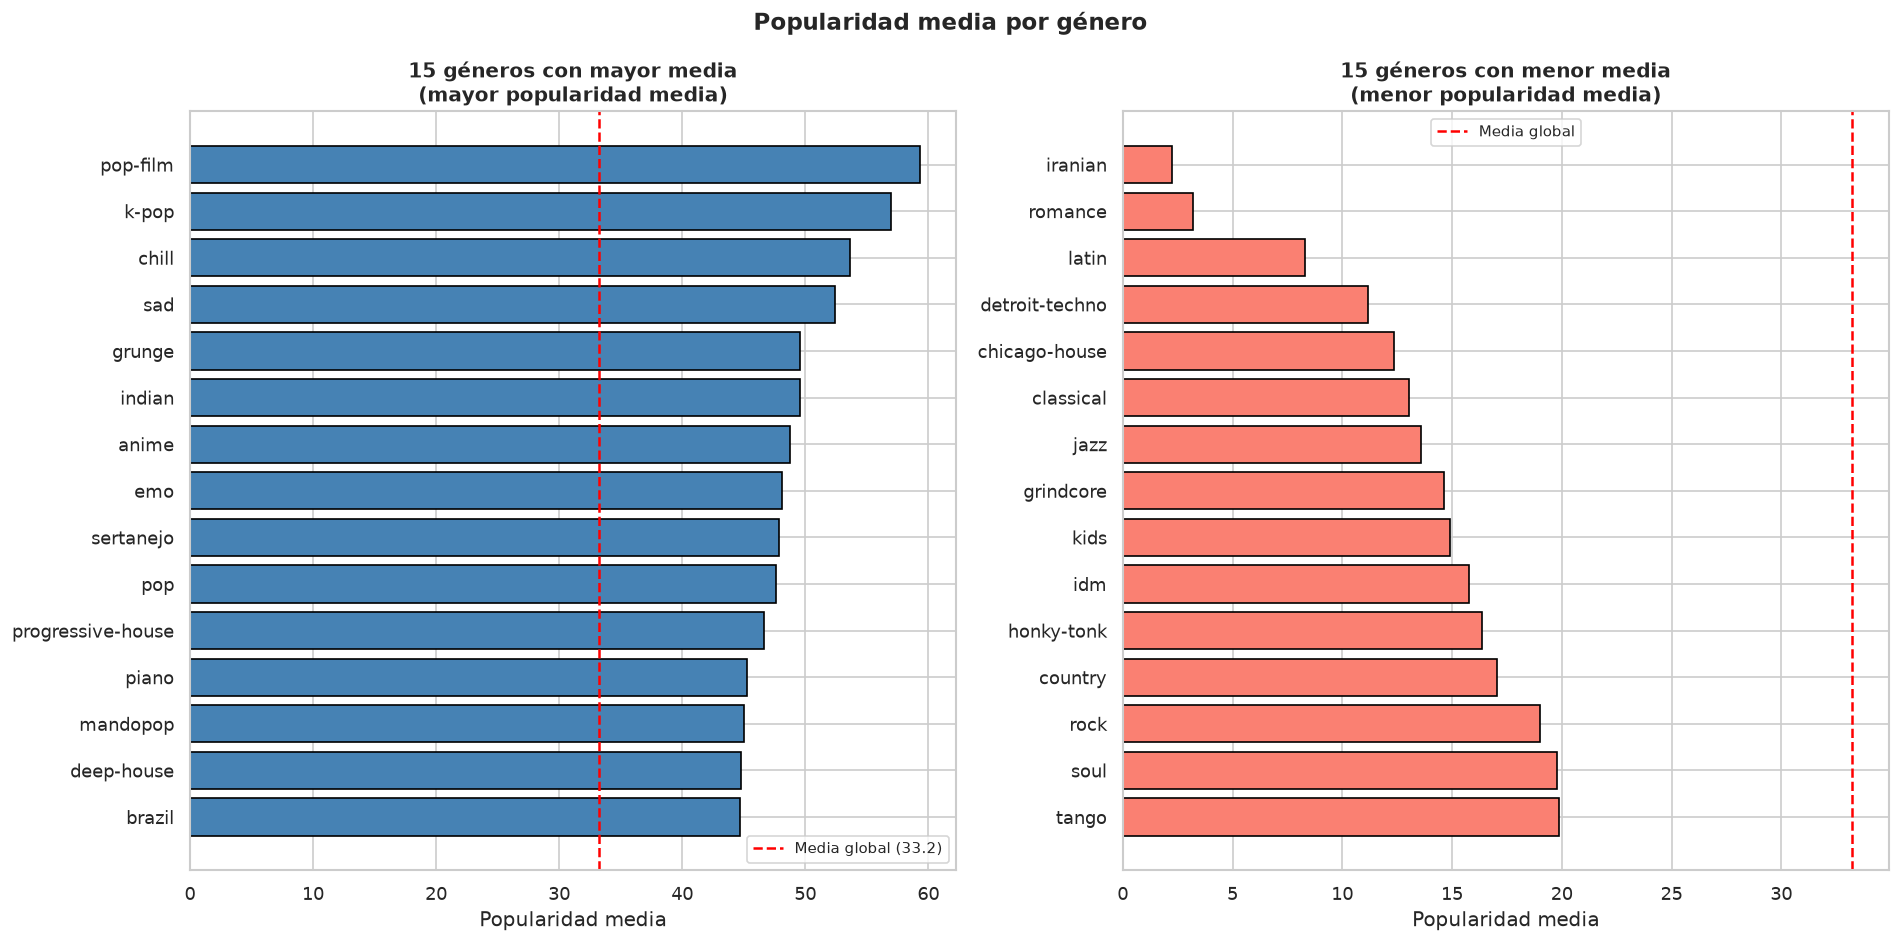

In [16]:
# Gráfico Top 15 y Bottom 15
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top15  = estadisticas_genero.head(15).sort_values('popularidad_media')
bot15  = estadisticas_genero.tail(15).sort_values('popularidad_media', ascending=False)

ax1.barh(top15.index, top15['popularidad_media'], color='steelblue', edgecolor='black')
ax1.set_title('15 géneros con mayor media\n(mayor popularidad media)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Popularidad media')
ax1.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global ({df_limpio["popularidad"].mean():.1f})')
ax1.legend(fontsize=9)

ax2.barh(bot15.index, bot15['popularidad_media'], color='salmon', edgecolor='black')
ax2.set_title('15 géneros con menor media\n(menor popularidad media)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Popularidad media')
ax2.axvline(df_limpio['popularidad'].mean(), color='red', linestyle='--', label=f'Media global')
ax2.legend(fontsize=9)

plt.suptitle('Popularidad media por género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_popularidad_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()


=== Popularidad según contenido explícito ===


,cantidad,media,mediana,desviacion_estandar
contenido_explicito,,,,
False,104095,32.9300,34.0000,22.1000
True,9747,36.4500,37.0000,24.3200


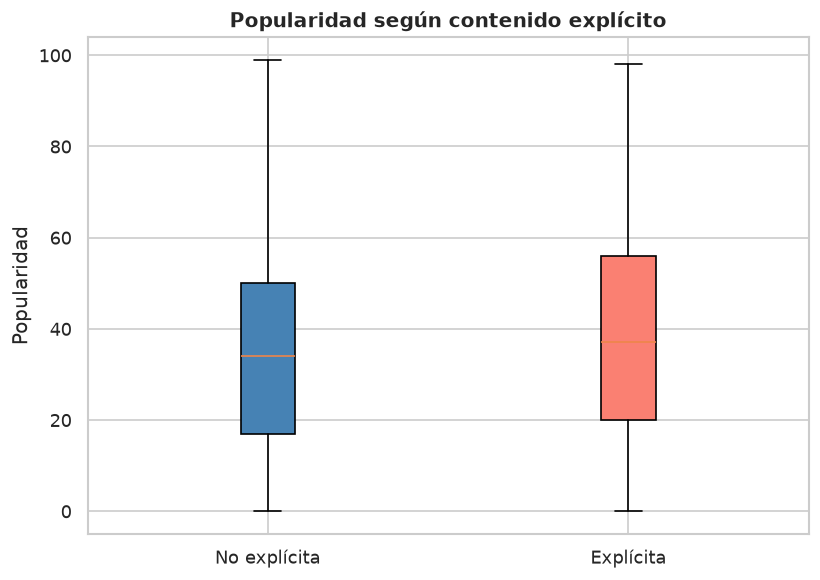

Diferencia de medias: 3.52 puntos (no implica causalidad)


In [17]:
# Por contenido_explicito
estadisticas_explicito = df_limpio.groupby('contenido_explicito')['popularidad'].agg(['count','mean','median','std']).round(2)
print('=== Popularidad según contenido explícito ===')
display(estadisticas_explicito.rename(columns={'count': 'cantidad', 'mean': 'media', 'median': 'mediana', 'std': 'desviacion_estandar'}))

fig, ax = plt.subplots(figsize=(7, 5))
groups_data = [df_limpio.loc[df_limpio['contenido_explicito'] == False, 'popularidad'].values,
               df_limpio.loc[df_limpio['contenido_explicito'] == True,  'popularidad'].values]
bp = ax.boxplot(groups_data, positions=[1, 2], patch_artist=True,
                showfliers=False)
ax.set_xticks([1, 2], ['No explícita', 'Explícita'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_title('Popularidad según contenido explícito', fontsize=12, fontweight='bold')
ax.set_ylabel('Popularidad')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_popularidad_explicit.png', dpi=150, bbox_inches='tight')
plt.show()
if {False, True}.issubset(estadisticas_explicito.index):
    print('Diferencia de medias: {:.2f} puntos (no implica causalidad)'.format(
        estadisticas_explicito.loc[True, 'mean'] - estadisticas_explicito.loc[False, 'mean']))


### 3.9 Perfil de canciones populares

Se comparan los features de audio entre canciones con popularidad ≥ 70 y el resto.


In [18]:
pop_alta  = df_limpio[df_limpio['popularidad'] >= 70]
pop_baja  = df_limpio[df_limpio['popularidad'] < 70]

print(f'Canciones con popularidad >= 70: {len(pop_alta):,} ({len(pop_alta)/len(df_limpio)*100:.1f}%)')
print(f'Resto: {len(pop_baja):,}')

comparacion = pd.DataFrame({
    'Popular (≥70)':   pop_alta[audio_numericas].mean(),
    'Resto (<70)':     pop_baja[audio_numericas].mean(),
}).round(4)
comparacion['Diferencia'] = (comparacion['Popular (≥70)'] - comparacion['Resto (<70)']).round(4)
display(comparacion)
print('Comparar las diferencias calculadas arriba; no implican causalidad.')


Canciones con popularidad >= 70: 5,470 (4.8%)
Resto: 108,372


,Popular (≥70),Resto (<70),Diferencia
duracion_ms,"218,501.2808","228,593.5853","-10,092.3045"
bailabilidad,0.6163,0.5651,0.0512
energia,0.6713,0.6406,0.0307
volumen_db,-6.6550,-8.3199,1.6649
presencia_habla,0.0753,0.0852,-0.0099
acusticidad,0.2210,0.3194,-0.0984
instrumentalidad,0.0363,0.1614,-0.1251
presencia_en_vivo,0.1720,0.2153,-0.0433
positividad,0.5047,0.4732,0.0315
tempo_bpm,120.1775,122.4241,-2.2466


Comparar las diferencias calculadas arriba; no implican causalidad.


### 3.10 Sesgos, ética y privacidad

Primero se cuantifica el sesgo introducido por la regla de limpieza "cero en audio".

In [19]:
# 3.10.a Cuantificación del sesgo por género en la regla "cero en audio"
eliminadas_por_cero_audio = filas_descartadas[filas_descartadas['motivo_cero_en_audio']]
impacto_genero = (
    eliminadas_por_cero_audio['genero_musical']
    .value_counts()
    .rename('filas_eliminadas')
    .to_frame()
)
impacto_genero['pct_del_total_eliminado'] = (
    100 * impacto_genero['filas_eliminadas'] / eliminadas_por_cero_audio.shape[0]
).round(2)
display(impacto_genero.head(10))
print(f'Total de filas eliminadas por la regla de audio en cero: {len(eliminadas_por_cero_audio)}')
print(f"Género con mayor impacto: {impacto_genero.index[0]} "
      f"({impacto_genero.iloc[0]['pct_del_total_eliminado']}% del total eliminado)")

,filas_eliminadas,pct_del_total_eliminado
genero_musical,,
sleep,138,87.9000
guitar,4,2.5500
iranian,4,2.5500
ambient,3,1.9100
world-music,3,1.9100
opera,2,1.2700
jazz,1,0.6400
romance,1,0.6400
show-tunes,1,0.6400


Total de filas eliminadas por la regla de audio en cero: 157
Género con mayor impacto: sleep (87.9% del total eliminado)


#### 3.10.b Matriz de riesgos

| Riesgo o sesgo | Tipo | Medida de control |
|---|---|---|
| Eliminación de ceros de audio afecta desproporcionadamente al género `sleep` | **Observado** (ver celda anterior) | El 87.9% de las filas eliminadas por la regla de audio en cero pertenece a un solo género. Se documenta en vez de tratarse como neutral; en EP2 se debe evaluar si esta pérdida diferencial afecta el desempeño del modelo específicamente en ese género. |
| Exposición desigual por género en el modelo | Potencial | Se evalúa el MAE por género en la Fase 5 (sección 5.3), no solo de forma global. |
| **Representación multi-género:** una canción asociada a varios géneros queda sobrerrepresentada al mantener una fila por género | **Observado** (16.641 canciones, ver celda siguiente) | Partición por `id_cancion` (no por fila) ya evita la fuga de información entre train y test. En EP2 se adopta la representación **1 canción = 1 observación**, con géneros multi-hot (sección 3.11). |
| Popularidad cambiante en el tiempo | Metodológico | Documentar la fecha de extracción cuando esté disponible; el CSV no la declara. |
| Ciclo de retroalimentación algorítmica | Potencial | Mantener supervisión humana y no tratar la predicción como sinónimo de calidad artística. |

**Propiedad intelectual y licenciamiento de los datos**

- El dataset proviene de Kaggle bajo licencia de uso académico/no comercial; **no se distribuyen archivos de audio**, solo metadatos y atributos numéricos derivados. Cualquier uso más allá del ámbito académico de esta evaluación requeriría revisar la licencia original y los Términos de Servicio de la API de Spotify.
- Los metadatos de artistas, álbumes y canciones son información pública, pero **no constituyen cesión de derechos de autor** sobre las obras musicales. El proyecto no reproduce, distribuye ni comercializa contenido protegido: solo analiza atributos numéricos derivados (tempo, energía, etc.), no las obras en sí.
- Un eventual modelo entrenado con estos datos, si se llevara a producción, debería documentar la fuente y licencia de los datos de entrenamiento como parte de su trazabilidad (data lineage), especialmente si se usa para decisiones comerciales de promoción o contratos.

**Privacidad:** el dataset no contiene historiales ni perfiles de usuarios individuales, solo metadatos públicos de canciones. El riesgo de privacidad individual es bajo. Si se incorporaran datos de usuarios (historial de reproducción, ubicación), aplicarían principios de minimización de datos y la normativa de protección de datos personales correspondiente.

### 3.11 Representación de modelamiento: 1 canción = 1 observación (multi-hot)

**Riesgo:** `df_base` mantiene una fila por combinación canción-género. Una canción con
varios géneros pesaría más en el entrenamiento y en las métricas solo por estar repetida.

**Decisión (EP2):** se modela con **1 canción = 1 fila**, y sus géneros se codifican con
*multi-hot encoding* (una columna binaria `genero_*` por género; una canción puede tener
varias en 1). Corrección respecto de EP1: la tabla se construye desde `df_base`
(compás **sin imputar**), para que la moda del compás se aprenda dentro del pipeline en
cada pliegue de validación y no antes.

- Atributos de audio: constantes por grabación → se toma el primer valor.
- Popularidad: puede variar levemente entre filas de un mismo ID → se usa la **mediana**.

In [20]:
# 3.11.a Construcción de la representación multi-género desde df_base (compás sin imputar)
variables_categoricas_modelo = ['contenido_explicito', 'tonalidad', 'modo', 'compas']
cols_atributos_cancion = (['artistas', 'nombre_album', 'nombre_cancion']
                          + audio_numericas + variables_categoricas_modelo)

# ¿Varían los atributos entre las filas de un mismo ID (una por género)?
duplicadas = df_base[df_base.duplicated('id_cancion', keep=False)]
variacion = duplicadas.groupby('id_cancion')[audio_numericas + ['popularidad']].nunique()
print(f'IDs repetidos con algún atributo de AUDIO distinto: '
      f'{(variacion[audio_numericas] > 1).any(axis=1).sum()} de {len(variacion)}')
print(f'IDs repetidos con POPULARIDAD distinta: {(variacion["popularidad"] > 1).sum()} de {len(variacion)}')

atributos_por_cancion = df_base.groupby('id_cancion').agg(
    {**{c: 'first' for c in cols_atributos_cancion}, 'popularidad': 'median'}
)
generos_por_cancion = df_base.groupby('id_cancion')['genero_musical'].apply(lambda s: sorted(set(s)))
mlb = MultiLabelBinarizer()
columnas_genero = [f'genero_{g}' for g in mlb.fit(generos_por_cancion).classes_]
generos_multihot = pd.DataFrame(mlb.transform(generos_por_cancion), columns=columnas_genero,
                                index=generos_por_cancion.index)

df_modelo = atributos_por_cancion.join(generos_multihot).reset_index()
df_modelo['contenido_explicito'] = df_modelo['contenido_explicito'].astype(int)
df_modelo['n_generos'] = generos_multihot.sum(axis=1).to_numpy()
df_modelo['genero_principal'] = generos_por_cancion.str[0].to_numpy()
df_modelo = df_modelo.copy()

print(f'\nFilas antes (canción-género): {len(df_base):,}')
print(f'Filas después (1 por canción): {len(df_modelo):,}')
print(f'Columnas multi-hot de género: {len(columnas_genero)}')
print(f'Canciones con más de un género: {(df_modelo["n_generos"] > 1).sum():,}')
print(f'Compases sin imputar (se imputan en el pipeline): {df_modelo["compas"].isna().sum()}')
display(df_modelo[['id_cancion', 'nombre_cancion', 'popularidad', 'n_generos', 'genero_principal']].head())

IDs repetidos con algún atributo de AUDIO distinto: 0 de 16641
IDs repetidos con POPULARIDAD distinta: 720 de 16641



Filas antes (canción-género): 113,842
Filas después (1 por canción): 89,583
Columnas multi-hot de género: 114
Canciones con más de un género: 16,299
Compases sin imputar (se imputan en el pipeline): 5


,id_cancion,nombre_cancion,popularidad,n_generos,genero_principal
0,0000vdREvCVMxbQTkS888c,Lolly,44.0000,1,german
1,000CC8EParg64OmTxVnZ0p,It's All Coming Back To Me Now (Glee Cast Vers...,47.0000,1,club
2,000Iz0K615UepwSJ5z2RE5,Böxig Leise - Pig & Dan Remix,22.0000,1,minimal-techno
3,000RDCYioLteXcutOjeweY,Teeje Week,62.0000,1,hip-hop
4,000qpdoc97IMTBvF8gwcpy,Tief,19.0000,1,minimal-techno


### 3.12 Partición entrenamiento/prueba sin fuga: grupos por artista + título

En la revisión se detectó que el mismo par **artista + título** aparece con distintos
`id_cancion` (la misma canción publicada en un álbum, un single y un recopilatorio).
Si la partición agrupa solo por ID, una versión puede quedar en entrenamiento y otra
—muchas veces con audio idéntico— en prueba: el modelo "reconoce" la canción en vez de
generalizar. Se define `clave_cancion` = artistas + título normalizados (minúsculas, sin
espacios repetidos) y se agrupa por ella con `GroupShuffleSplit` (80/20). La misma
clave se usa como grupo en la validación cruzada (`GroupKFold`) de la Fase 4.

> Nota: un artista sí puede aparecer en ambos conjuntos con canciones distintas. Esto es
> coherente con el uso de negocio (estimar la popularidad de un **nuevo lanzamiento**,
> incluso de artistas ya presentes en el catálogo).

In [21]:
def normalizar_texto(serie):
    return serie.astype('string').str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

df_modelo['clave_cancion'] = normalizar_texto(df_modelo['artistas']) + ' || ' + normalizar_texto(df_modelo['nombre_cancion'])
repetidas = df_modelo[df_modelo['clave_cancion'].duplicated(keep=False)]
audio_identico = repetidas.groupby('clave_cancion')[audio_numericas].nunique().le(1).all(axis=1)
rango_pop = repetidas.groupby('clave_cancion')['popularidad'].agg(lambda s: s.max() - s.min())
print(f'Claves artista+título con más de un ID: {repetidas["clave_cancion"].nunique():,} '
      f'({len(repetidas):,} canciones)')
print(f'  - con audio idéntico entre versiones: {audio_identico.mean():.1%}')
print(f'  - diferencia mediana de popularidad entre versiones: {rango_pop.median():.0f} puntos')

# Comparación: ¿cuántas claves quedarían en ambos conjuntos si se agrupara solo por ID?
split_id = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
tr_id, te_id = next(split_id.split(df_modelo, groups=df_modelo['id_cancion']))
fuga_por_id = set(df_modelo['clave_cancion'].iloc[tr_id]) & set(df_modelo['clave_cancion'].iloc[te_id])
print(f'\nSi se agrupara solo por ID: {len(fuga_por_id):,} claves artista+título en train y test a la vez.')

divisor = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
idx_train, idx_test = next(divisor.split(df_modelo, groups=df_modelo['clave_cancion']))
compartidas = set(df_modelo['clave_cancion'].iloc[idx_train]) & set(df_modelo['clave_cancion'].iloc[idx_test])
ids_compartidos = set(df_modelo['id_cancion'].iloc[idx_train]) & set(df_modelo['id_cancion'].iloc[idx_test])
assert not compartidas and not ids_compartidos, 'Existe fuga de información entre train y test.'
print(f'Partición por artista+título -> entrenamiento: {len(idx_train):,} | prueba: {len(idx_test):,} | '
      f'claves compartidas: {len(compartidas)} | IDs compartidos: {len(ids_compartidos)}')

particion = pd.DataFrame({'id_cancion': df_modelo['id_cancion'],
                          'clave_cancion': df_modelo['clave_cancion'], 'particion': 'prueba'})
particion.iloc[idx_train, particion.columns.get_loc('particion')] = 'entrenamiento'
particion.to_csv(PROCESSED_DIR / 'particion_modelo.csv', index=False)
df_modelo.drop(columns=['clave_cancion']).assign(particion=particion['particion']).to_csv(
    PROCESSED_DIR / 'spotify_multigenero.csv', index=False)
print('Guardados: particion_modelo.csv y spotify_multigenero.csv (base de modelamiento EP2).')

Claves artista+título con más de un ID: 4,737 (13,259 canciones)
  - con audio idéntico entre versiones: 49.1%
  - diferencia mediana de popularidad entre versiones: 6 puntos

Si se agrupara solo por ID: 1,894 claves artista+título en train y test a la vez.
Partición por artista+título -> entrenamiento: 71,740 | prueba: 17,843 | claves compartidas: 0 | IDs compartidos: 0


Guardados: particion_modelo.csv y spotify_multigenero.csv (base de modelamiento EP2).


### 3.13 Pipeline de preprocesamiento

| Grupo | Variables | Transformación | Justificación |
|---|---|---|---|
| Numéricas de audio | 10 variables (duración, bailabilidad, energía, volumen, habla, acusticidad, instrumentalidad, vivo, positividad, tempo) | `StandardScaler` | Ridge, regresión logística y KNN son sensibles a la escala (penalización y distancias). Los árboles no lo necesitan, pero no les perjudica. |
| Categóricas | contenido explícito, tonalidad, modo, compás | `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')` | Son códigos, no magnitudes. La moda solo es necesaria para compás, pero se aplica igual a todas por robustez. |
| Género | 114 columnas `genero_*` (multi-hot) | `passthrough` | Ya están en 0/1. |
| Excluidas | `id_cancion`, artistas, álbum, título, `duracion_min`, `n_generos`, `genero_principal` | — | Identificadores y textos de alta cardinalidad (riesgo de memorizar), duplicados o auxiliares. |

**Nota metodológica — codificación vs. fuga de información:** el one-hot/multi-hot convierte
categorías en columnas numéricas; la fuga de información se controla con la partición por
grupos de la sección 3.12. Son problemas distintos.

El preprocesador se crea con una función para obtener una copia nueva en cada pipeline:
así, en la validación cruzada se **ajusta solo con los pliegues de entrenamiento**.

In [22]:
variables_numericas = audio_numericas.copy()
variables_modelo = variables_numericas + variables_categoricas_modelo + columnas_genero

def crear_preprocesador(generos=None):
    """ColumnTransformer nuevo (sin ajustar) para usar dentro de cada pipeline."""
    generos = columnas_genero if generos is None else generos
    categoricas = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('numericas', StandardScaler(), variables_numericas),
        ('categoricas', categoricas, variables_categoricas_modelo),
        ('generos', 'passthrough', generos),
    ])

X = df_modelo[variables_modelo]
y_reg = df_modelo['popularidad']
grupos = df_modelo['clave_cancion']
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train_reg, y_test_reg = y_reg.iloc[idx_train], y_reg.iloc[idx_test]
grupos_train = grupos.iloc[idx_train]

preprocesador = crear_preprocesador()
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)
assert np.isfinite(X_train_prep).all() and np.isfinite(X_test_prep).all()
assert X_train_prep.shape[1] == X_test_prep.shape[1]
pd.DataFrame({'variable_transformada': preprocesador.get_feature_names_out()}).to_csv(
    PROCESSED_DIR / 'variables_modelo.csv', index=False)
print(f'Matriz de entrenamiento: {X_train_prep.shape} | prueba: {X_test_prep.shape}')
print('Verificado: sin nulos ni infinitos; el preprocesador se ajustó solo con entrenamiento.')

Matriz de entrenamiento: (71740, 144) | prueba: (17843, 144)
Verificado: sin nulos ni infinitos; el preprocesador se ajustó solo con entrenamiento.


### 3.14 Variables objetivo

**Regresión:** `popularidad` (0–100), sin transformar.

**Clasificación — corrección respecto de EP1:** en EP1 las clases se definían por terciles
de entrenamiento. Eso produce clases balanceadas "por construcción", pero el corte superior
(~45) hace que una canción con popularidad 45 sea "alta", lo que no tiene sentido para el
negocio (bajo la media de las canciones que entran a playlists editoriales). Se definen
umbrales **de negocio, fijos y conocidos de antemano**:

| Clase | Popularidad | Lectura de negocio |
|---|---|---|
| `bajo` | 0–29 | Baja tracción; no priorizar |
| `medio` | 30–59 | Tracción moderada; catálogo de fondo |
| `alto` | ≥ 60 | Candidata a playlists de alta rotación / promoción |

Como los cortes no se aprenden de los datos, no hay fuga. A cambio, la clase `alto` queda
**minoritaria** (~11%): por eso en la Fase 4 se comparan métodos de balanceo.

,entrenamiento_n,entrenamiento_%,prueba_n,prueba_%
popularidad,,,,
bajo,32460,45.2000,8003,44.9000
medio,31461,43.9000,7868,44.1000
alto,7819,10.9000,1972,11.1000


Cortes por terciles que usaba EP1 (entrenamiento): [23.0, 43.0] -> reemplazados por 30 y 60.


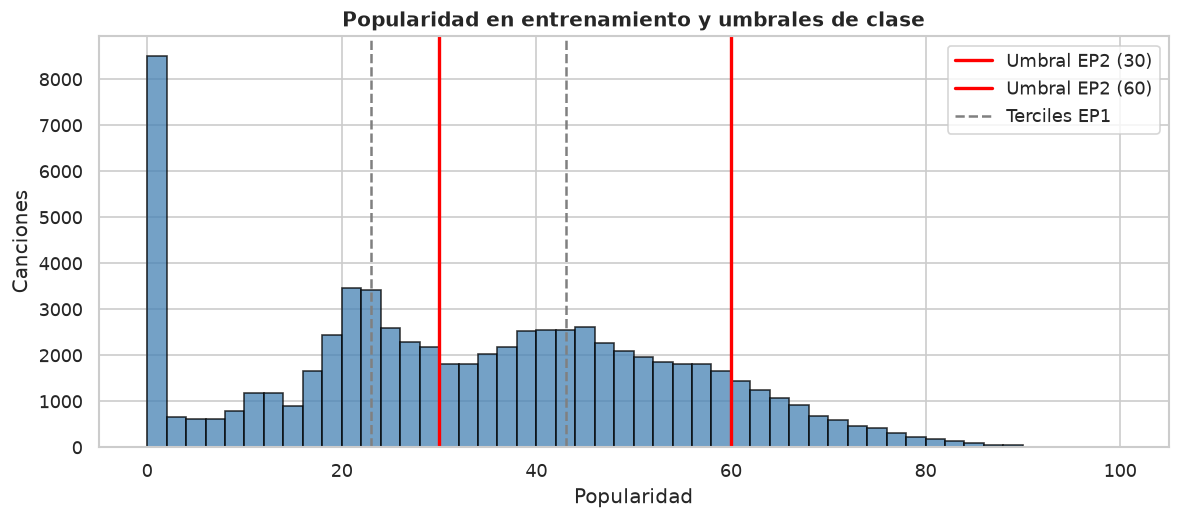

Canciones con popularidad 0 en entrenamiento: 10.6%


In [23]:
ETIQUETAS_CLASE = ['bajo', 'medio', 'alto']
CORTES_POPULARIDAD = [-np.inf, 30, 60, np.inf]
y_clase = pd.cut(y_reg, bins=CORTES_POPULARIDAD, right=False, labels=ETIQUETAS_CLASE).astype(str)
y_train_clf, y_test_clf = y_clase.iloc[idx_train], y_clase.iloc[idx_test]

distribucion = pd.DataFrame({
    'entrenamiento_n': y_train_clf.value_counts(),
    'entrenamiento_%': y_train_clf.value_counts(normalize=True).mul(100).round(1),
    'prueba_n': y_test_clf.value_counts(),
    'prueba_%': y_test_clf.value_counts(normalize=True).mul(100).round(1),
}).loc[ETIQUETAS_CLASE]
display(distribucion)
terciles_ep1 = y_train_reg.quantile([1/3, 2/3]).round(1).tolist()
print(f'Cortes por terciles que usaba EP1 (entrenamiento): {terciles_ep1} -> reemplazados por 30 y 60.')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(y_train_reg, bins=50, color='steelblue', edgecolor='black', alpha=0.75)
for corte, estilo, nombre in [(30, '-', 'Umbral EP2 (30)'), (60, '-', 'Umbral EP2 (60)')]:
    ax.axvline(corte, color='red', linestyle=estilo, linewidth=2, label=nombre)
for corte in terciles_ep1:
    ax.axvline(corte, color='gray', linestyle='--', linewidth=1.5)
ax.plot([], [], color='gray', linestyle='--', label='Terciles EP1')
ax.set_title('Popularidad en entrenamiento y umbrales de clase', fontweight='bold')
ax.set_xlabel('Popularidad'); ax.set_ylabel('Canciones'); ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '06_target_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Canciones con popularidad 0 en entrenamiento: {(y_train_reg == 0).mean():.1%}')

## Conclusiones Fase 3

- La limpieza de EP1 conserva el 99,86% de las filas; sus reglas se mantienen.
- El EDA muestra correlaciones lineales individuales débiles con la popularidad
  (|r| < 0,10) y diferencias marcadas por género: se esperan modelos no lineales y un peso
  importante del género.
- La base de modelamiento queda en **1 canción = 1 fila** (89.583 canciones, 114 columnas de
  género multi-hot) y la partición se agrupa por **artista + título**, eliminando la fuga
  por reediciones que tenía la partición por ID.
- Existen dos objetivos: popularidad continua (regresión) y nivel bajo/medio/alto con
  umbrales de negocio (clasificación, con la clase "alto" minoritaria).
- Cerca del 10% de las canciones tiene popularidad 0, muchas de ellas versiones
  duplicadas de una canción que sí es popular con otro ID: es ruido propio de la fuente
  que limitará el desempeño alcanzable.

## Fase 4: Modeling

### 4.1 Estrategia de validación

- **Selección de modelos e hiperparámetros solo con entrenamiento**, mediante validación
  cruzada `GroupKFold` de 3 pliegues agrupada por `clave_cancion` (una canción y sus
  reediciones nunca quedan en pliegues distintos).
- Todo el preprocesamiento y el balanceo van **dentro del pipeline**, por lo que se
  ajustan solo con los pliegues de entrenamiento de cada iteración.
- Búsqueda de hiperparámetros con `RandomizedSearchCV` (o búsqueda completa cuando la
  grilla es pequeña): más eficiente que una grilla exhaustiva con este volumen de datos.
- El **conjunto de prueba se usa una sola vez**, en la Fase 5, para los modelos finales.
- Se usan 3 pliegues (y no 5) para mantener el tiempo de ejecución razonable con ~72.000
  canciones; con este tamaño, la desviación entre pliegues es baja (se reporta).

In [24]:
cv_grupos = GroupKFold(n_splits=3)

def buscar_hiperparametros(nombre, pipeline, espacio, scoring, refit, n_iter, X_, y_):
    """Búsqueda aleatoria (o completa si la grilla es pequeña) con CV agrupada."""
    total = int(np.prod([len(v) for v in espacio.values()])) if espacio else 1
    inicio = time.time()
    busqueda = RandomizedSearchCV(
        pipeline, espacio, n_iter=min(n_iter, total), scoring=scoring, refit=refit,
        cv=cv_grupos, random_state=SEMILLA, n_jobs=1, error_score='raise',
    )
    busqueda.fit(X_, y_, groups=grupos_train)
    res = pd.DataFrame(busqueda.cv_results_).iloc[busqueda.best_index_]
    fila = {'modelo': nombre}
    for metrica in scoring:
        criterio = scoring[metrica]
        signo = -1 if isinstance(criterio, str) and criterio.startswith('neg_') else 1
        fila[f'{metrica}_cv'] = signo * res[f'mean_test_{metrica}']
        fila[f'{metrica}_std'] = res[f'std_test_{metrica}']
    fila['mejores_parametros'] = {k.replace('modelo__', ''): v for k, v in busqueda.best_params_.items()}
    fila['configuraciones_probadas'] = min(n_iter, total)
    fila['segundos'] = round(time.time() - inicio, 1)
    print(f"{nombre}: {fila['mejores_parametros']} ({fila['segundos']} s)")
    return busqueda.best_estimator_, fila

### 4.2 Aprendizaje supervisado — Regresión (target: `popularidad` 0–100)

**Baseline:** `DummyRegressor(strategy='mean')` predice siempre la popularidad media de
entrenamiento. Cualquier modelo útil debe superarlo.

**Selección de los 4 algoritmos** — se eligieron familias distintas para contrastar
supuestos (lineal vs. no lineal, paramétrico vs. basado en instancias, *bagging* vs.
*boosting*):

| # | Modelo | Familia | Por qué se incluye | Hiperparámetros explorados |
|---|---|---|---|---|
| R1 | `Ridge` | Lineal regularizado (L2) | Referencia interpretable. La penalización L2 controla la multicolinealidad observada en el EDA (energía ↔ volumen ≈ +0,76; energía ↔ acusticidad ≈ −0,74) y estabiliza los 114 coeficientes de género. | `alpha` (fuerza de regularización) |
| R2 | `KNeighborsRegressor` | Basado en instancias | Traduce la hipótesis de negocio "canciones que suenan parecido y son del mismo género tienen popularidad parecida". No asume forma funcional. | `n_neighbors`, `weights` |
| R3 | `RandomForestRegressor` | Ensamble *bagging* de árboles | Captura no linealidades e interacciones (p. ej., género × energía) que la correlación lineal no detecta; robusto a los outliers que la EP1 decidió conservar. | `max_features`, `min_samples_leaf`, `max_depth` |
| R4 | `HistGradientBoostingRegressor` | Ensamble *boosting* | Estado del arte en datos tabulares; corrige errores de forma secuencial y es muy eficiente con ~72.000 filas. | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` |

**Métrica de selección:** MAE (error medio en puntos de popularidad, directamente
interpretable por el negocio). Se reportan también RMSE (penaliza errores grandes) y R²
(proporción de varianza explicada). Para Random Forest se usan 150 árboles y
`max_samples=0.6` para acotar tiempo y tamaño del modelo.

In [25]:
scoring_reg = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}

# Baseline
cv_dummy = cross_validate(Pipeline([('prep', crear_preprocesador()), ('modelo', DummyRegressor())]),
                          X_train, y_train_reg, groups=grupos_train, cv=cv_grupos, scoring=scoring_reg)
fila_dummy_reg = {'modelo': 'Baseline (media)',
                  'MAE_cv': -cv_dummy['test_MAE'].mean(), 'MAE_std': cv_dummy['test_MAE'].std(),
                  'RMSE_cv': -cv_dummy['test_RMSE'].mean(), 'RMSE_std': cv_dummy['test_RMSE'].std(),
                  'R2_cv': cv_dummy['test_R2'].mean(), 'R2_std': cv_dummy['test_R2'].std()}

modelos_regresion = {
    'Ridge': (Ridge(), {'modelo__alpha': np.logspace(-2, 3, 11)}, 11),
    'KNN': (KNeighborsRegressor(n_jobs=-1),
            {'modelo__n_neighbors': [10, 20, 30, 50], 'modelo__weights': ['uniform', 'distance']}, 8),
    'Random Forest': (RandomForestRegressor(n_estimators=150, max_samples=0.6, n_jobs=-1, random_state=SEMILLA),
                      {'modelo__max_features': [0.2, 0.33, 0.5], 'modelo__min_samples_leaf': [5, 10, 20],
                       'modelo__max_depth': [None, 25]}, 5),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=SEMILLA),
                             {'modelo__learning_rate': [0.03, 0.05, 0.1], 'modelo__max_iter': [300, 600],
                              'modelo__max_leaf_nodes': [31, 63], 'modelo__min_samples_leaf': [20, 50, 100],
                              'modelo__l2_regularization': [0.0, 0.5, 1.0]}, 8),
}

regresores = {}
filas_reg = [fila_dummy_reg]
for nombre, (modelo, espacio, n_iter) in modelos_regresion.items():
    pipe = Pipeline([('prep', crear_preprocesador()), ('modelo', modelo)])
    regresores[nombre], fila = buscar_hiperparametros(nombre, pipe, espacio, scoring_reg, 'MAE',
                                                      n_iter, X_train, y_train_reg)
    filas_reg.append(fila)

resultados_cv_reg = pd.DataFrame(filas_reg).set_index('modelo')
resultados_cv_reg.to_csv(PROCESSED_DIR / 'resultados_cv_regresion.csv')
display(resultados_cv_reg.round(3))

Ridge: {'alpha': np.float64(0.01)} (7.7 s)


KNN: {'weights': 'distance', 'n_neighbors': 10} (66.7 s)


Random Forest: {'min_samples_leaf': 5, 'max_features': 0.33, 'max_depth': None} (284.2 s)


HistGradientBoosting: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 600, 'learning_rate': 0.03, 'l2_regularization': 0.5} (182.9 s)


,MAE_cv,MAE_std,RMSE_cv,RMSE_std,R2_cv,R2_std,mejores_parametros,configuraciones_probadas,segundos
modelo,,,,,,,,,
Baseline (media),17.2680,0.0290,20.6060,0.0140,-0.0000,0.0000,NaN,NaN,NaN
Ridge,11.8630,0.0680,16.5990,0.1380,0.3510,0.0110,{'alpha': 0.01},11.0000,7.7000
KNN,13.4970,0.0960,18.3570,0.1370,0.2060,0.0120,"{'weights': 'distance', 'n_neighbors': 10}",8.0000,66.7000
Random Forest,11.3440,0.1130,16.1450,0.2000,0.3860,0.0160,"{'min_samples_leaf': 5, 'max_features': 0.33, ...",5.0000,284.2000
HistGradientBoosting,11.1660,0.0890,16.0270,0.1680,0.3950,0.0130,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,...",8.0000,182.9000


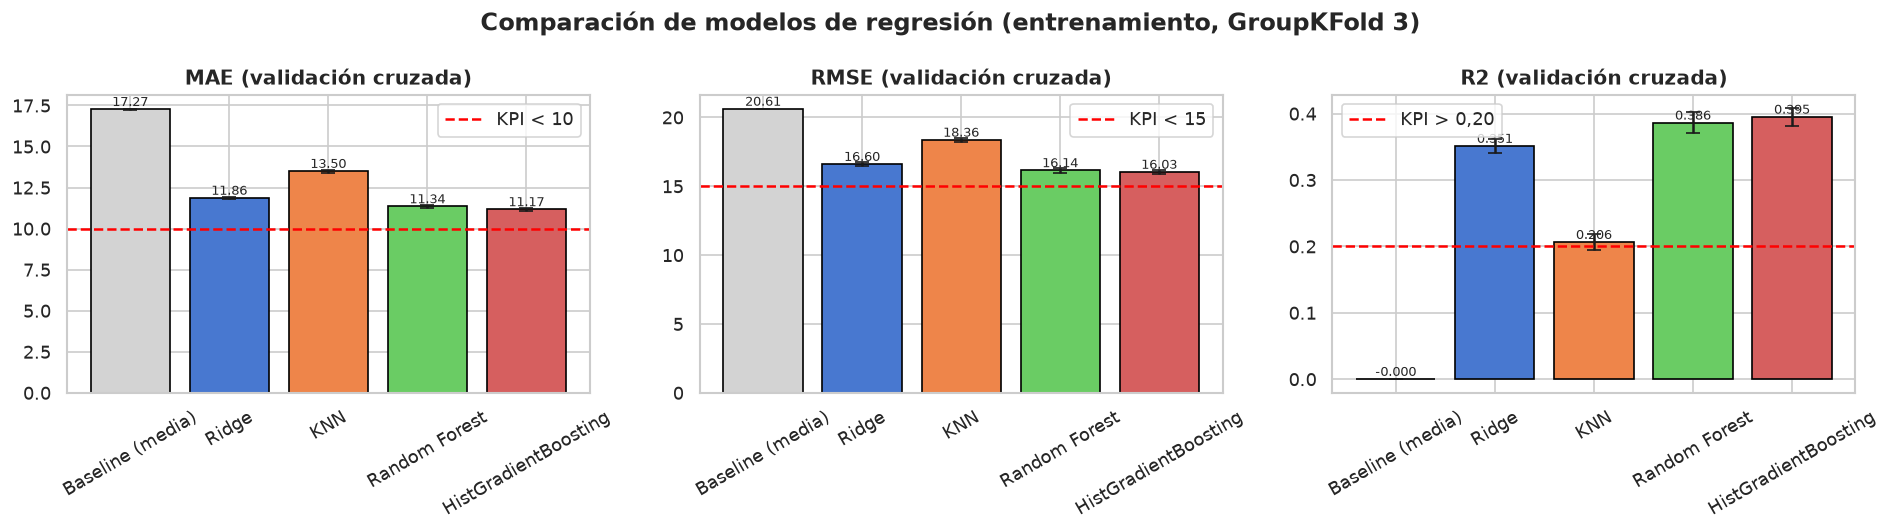

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
orden = resultados_cv_reg.index.tolist()
colores = ['lightgray'] + sns.color_palette('muted', len(orden) - 1)
for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(orden, resultados_cv_reg[f'{metrica}_cv'], yerr=resultados_cv_reg[f'{metrica}_std'],
           color=colores, edgecolor='black', capsize=4)
    ax.set_title(f'{metrica} (validación cruzada)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for x, v in enumerate(resultados_cv_reg[f'{metrica}_cv']):
        ax.text(x, v, f'{v:.2f}' if metrica != 'R2' else f'{v:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].axhline(10, color='red', linestyle='--', label='KPI < 10'); axes[0].legend()
axes[1].axhline(15, color='red', linestyle='--', label='KPI < 15'); axes[1].legend()
axes[2].axhline(0.20, color='red', linestyle='--', label='KPI > 0,20'); axes[2].legend()
plt.suptitle('Comparación de modelos de regresión (entrenamiento, GroupKFold 3)', fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '07_comparacion_regresion_cv.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretación — regresión (validación cruzada)

- Los cuatro modelos superan claramente al baseline (MAE 17,3): el mejor reduce el error
  medio en ~6 puntos de popularidad. La desviación entre pliegues es muy baja (≤ 0,11 en
  MAE), así que las diferencias entre modelos son estables.
- **HistGradientBoosting** (MAE 11,17; R² 0,395) y **Random Forest** (MAE 11,34; R² 0,386)
  son los mejores: confirman que existen **relaciones no lineales e interacciones** que el
  análisis de correlaciones de la EP1 no podía ver. Se elige HistGradientBoosting por menor
  MAE, menor tiempo de entrenamiento (~3× más rápido que RF) y un modelo 20 veces más liviano.
- **Ridge** queda cerca (R² 0,35) porque la mayor parte de la señal viene del género, que es
  un efecto casi aditivo. El `alpha` óptimo es bajo (0,01): con ~72.000 filas casi no hace
  falta regularizar.
- **KNN** es el peor (R² 0,21): con 144 dimensiones, la mayoría binarias, las distancias
  pierden capacidad de discriminar (*maldición de la dimensionalidad*).

### 4.3 Aprendizaje supervisado — Clasificación (target: bajo / medio / alto)

**Baseline:** `DummyClassifier(strategy='most_frequent')` (predice siempre "medio").

**Selección de los 4 algoritmos** (mismas familias que en regresión, para que la
comparación entre ambos enfoques sea coherente):

| # | Modelo | Familia | Por qué se incluye |
|---|---|---|---|
| C1 | `LogisticRegression` (multinomial) | Lineal probabilístico | Referencia interpretable; entrega probabilidades calibradas por clase, útiles para priorizar canciones. Regularización L2 (`C`). |
| C2 | `KNeighborsClassifier` | Basado en instancias | "Vecinos sonoros": clasifica según canciones similares. Sin supuestos de forma funcional. |
| C3 | `RandomForestClassifier` | *Bagging* de árboles | El modelo propuesto en EP1: no lineal, captura interacciones, robusto a outliers y admite `class_weight`. |
| C4 | `HistGradientBoostingClassifier` | *Boosting* | Suele ser el más preciso en datos tabulares; rápido y con `class_weight`. |

**Métrica de selección:** **F1 macro**, porque promedia por igual las tres clases y no se
deja engañar por la mayoría (un modelo que nunca predice "alto" puede tener buena
accuracy y F1 macro bajo). Se reportan también accuracy, *balanced accuracy* y el
**recall de la clase "alto"** (proporción de canciones realmente populares que el modelo
detecta: el error más costoso para el negocio es dejar pasar un éxito).

#### 4.3.1 Comparación de métodos de balanceo

La clase "alto" representa ~11% de las canciones. Se comparan, para **cada** algoritmo y
dentro de la validación cruzada (el remuestreo se aplica solo a los pliegues de
entrenamiento, nunca a los de validación):

| Método | Tipo | Idea | Riesgo |
|---|---|---|---|
| Sin balanceo | — | Referencia | El modelo puede ignorar la clase minoritaria |
| `class_weight='balanced'` | Sensible al costo | Penaliza más los errores en clases minoritarias, sin cambiar los datos | No disponible en KNN |
| `RandomUnderSampler` (RUS) | Submuestreo | Elimina filas de las clases mayoritarias | Pierde información (~70% de las filas) |
| `RandomOverSampler` (ROS) | Sobremuestreo | Duplica filas de las clases minoritarias | Sobreajuste a duplicados |
| `SMOTE` | Sobremuestreo sintético | Interpola nuevas canciones "alto" entre vecinos | Sobre columnas 0/1 (one-hot/multi-hot) genera valores fraccionarios |
| `SMOTENC` (solo HistGradientBoosting) | SMOTE para variables mixtas | Interpola numéricas y asigna categorías por votación de vecinos | ~15 veces más lento; se prueba en un solo modelo para contrastar con SMOTE |

Para esta comparación se usan hiperparámetros razonables por defecto; luego se ajustan
los hiperparámetros de cada modelo con su mejor método de balanceo (4.3.2).

In [27]:
recall_alto = make_scorer(recall_score, labels=['alto'], average='macro', zero_division=0)
scoring_clf = {'F1_macro': 'f1_macro', 'Accuracy': 'accuracy',
               'Balanced_acc': 'balanced_accuracy', 'Recall_alto': recall_alto}
EJECUTAR_SMOTENC = True  # ~5 minutos adicionales; poner False para una ejecución rápida.

clasificadores_base = {
    'Regresión logística': LogisticRegression(max_iter=2000),
    'KNN': KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=150, min_samples_leaf=3, n_jobs=-1, random_state=SEMILLA),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEMILLA),
}
metodos_balanceo = {
    'Sin balanceo': None,
    'class_weight': 'class_weight',
    'RUS': RandomUnderSampler(random_state=SEMILLA),
    'ROS': RandomOverSampler(random_state=SEMILLA),
    'SMOTE': SMOTE(random_state=SEMILLA),
}

def crear_pipeline_clf(modelo, metodo):
    """Pipeline de imblearn: el remuestreo ocurre solo al ajustar (pliegues de entrenamiento)."""
    modelo = clone(modelo)
    if metodo == 'class_weight':
        if 'class_weight' not in modelo.get_params():
            return None
        modelo.set_params(class_weight='balanced')
        return PipelineImb([('prep', crear_preprocesador()), ('modelo', modelo)])
    if metodo == 'SMOTENC':
        # SMOTENC necesita las variables originales: se imputa el compás antes de remuestrear.
        imputar_compas = ColumnTransformer(
            [('compas', SimpleImputer(strategy='most_frequent'), ['compas'])],
            remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        categoricas_smotenc = variables_categoricas_modelo + columnas_genero
        return PipelineImb([('imputar', imputar_compas),
                            ('balanceo', SMOTENC(categorical_features=categoricas_smotenc, random_state=SEMILLA)),
                            ('prep', crear_preprocesador()), ('modelo', modelo)])
    pasos = [('prep', crear_preprocesador())]
    if metodo is not None:
        pasos.append(('balanceo', clone(metodo)))
    return PipelineImb(pasos + [('modelo', modelo)])

filas_balanceo = []
combinaciones = [(m, b) for m in clasificadores_base for b in metodos_balanceo]
if EJECUTAR_SMOTENC:
    combinaciones.append(('HistGradientBoosting', 'SMOTENC'))
for nombre_modelo, nombre_metodo in combinaciones:
    metodo = metodos_balanceo.get(nombre_metodo, nombre_metodo)
    pipe = crear_pipeline_clf(clasificadores_base[nombre_modelo], metodo)
    if pipe is None:
        continue
    inicio = time.time()
    r = cross_validate(pipe, X_train, y_train_clf, groups=grupos_train, cv=cv_grupos,
                       scoring=scoring_clf, error_score='raise')
    fila = {'modelo': nombre_modelo, 'balanceo': nombre_metodo}
    for metrica in scoring_clf:
        fila[metrica] = r[f'test_{metrica}'].mean()
    fila['F1_macro_std'] = r['test_F1_macro'].std()
    fila['segundos'] = round(time.time() - inicio, 1)
    filas_balanceo.append(fila)
    print(f"{nombre_modelo:22s} | {nombre_metodo:12s} | F1 macro {fila['F1_macro']:.3f} | "
          f"recall alto {fila['Recall_alto']:.3f} | {fila['segundos']} s")

resultados_balanceo = pd.DataFrame(filas_balanceo)
resultados_balanceo.to_csv(PROCESSED_DIR / 'resultados_balanceo.csv', index=False)

Regresión logística    | Sin balanceo | F1 macro 0.604 | recall alto 0.197 | 34.6 s


Regresión logística    | class_weight | F1 macro 0.617 | recall alto 0.739 | 35.9 s


Regresión logística    | RUS          | F1 macro 0.617 | recall alto 0.728 | 16.0 s


Regresión logística    | ROS          | F1 macro 0.615 | recall alto 0.736 | 45.5 s


Regresión logística    | SMOTE        | F1 macro 0.620 | recall alto 0.716 | 46.1 s


...

HistGradientBoosting   | class_weight | F1 macro 0.645 | recall alto 0.727 | 21.2 s


HistGradientBoosting   | RUS          | F1 macro 0.628 | recall alto 0.741 | 8.7 s


HistGradientBoosting   | ROS          | F1 macro 0.644 | recall alto 0.721 | 17.4 s


HistGradientBoosting   | SMOTE        | F1 macro 0.666 | recall alto 0.479 | 21.2 s


HistGradientBoosting   | SMOTENC      | F1 macro 0.660 | recall alto 0.448 | 350.5 s


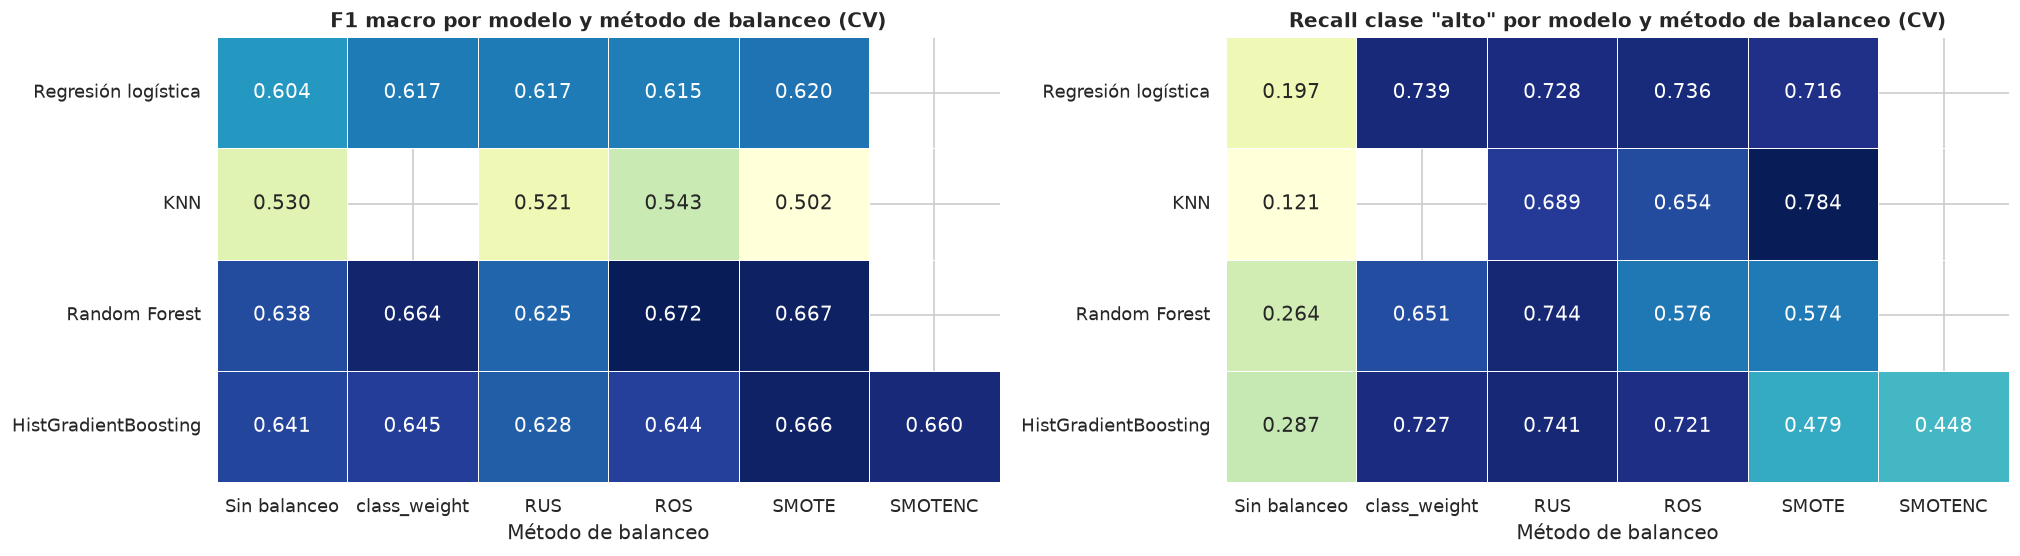

Mejor método de balanceo por modelo (criterio: F1 macro en CV):


,balanceo,F1_macro,Recall_alto,Balanced_acc,Accuracy
modelo,,,,,
Regresión logística,SMOTE,0.6200,0.7160,0.6770,0.6650
KNN,ROS,0.5430,0.6540,0.5990,0.5810
Random Forest,ROS,0.6720,0.5760,0.6880,0.7250
HistGradientBoosting,SMOTE,0.6660,0.4790,0.6690,0.7330


Promedio de cada método sobre los modelos en que se aplicó:


,F1_macro,Recall_alto,Accuracy
balanceo,,,
Sin balanceo,0.6030,0.2170,0.7180
class_weight,0.6420,0.7060,0.6870
RUS,0.5980,0.7260,0.6370
ROS,0.6180,0.6720,0.6630
SMOTE,0.6140,0.6380,0.6600
SMOTENC,0.6600,0.4480,0.7320


In [28]:
orden_metodos = list(metodos_balanceo) + (['SMOTENC'] if EJECUTAR_SMOTENC else [])
fig, axes = plt.subplots(1, 2, figsize=(17, 4.8))
for ax, metrica, titulo in [(axes[0], 'F1_macro', 'F1 macro'), (axes[1], 'Recall_alto', 'Recall clase "alto"')]:
    tabla = resultados_balanceo.pivot(index='modelo', columns='balanceo', values=metrica)
    tabla = tabla.reindex(index=list(clasificadores_base), columns=orden_metodos)
    sns.heatmap(tabla, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar=False,
                linewidths=0.5, mask=tabla.isna())
    ax.set_title(f'{titulo} por modelo y método de balanceo (CV)', fontweight='bold')
    ax.set_xlabel('Método de balanceo'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '08_comparacion_balanceo.png', dpi=150, bbox_inches='tight')
plt.show()

mejor_balanceo = (resultados_balanceo.sort_values('F1_macro', ascending=False)
                  .groupby('modelo', sort=False).head(1).set_index('modelo')
                  .reindex(list(clasificadores_base)))
print('Mejor método de balanceo por modelo (criterio: F1 macro en CV):')
display(mejor_balanceo[['balanceo', 'F1_macro', 'Recall_alto', 'Balanced_acc', 'Accuracy']].round(3))
resumen_metodo = resultados_balanceo.groupby('balanceo')[['F1_macro', 'Recall_alto', 'Accuracy']].mean()
print('Promedio de cada método sobre los modelos en que se aplicó:')
display(resumen_metodo.reindex(orden_metodos).round(3))

#### Interpretación — métodos de balanceo

- **Sin balanceo**, todos los modelos casi ignoran la clase minoritaria: el recall de "alto"
  queda entre 0,12 y 0,29, aunque la accuracy sea la más alta. Por eso la accuracy no sirve
  como criterio único.
- **Todos los métodos de balanceo mejoran el F1 macro** respecto de no balancear, pero con
  un *trade-off* claro:
  - `class_weight`, RUS y ROS (en modelos lineales/boosting) suben mucho el recall de
    "alto" (0,65–0,74), a costa de más falsos positivos.
  - SMOTE y ROS en los modelos de árboles dan el **mejor F1 macro** (≈ 0,67), con un
    recall de "alto" más moderado (0,48–0,58).
  - **RUS** es el peor en F1 macro: descarta ~70% de los datos de entrenamiento.
  - **SMOTENC**, la variante teóricamente correcta para variables categóricas, **no mejoró**
    a SMOTE (0,660 vs 0,666) y tardó ~16 veces más. Los árboles cortan las columnas 0/1 en
    un umbral, así que los valores fraccionarios que genera SMOTE no los perjudican en la
    práctica. Por eso se descarta SMOTENC.
- **Método elegido por modelo** (mayor F1 macro en CV): SMOTE para regresión logística y
  HistGradientBoosting, y ROS para KNN y Random Forest. Considerando todos los modelos,
  `class_weight` tiene el mejor promedio y no aumenta el tamaño de los datos. Es la
  alternativa recomendada si se prioriza el **recall** de "alto".

#### 4.3.2 Ajuste de hiperparámetros con el mejor balanceo de cada modelo

Cada algoritmo se ajusta con el método de balanceo que obtuvo el mejor F1 macro en 4.3.1.
Si para HistGradientBoosting gana SMOTENC, el pipeline incluye la imputación previa.

In [29]:
espacios_clf = {
    'Regresión logística': ({'modelo__C': [0.01, 0.1, 1.0, 10.0]}, 4),
    'KNN': ({'modelo__n_neighbors': [15, 25, 40, 60], 'modelo__weights': ['uniform', 'distance']}, 8),
    'Random Forest': ({'modelo__max_features': ['sqrt', 0.2, 0.33], 'modelo__min_samples_leaf': [3, 5, 10],
                       'modelo__max_depth': [None, 25]}, 5),
    'HistGradientBoosting': ({'modelo__learning_rate': [0.03, 0.05, 0.1], 'modelo__max_iter': [300, 600],
                              'modelo__max_leaf_nodes': [31, 63], 'modelo__min_samples_leaf': [20, 50, 100],
                              'modelo__l2_regularization': [0.0, 0.5, 1.0]}, 6),
}
clasificadores = {}
filas_clf = []

cv_dummy_clf = cross_validate(PipelineImb([('prep', crear_preprocesador()),
                                           ('modelo', DummyClassifier(strategy='most_frequent'))]),
                              X_train, y_train_clf, groups=grupos_train, cv=cv_grupos, scoring=scoring_clf)
filas_clf.append({'modelo': 'Baseline (clase mayoritaria)', 'balanceo': '—',
                  **{f'{m}_cv': cv_dummy_clf[f'test_{m}'].mean() for m in scoring_clf}})

for nombre, (espacio, n_iter) in espacios_clf.items():
    nombre_metodo = mejor_balanceo.loc[nombre, 'balanceo']
    metodo = metodos_balanceo.get(nombre_metodo, nombre_metodo)
    pipe = crear_pipeline_clf(clasificadores_base[nombre], metodo)
    clasificadores[nombre], fila = buscar_hiperparametros(
        f'{nombre} + {nombre_metodo}', pipe, espacio, scoring_clf, 'F1_macro', n_iter, X_train, y_train_clf)
    fila['modelo'] = nombre
    fila['balanceo'] = nombre_metodo
    filas_clf.append(fila)

resultados_cv_clf = pd.DataFrame(filas_clf).set_index('modelo')
resultados_cv_clf.to_csv(PROCESSED_DIR / 'resultados_cv_clasificacion.csv')
display(resultados_cv_clf[['balanceo', 'F1_macro_cv', 'F1_macro_std', 'Accuracy_cv', 'Balanced_acc_cv',
                           'Recall_alto_cv', 'mejores_parametros', 'segundos']].round(3))

Regresión logística + SMOTE: {'C': 1.0} (185.2 s)


KNN + ROS: {'weights': 'distance', 'n_neighbors': 25} (104.8 s)


Random Forest + ROS: {'min_samples_leaf': 3, 'max_features': 0.2, 'max_depth': None} (316.5 s)


HistGradientBoosting + SMOTE: {'min_samples_leaf': 50, 'max_leaf_nodes': 63, 'max_iter': 300, 'learning_rate': 0.03, 'l2_regularization': 0.0} (508.5 s)


,balanceo,F1_macro_cv,F1_macro_std,Accuracy_cv,Balanced_acc_cv,Recall_alto_cv,mejores_parametros,segundos
modelo,,,,,,,,
Baseline (clase mayoritaria),—,0.2080,NaN,0.4520,0.3330,0.0000,NaN,NaN
Regresión logística,SMOTE,0.6200,0.0020,0.6650,0.6770,0.7160,{'C': 1.0},185.2000
KNN,ROS,0.5500,0.0020,0.5900,0.6010,0.6340,"{'weights': 'distance', 'n_neighbors': 25}",104.8000
Random Forest,ROS,0.6720,0.0050,0.7320,0.6780,0.5170,"{'min_samples_leaf': 3, 'max_features': 0.2, '...",316.5000
HistGradientBoosting,SMOTE,0.6680,0.0040,0.7360,0.6680,0.4650,"{'min_samples_leaf': 50, 'max_leaf_nodes': 63,...",508.5000


#### Interpretación — clasificación (validación cruzada)

- Todos los modelos superan con holgura al baseline (F1 macro 0,21).
- **Random Forest + ROS** obtiene el mejor F1 macro (0,672) y la mejor accuracy, seguido de
  cerca por **HistGradientBoosting + SMOTE** (0,668). Es el modelo propuesto en la EP1, ahora
  validado.
- La **regresión logística + SMOTE** tiene menor F1 macro (0,620), pero el **mayor recall de
  "alto"** (0,716). Si la prioridad del negocio fuera "no perder ningún posible éxito",
  sería la candidata.
- KNN vuelve a ser el más débil, por la misma razón que en regresión.

### 4.4 Aprendizaje no supervisado 1 — K-Means: perfiles sonoros del catálogo

**Objetivo de negocio:** segmentar las canciones en **perfiles sonoros** (p. ej.,
"acústicas y tranquilas", "electrónicas instrumentales", "enérgicas y bailables") usando
**solo atributos de audio**, para (a) armar playlists por estado de ánimo/contexto sin
depender de la etiqueta de género, (b) detectar qué perfiles concentran mayor popularidad
y (c) verificar si los géneros etiquetados corresponden a sonidos realmente distintos.

**Decisiones:**
- **Variables:** bailabilidad, energía, volumen, habla, acusticidad, instrumentalidad,
  presencia en vivo, positividad y tempo. Se excluyen la popularidad (es lo que se quiere
  explicar después, no un insumo del agrupamiento), el género (se usa para validar), la
  duración y los códigos tonalidad/modo/compás (no describen el "sonido" percibido y, al
  ser categóricos, distorsionan las distancias euclidianas).
- **Escalado:** `StandardScaler`, porque K-Means usa distancias y volumen (dB) o tempo
  (BPM) dominarían a las variables 0–1.
- **Algoritmo:** K-Means es escalable a ~72.000 canciones y produce centroides
  directamente interpretables como "canción típica" de cada perfil.
- **Elección de k:** método del codo (inercia) + coeficiente de silueta (muestra de
  10.000 canciones) para k = 2…10. Por negocio se buscan **entre 4 y 8 perfiles**
  (menos de 4 es demasiado grueso para curaduría; más de 8 es difícil de gestionar), y
  dentro de ese rango se elige la k con mayor silueta.
- Se ajusta con las canciones de **entrenamiento** y se valida asignando las de prueba.

,inercia,silueta,davies_bouldin,calinski_harabasz
k,,,,
2,"506,203.0730",0.2600,1.5790,"19,763.5970"
3,"449,268.0600",0.1660,1.9080,"15,679.5660"
4,"403,930.6990",0.1740,1.6980,"14,309.9760"
5,"364,749.3070",0.1780,1.5170,"13,811.6360"
6,"331,299.5410",0.1910,1.4430,"13,613.2600"
7,"301,216.1690",0.1980,1.3820,"13,671.2420"
8,"284,243.5360",0.1800,1.3860,"13,029.6600"
9,"269,518.2710",0.1840,1.3710,"12,513.5920"
10,"258,432.9140",0.1700,1.4320,"11,942.0020"


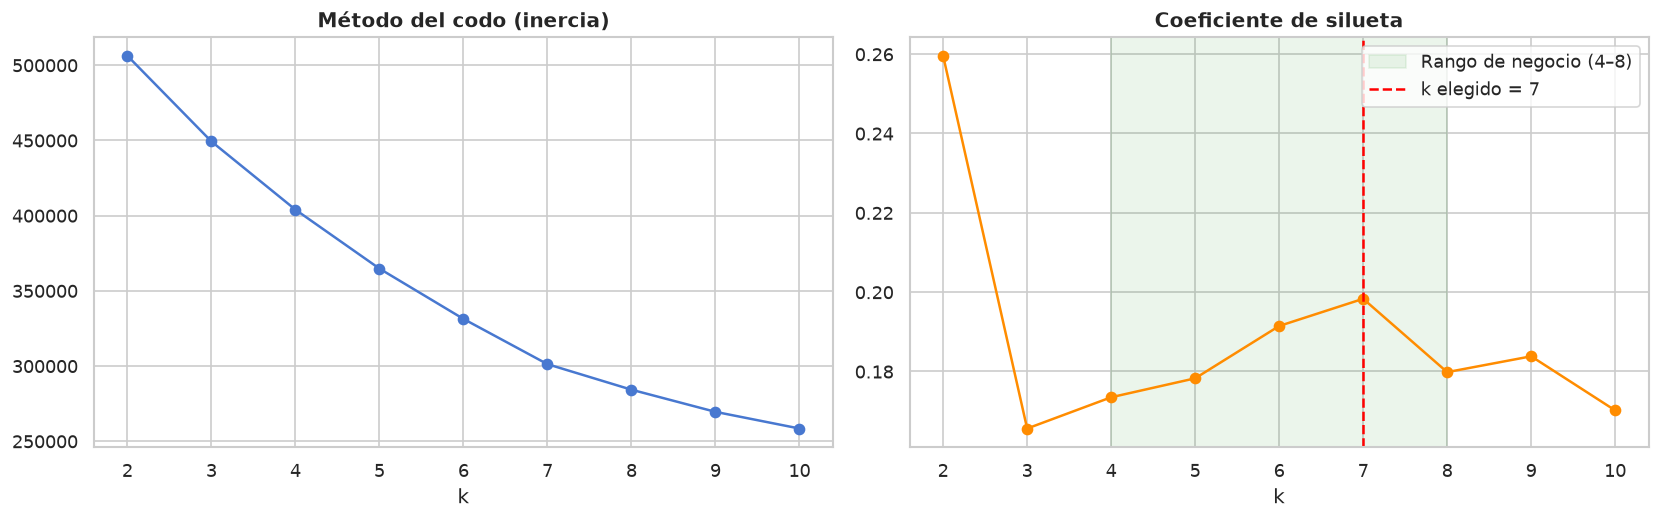

k elegido: 7 (máxima silueta dentro del rango de negocio 4–8)


In [30]:
variables_cluster = ['bailabilidad', 'energia', 'volumen_db', 'presencia_habla', 'acusticidad',
                     'instrumentalidad', 'presencia_en_vivo', 'positividad', 'tempo_bpm']
escalador_cluster = StandardScaler().fit(X_train[variables_cluster])
Z_train = escalador_cluster.transform(X_train[variables_cluster])
Z_test = escalador_cluster.transform(X_test[variables_cluster])
rng = np.random.default_rng(SEMILLA)
muestra_sil = rng.choice(len(Z_train), size=10_000, replace=False)

filas_k = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(Z_train)
    filas_k.append({'k': k, 'inercia': km.inertia_,
                    'silueta': silhouette_score(Z_train[muestra_sil], km.labels_[muestra_sil]),
                    'davies_bouldin': davies_bouldin_score(Z_train, km.labels_),
                    'calinski_harabasz': calinski_harabasz_score(Z_train, km.labels_)})
seleccion_k = pd.DataFrame(filas_k).set_index('k')
display(seleccion_k.round(3))

K_PERFILES = int(seleccion_k.loc[4:8, 'silueta'].idxmax())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(seleccion_k.index, seleccion_k['inercia'], marker='o')
axes[0].set_title('Método del codo (inercia)', fontweight='bold'); axes[0].set_xlabel('k')
axes[1].plot(seleccion_k.index, seleccion_k['silueta'], marker='o', color='darkorange')
axes[1].axvspan(4, 8, color='green', alpha=0.08, label='Rango de negocio (4–8)')
axes[1].axvline(K_PERFILES, color='red', linestyle='--', label=f'k elegido = {K_PERFILES}')
axes[1].set_title('Coeficiente de silueta', fontweight='bold'); axes[1].set_xlabel('k'); axes[1].legend()
for ax in axes: ax.set_xticks(seleccion_k.index)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '09_kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'k elegido: {K_PERFILES} (máxima silueta dentro del rango de negocio 4–8)')

,valor
k,7.0000
silueta_train,0.1980
silueta_test,0.1920
davies_bouldin_train,1.3820
ARI_estabilidad_semillas,0.9960


,bailabilidad,energia,volumen_db,presencia_habla,acusticidad,instrumentalidad,presencia_en_vivo,positividad,tempo_bpm,canciones,popularidad_media,pct_alto,pct_catalogo,top_generos
0,0.5240,0.7520,-7.0920,0.0880,0.2900,0.0770,0.7460,0.5100,123.4050,4924,35.4000,6.5000,6.9000,"pagode, sertanejo, samba, mpb, forro"
1,0.4720,0.8150,-5.3570,0.0850,0.0770,0.0360,0.1950,0.3730,140.1480,16213,35.4000,12.6000,22.6000,"heavy-metal, grunge, hardstyle, metalcore, dea..."
2,0.7070,0.7150,-6.5600,0.0960,0.2200,0.0210,0.1640,0.6970,118.1370,22105,34.4000,14.6000,30.8000,"dancehall, salsa, kids, dance, forro"
3,0.3490,0.1710,-21.2210,0.0520,0.8690,0.7910,0.1550,0.1860,104.8550,5115,28.4000,6.6000,7.1000,"new-age, classical, sleep, ambient, iranian"
4,0.5820,0.7400,-8.4460,0.0720,0.1130,0.7950,0.1710,0.3450,126.6900,8078,27.4000,3.6000,11.3000,"minimal-techno, detroit-techno, study, grindco..."
5,0.5250,0.3720,-10.6960,0.0530,0.6890,0.0320,0.1600,0.3910,113.1180,14465,33.4000,10.9000,20.2000,"tango, honky-tonk, romance, cantopop, acoustic"
6,0.5730,0.6720,-11.2790,0.8430,0.7500,0.0040,0.6720,0.4460,101.8260,840,24.5000,1.3000,1.2000,"comedy, show-tunes, kids, children, french"


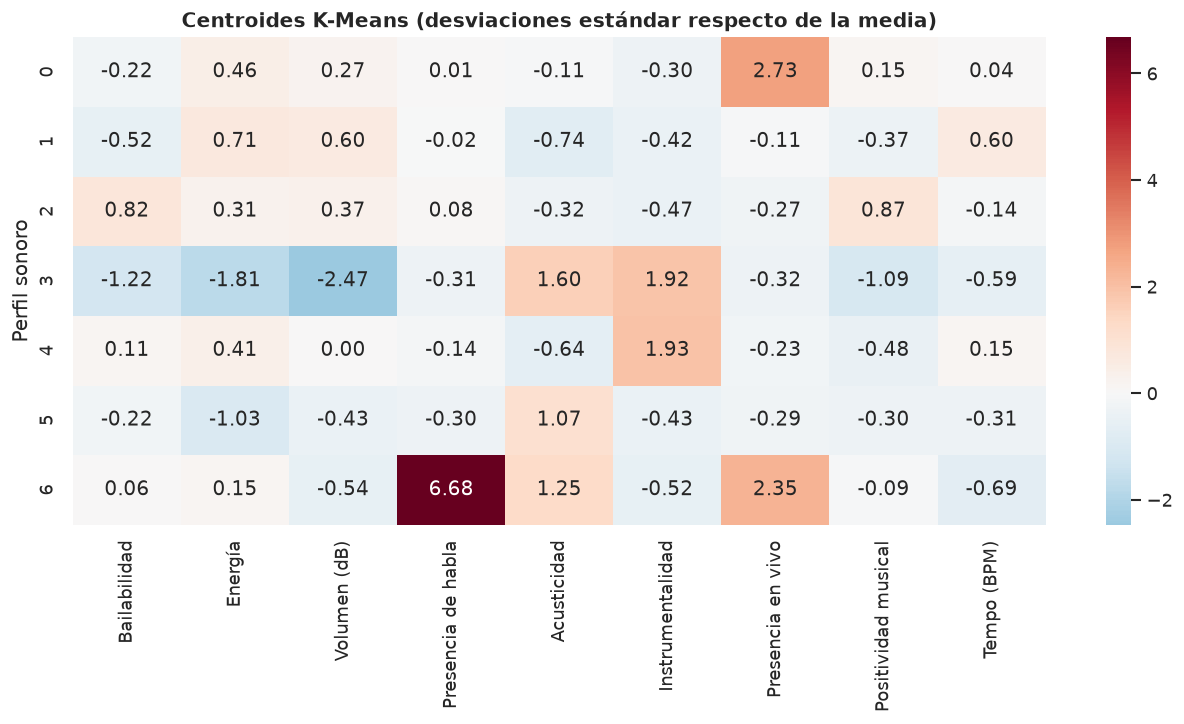

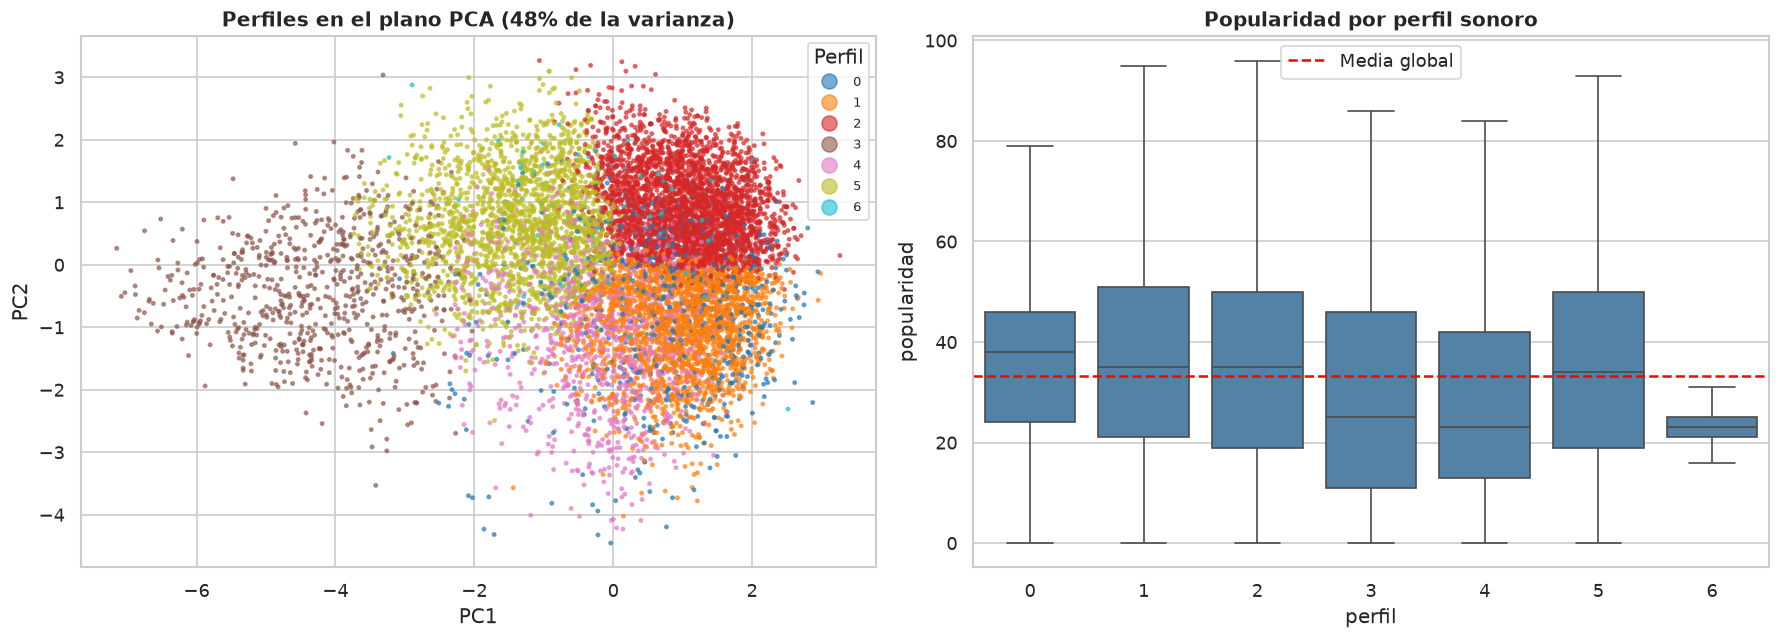

In [31]:
kmeans = KMeans(n_clusters=K_PERFILES, n_init=10, random_state=SEMILLA).fit(Z_train)
perfil_train = kmeans.labels_
perfil_test = kmeans.predict(Z_test)

# Estabilidad: ¿se obtienen los mismos grupos con otras semillas?
ari_semillas = [adjusted_rand_score(perfil_train,
                                    KMeans(n_clusters=K_PERFILES, n_init=10, random_state=s).fit_predict(Z_train))
                for s in [1, 7, 21, 99]]
metricas_kmeans = {
    'k': K_PERFILES,
    'silueta_train': silhouette_score(Z_train[muestra_sil], perfil_train[muestra_sil]),
    'silueta_test': silhouette_score(Z_test, perfil_test, sample_size=10_000, random_state=SEMILLA),
    'davies_bouldin_train': davies_bouldin_score(Z_train, perfil_train),
    'ARI_estabilidad_semillas': float(np.mean(ari_semillas)),
}
display(pd.Series(metricas_kmeans).round(3).to_frame('valor'))

# Perfil de cada grupo: centroides en unidades originales + tamaño + popularidad
centroides = pd.DataFrame(escalador_cluster.inverse_transform(kmeans.cluster_centers_),
                          columns=variables_cluster)
centroides_z = pd.DataFrame(kmeans.cluster_centers_, columns=variables_cluster)
info_train = pd.DataFrame({'perfil': perfil_train, 'popularidad': y_train_reg.to_numpy(),
                           'clase': y_train_clf.to_numpy(),
                           'genero_principal': df_modelo['genero_principal'].iloc[idx_train].to_numpy()})
resumen_perfiles = info_train.groupby('perfil').agg(
    canciones=('popularidad', 'size'), popularidad_media=('popularidad', 'mean'),
    pct_alto=('clase', lambda s: 100 * s.eq('alto').mean()))
resumen_perfiles['pct_catalogo'] = 100 * resumen_perfiles['canciones'] / len(info_train)
resumen_perfiles['top_generos'] = info_train.groupby('perfil')['genero_principal'].agg(
    lambda s: ', '.join(s.value_counts().head(5).index))
display(centroides.round(3).join(resumen_perfiles.round(1)))

fig, ax = plt.subplots(figsize=(11, 0.6 * K_PERFILES + 2))
sns.heatmap(centroides_z.rename(columns=ETIQUETAS), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Centroides K-Means (desviaciones estándar respecto de la media)', fontweight='bold')
ax.set_ylabel('Perfil sonoro')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '10_kmeans_centroides.png', dpi=150, bbox_inches='tight')
plt.show()

pca = PCA(n_components=2, random_state=SEMILLA).fit(Z_train)
proy = pca.transform(Z_train[muestra_sil])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sc = axes[0].scatter(proy[:, 0], proy[:, 1], c=perfil_train[muestra_sil], cmap='tab10', s=4, alpha=0.6)
axes[0].legend(*sc.legend_elements(), title='Perfil', fontsize=8, markerscale=1.5)
axes[0].set_title(f'Perfiles en el plano PCA ({pca.explained_variance_ratio_.sum():.0%} de la varianza)',
                  fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
sns.boxplot(data=info_train, x='perfil', y='popularidad', ax=axes[1], showfliers=False, color='steelblue')
axes[1].axhline(y_train_reg.mean(), color='red', linestyle='--', label='Media global')
axes[1].set_title('Popularidad por perfil sonoro', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '11_kmeans_pca_popularidad.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretación — perfiles sonoros (K-Means, k = 7)

- **Calidad del agrupamiento:** silueta 0,198 en entrenamiento y **0,192 en prueba**. Es
  una estructura débil-moderada, esperable en datos de audio, donde los estilos forman un
  continuo y no grupos separados. Que la silueta se mantenga en prueba muestra que los
  perfiles **generalizan** a canciones nuevas, y el ARI de 0,996 entre semillas indica que
  la solución es **estable**. k = 2 tiene mayor silueta, pero solo separa
  "acústico/tranquilo" de "eléctrico/enérgico", lo que no sirve para curaduría.
- **Perfiles encontrados** (nombres asignados a partir de los centroides):

| Perfil | Nombre propuesto | Rasgos (centroide) | % catálogo | Pop. media | % "alto" |
|---|---|---|---|---|---|
| 2 | **Bailables y alegres** | bailabilidad 0,71, positividad 0,70 | 30,8% | 34,4 | **14,6%** |
| 1 | **Intensas y ruidosas** | energía 0,82, volumen −5,4 dB, tempo 140 | 22,6% | 35,4 | 12,6% |
| 5 | **Acústicas melódicas** | acusticidad 0,69, energía 0,37 | 20,2% | 33,4 | 10,9% |
| 4 | **Electrónica instrumental** | instrumentalidad 0,80, energía 0,74 | 11,3% | 27,4 | 3,6% |
| 3 | **Ambientales / clásicas** | acusticidad 0,87, instrumentalidad 0,79, volumen −21 dB | 7,1% | 28,4 | 6,6% |
| 0 | **En vivo** | presencia en vivo 0,75 (pagode, sertanejo, samba) | 6,9% | 35,4 | 6,5% |
| 6 | **Habladas** | presencia de habla 0,84 (comedia, musicales) | 1,2% | 24,5 | 1,3% |

- **Lectura de negocio:** los perfiles con voz cantada y alta energía o positividad
  (bailables e intensas) concentran **la mayor proporción de canciones "alto"**, 4 veces
  más que la electrónica instrumental. Los perfiles instrumentales, ambientales y hablados
  tienen menos tracción. Sirven para playlists por contexto (fiesta, foco, relajación),
  pero no son candidatos naturales a promoción masiva.

### 4.5 Aprendizaje no supervisado 2 — Clustering jerárquico: familias de géneros

**Objetivo de negocio:** el catálogo usa **114 géneros**, demasiados para gestionar
secciones editoriales o reportes. Se busca **agrupar los géneros en familias** según su
sonido promedio, para (a) organizar el catálogo y las recomendaciones "si te gusta X,
prueba Y", (b) detectar etiquetas de género redundantes y (c) evaluar si una taxonomía
compacta conserva la información de género para predecir popularidad.

**Decisiones:**
- **Unidad de análisis:** cada género es una observación descrita por el **perfil medio**
  (estandarizado) de sus canciones de entrenamiento en las 9 variables de audio de 4.4.
  Usar solo entrenamiento permite usar luego las familias como variable sin fuga.
- **Algoritmo:** `AgglomerativeClustering` con enlace de **Ward**. Con solo 114
  observaciones el costo es trivial, el **dendrograma** muestra toda la jerarquía (se
  puede cortar a distintos niveles según la necesidad editorial) y Ward produce grupos
  compactos, comparables con K-Means. Se diferencia de K-Means en que no fija k de
  antemano ni depende de la inicialización.
- **Número de familias:** silueta para k = 4…15; por negocio se busca entre 6 y 12
  familias (similar a las secciones de una plataforma de streaming).

Matriz de perfiles de género: (114, 9)


k,4,5,6,7,8,9,10,11,12,13,14,15
silueta,0.2730,0.2500,0.2470,0.2360,0.2340,0.2550,0.2610,0.2740,0.2580,0.2590,0.2440,0.2460
davies_bouldin,0.9280,1.0590,0.9160,0.9900,1.0380,0.9750,0.9750,0.8990,1.0070,0.9460,1.0090,1.0060


Número de familias elegido: 11 (máxima silueta dentro del rango 6–12)


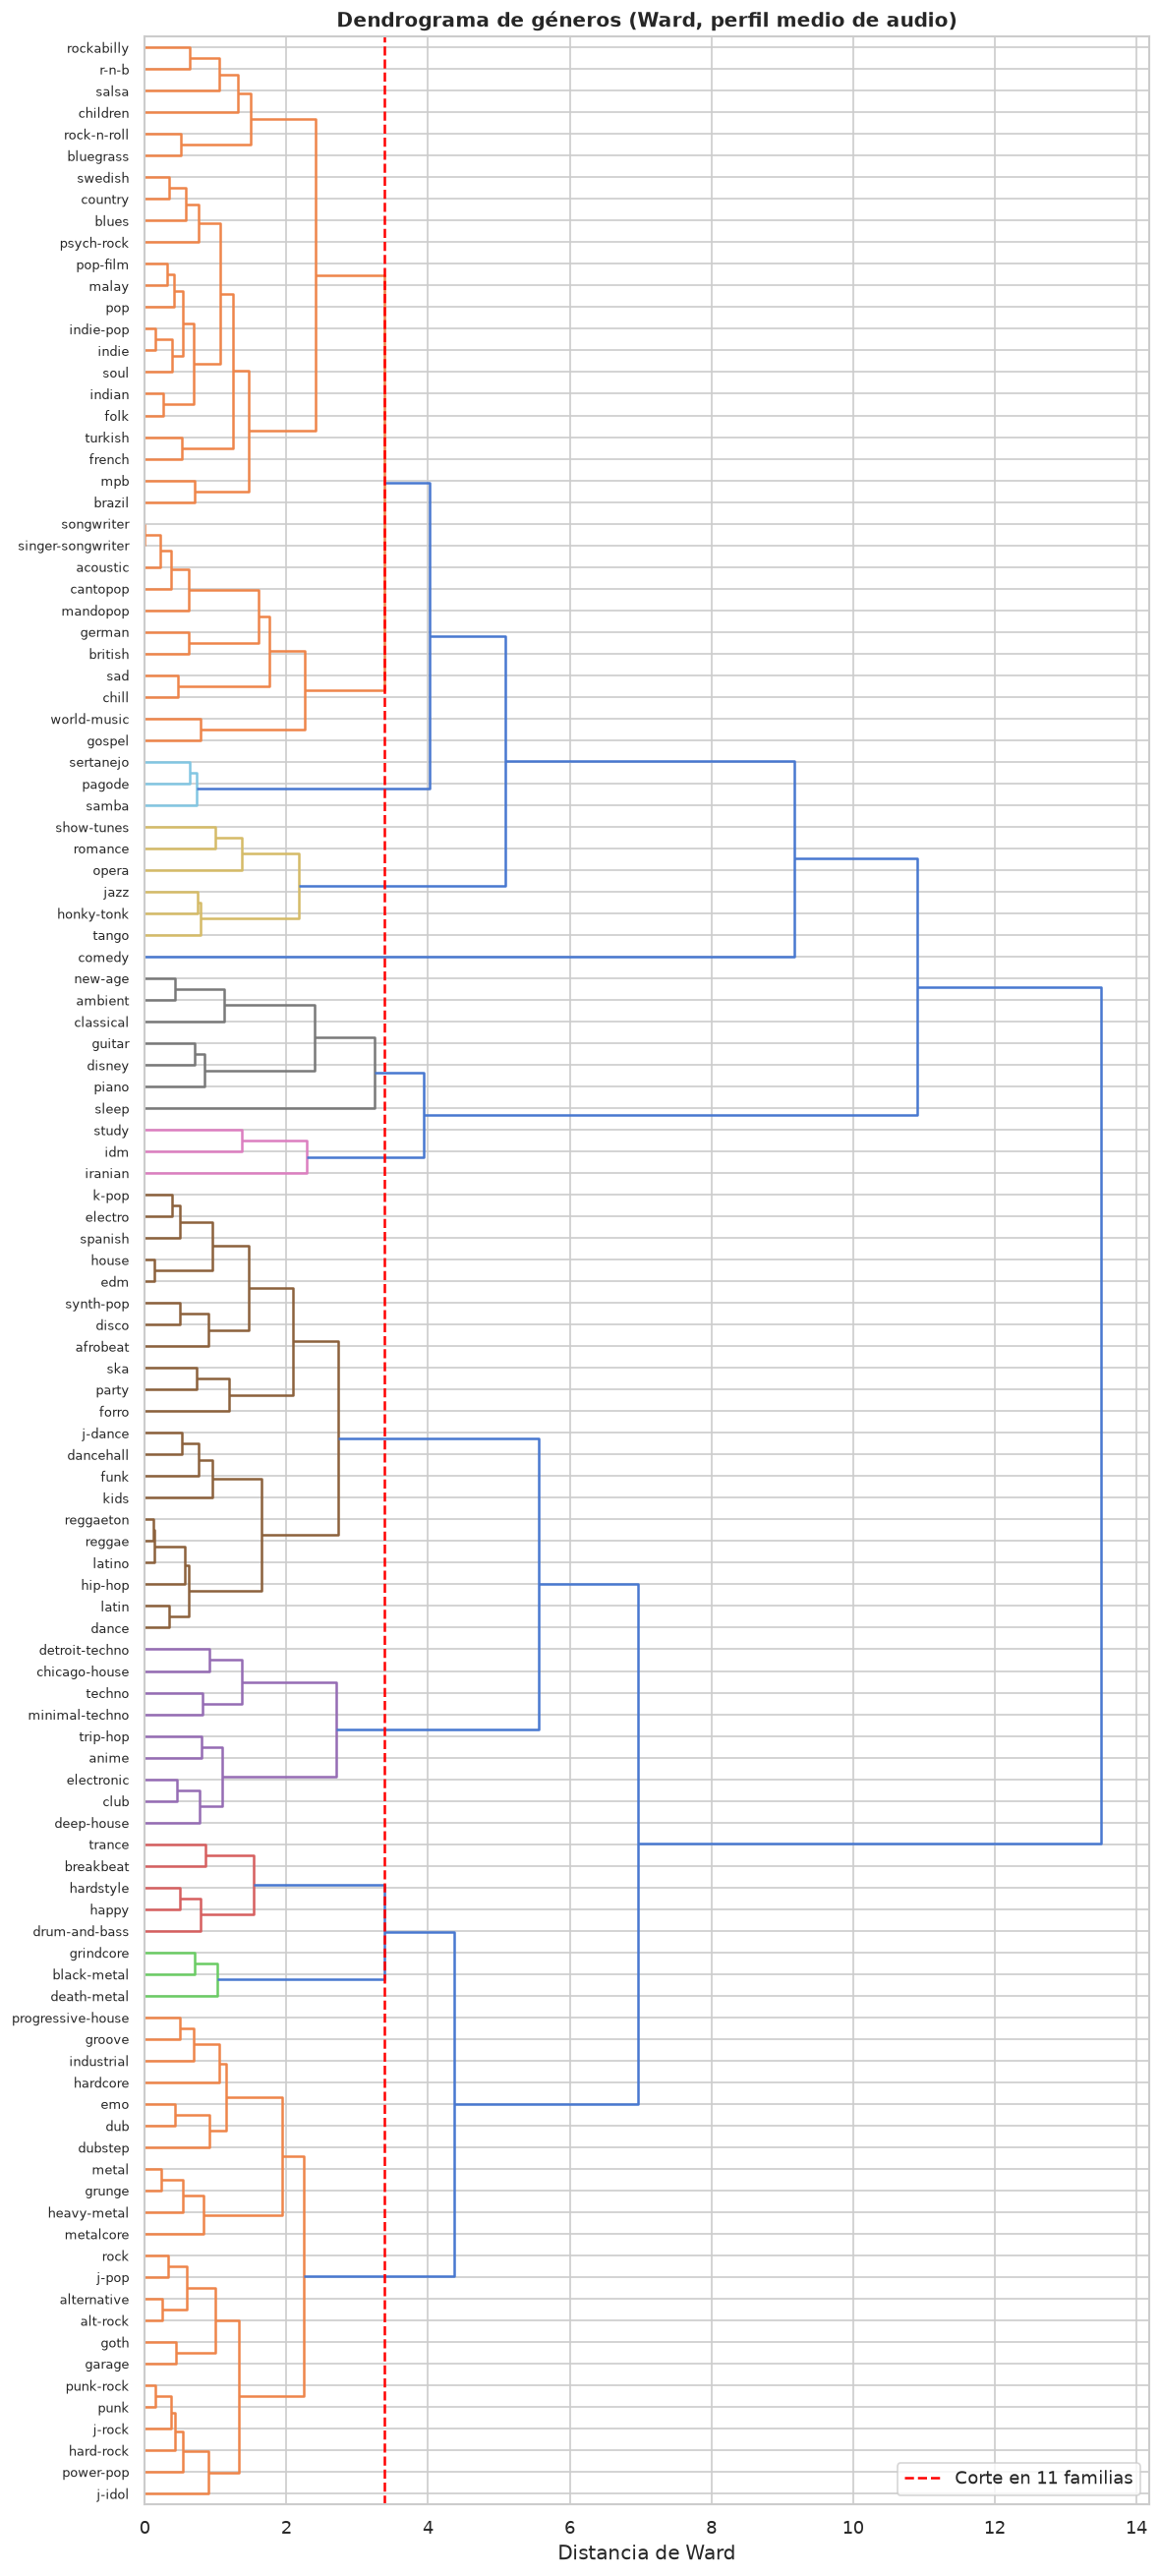

In [32]:
Z_train_df = pd.DataFrame(Z_train, columns=variables_cluster, index=X_train.index)
perfil_genero = pd.DataFrame({
    g.replace('genero_', ''): Z_train_df[X_train[g].eq(1)].mean() for g in columnas_genero
}).T
popularidad_genero = pd.Series({g.replace('genero_', ''): y_train_reg[X_train[g].eq(1)].mean()
                                for g in columnas_genero})
print(f'Matriz de perfiles de género: {perfil_genero.shape}')

filas_fam = []
for k in range(4, 16):
    etiquetas = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(perfil_genero)
    filas_fam.append({'k': k, 'silueta': silhouette_score(perfil_genero, etiquetas),
                      'davies_bouldin': davies_bouldin_score(perfil_genero, etiquetas)})
seleccion_familias = pd.DataFrame(filas_fam).set_index('k')
K_FAMILIAS = int(seleccion_familias.loc[6:12, 'silueta'].idxmax())
display(seleccion_familias.round(3).T)
print(f'Número de familias elegido: {K_FAMILIAS} (máxima silueta dentro del rango 6–12)')

jerarquico = AgglomerativeClustering(n_clusters=K_FAMILIAS, linkage='ward').fit(perfil_genero)
familia_de_genero = pd.Series(jerarquico.labels_, index=perfil_genero.index, name='familia')

enlaces = linkage(perfil_genero, method='ward')
fig, ax = plt.subplots(figsize=(10, 22))
umbral = enlaces[-(K_FAMILIAS - 1), 2]
dendrogram(enlaces, labels=perfil_genero.index.tolist(), orientation='right', leaf_font_size=8,
           color_threshold=umbral, ax=ax)
ax.axvline(umbral, color='red', linestyle='--', label=f'Corte en {K_FAMILIAS} familias')
ax.set_title('Dendrograma de géneros (Ward, perfil medio de audio)', fontweight='bold')
ax.set_xlabel('Distancia de Ward'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '12_dendrograma_generos.png', dpi=150, bbox_inches='tight')
plt.show()

,n_generos,popularidad_media_generos,generos
familia,,,
0,33,38.3000,"acoustic, bluegrass, blues, brazil, british, cantopop, children, chill, country, folk, french, german, gospel, indian, indie, indie-pop, malay, mandopop, mpb, pop, pop-film, psych-rock, r-n-b, rock-n-roll, rockabilly, sad, salsa, singer-songwriter, songwriter, soul, swedish, turkish, world-music"
1,7,31.7000,"ambient, classical, disney, guitar, new-age, piano, sleep"
2,9,33.7000,"anime, chicago-house, club, deep-house, detroit-techno, electronic, minimal-techno, techno, trip-hop"
3,23,36.9000,"alt-rock, alternative, dub, dubstep, emo, garage, goth, groove, grunge, hard-rock, hardcore, heavy-metal, industrial, j-idol, j-pop, j-rock, metal, metalcore, power-pop, progressive-house, punk, punk-rock, rock"
4,21,30.3000,"afrobeat, dance, dancehall, disco, edm, electro, forro, funk, hip-hop, house, j-dance, k-pop, kids, latin, latino, party, reggae, reggaeton, ska, spanish, synth-pop"
5,5,26.3000,"breakbeat, drum-and-bass, happy, hardstyle, trance"
6,6,18.2000,"honky-tonk, jazz, opera, romance, show-tunes, tango"
7,1,24.7000,comedy
8,3,43.9000,"pagode, samba, sertanejo"


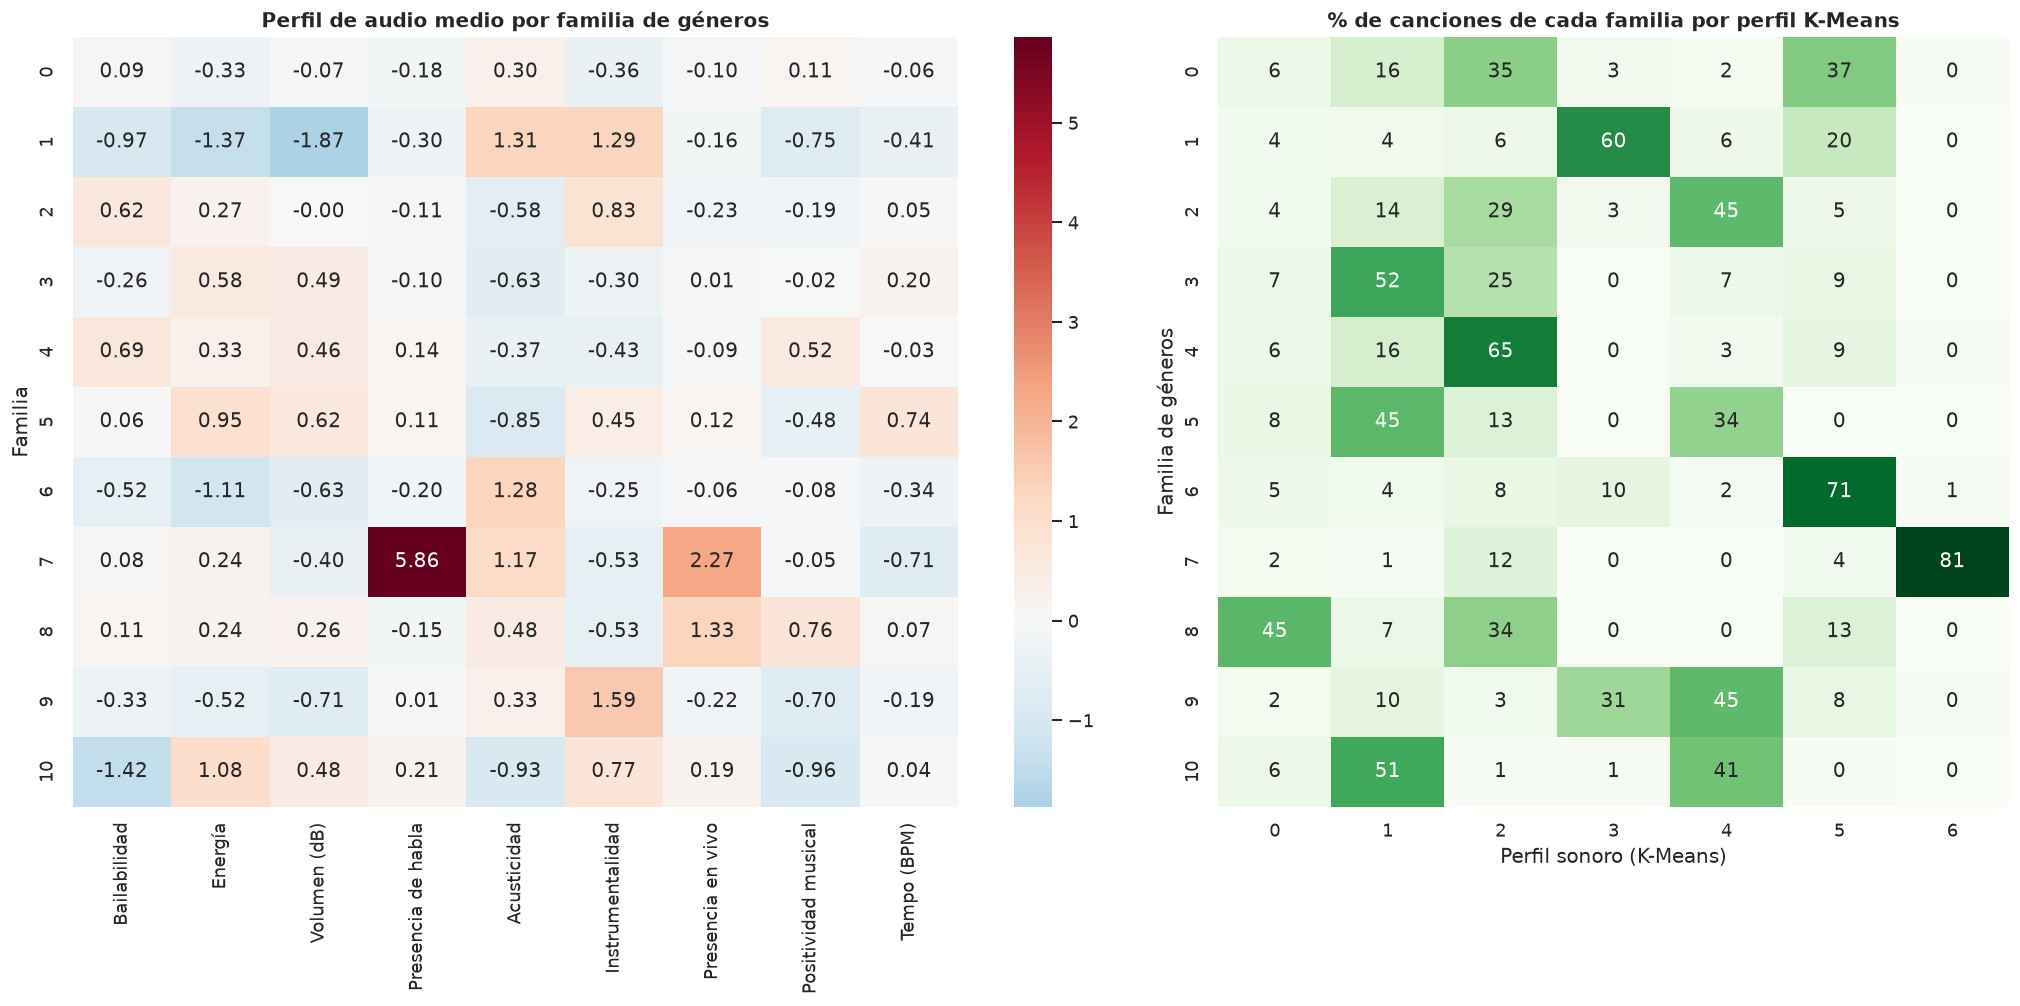

NMI familia de géneros vs. perfil K-Means: 0.230
NMI género (114) vs. perfil K-Means:       0.175


In [33]:
perfil_familia = perfil_genero.groupby(familia_de_genero).mean()
familias = pd.DataFrame({
    'n_generos': familia_de_genero.value_counts().sort_index(),
    'popularidad_media_generos': popularidad_genero.groupby(familia_de_genero).mean().round(1),
    'generos': familia_de_genero.groupby(familia_de_genero).apply(lambda s: ', '.join(sorted(s.index))),
})
pd.set_option('display.max_colwidth', 400)
display(familias)
pd.reset_option('display.max_colwidth')
familia_de_genero.rename_axis('genero_musical').to_csv(PROCESSED_DIR / 'familias_genero.csv')

fig, axes = plt.subplots(1, 2, figsize=(17, 0.55 * K_FAMILIAS + 2.5), gridspec_kw={'width_ratios': [1.4, 1]})
sns.heatmap(perfil_familia.rename(columns=ETIQUETAS), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Perfil de audio medio por familia de géneros', fontweight='bold')
axes[0].set_ylabel('Familia')
# Relación entre las dos técnicas: ¿en qué perfil sonoro (K-Means) caen las canciones de cada familia?
familia_cancion = df_modelo['genero_principal'].iloc[idx_train].map(familia_de_genero).to_numpy()
cruce = pd.crosstab(familia_cancion, perfil_train, normalize='index').mul(100)
sns.heatmap(cruce, annot=True, fmt='.0f', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('% de canciones de cada familia por perfil K-Means', fontweight='bold')
axes[1].set_xlabel('Perfil sonoro (K-Means)'); axes[1].set_ylabel('Familia de géneros')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '13_familias_generos.png', dpi=150, bbox_inches='tight')
plt.show()

nmi_familia_perfil = normalized_mutual_info_score(familia_cancion, perfil_train)
nmi_genero_perfil = normalized_mutual_info_score(df_modelo['genero_principal'].iloc[idx_train], perfil_train)
print(f'NMI familia de géneros vs. perfil K-Means: {nmi_familia_perfil:.3f}')
print(f'NMI género (114) vs. perfil K-Means:       {nmi_genero_perfil:.3f}')

#### 4.5.1 ¿La taxonomía compacta conserva la señal para predecir popularidad?

Se compara, con la misma validación cruzada de entrenamiento y el mismo
`HistGradientBoostingRegressor` (hiperparámetros por defecto), el desempeño usando:
(a) solo audio y categóricas, (b) + familias de géneros (pocas columnas), y (c) + los 114
géneros. Así se cuantifica cuánta información aporta el género y cuánta conserva la
agrupación no supervisada.

In [34]:
columnas_familia = [f'familia_{f}' for f in range(K_FAMILIAS)]
pertenencia = pd.DataFrame(0, index=df_modelo.index, columns=columnas_familia)
for g, f in familia_de_genero.items():
    pertenencia[f'familia_{f}'] |= df_modelo[f'genero_{g}']
X_train_familia = X_train.join(pertenencia.iloc[idx_train])

def cv_hgb(X_, generos):
    pipe = Pipeline([('prep', crear_preprocesador(generos)),
                     ('modelo', HistGradientBoostingRegressor(random_state=SEMILLA))])
    r = cross_validate(pipe, X_, y_train_reg, groups=grupos_train, cv=cv_grupos, scoring=scoring_reg)
    return {'MAE_cv': -r['test_MAE'].mean(), 'RMSE_cv': -r['test_RMSE'].mean(), 'R2_cv': r['test_R2'].mean()}

ablacion = pd.DataFrame({
    'Solo audio + categóricas': cv_hgb(X_train, []),
    f'+ {K_FAMILIAS} familias de géneros': cv_hgb(X_train_familia, columnas_familia),
    '+ 114 géneros': cv_hgb(X_train, columnas_genero),
}).T
ablacion['n_columnas_genero'] = [0, K_FAMILIAS, len(columnas_genero)]
display(ablacion.round(3))

,MAE_cv,RMSE_cv,R2_cv,n_columnas_genero
Solo audio + categóricas,15.6270,19.4980,0.1050,0
+ 11 familias de géneros,14.3930,18.5450,0.1900,11
+ 114 géneros,11.5900,16.1870,0.3830,114


#### Interpretación — familias de géneros (jerárquico Ward, 11 familias)

- La silueta sobre los 114 géneros es 0,274 (k = 11), mayor que la del K-Means sobre
  canciones: **los perfiles medios por género están más separados que las canciones
  individuales**.
- Las familias tienen sentido musical, lo que valida el método:
  - *Ambiental/clásica* (ambient, classical, new-age, piano, sleep, disney, guitar).
  - *Metal extremo* (black-metal, death-metal, grindcore), separada del *rock/metal* general.
  - *Electrónica de club* (techno, house, minimal, detroit, trip-hop).
  - *Bailables/urbanas* (hip-hop, reggaeton, k-pop, dance, latin, edm).
  - *Música brasileña en vivo* (pagode, samba, sertanejo).
  - *Comedia* (sola, por su alta presencia de habla).
  - Una gran familia *pop/folk/cantautor* (33 géneros) muestra que muchas etiquetas de
    género **suenan casi igual**: la diferencia es cultural o de idioma, no acústica.
- **Coherencia entre las dos técnicas:** el cruce familia × perfil muestra
  correspondencias claras (comedia → perfil "habladas" 81%, ambiental → "ambientales"
  60%, bailables → "bailables y alegres" 65%). Aun así, el NMI es moderado: un mismo género
  contiene canciones de varios perfiles.
- **¿Conserva la taxonomía la señal predictiva?** (ablación en CV): agregar las 11
  familias sube el R² de 0,105 (solo audio) a 0,190, pero los 114 géneros llegan a 0,383.
  **El valor predictivo del género es en gran parte cultural** (mercado, idioma, escena),
  no acústico, y por eso se pierde al agrupar por sonido. Recomendación: usar las familias
  para organizar el catálogo y la navegación, y mantener el género detallado para predecir.

## Fase 5: Evaluation

Los modelos finales (ajustados en la Fase 4 solo con entrenamiento) se evalúan **una sola
vez** sobre el conjunto de prueba (17.843 canciones nunca vistas, sin claves
artista + título compartidas con entrenamiento).

### 5.1 Regresión en el conjunto de prueba

In [35]:
baseline_reg = Pipeline([('prep', crear_preprocesador()), ('modelo', DummyRegressor())]).fit(X_train, y_train_reg)
predicciones_reg = {'Baseline (media)': baseline_reg.predict(X_test)}
for nombre, modelo in regresores.items():
    predicciones_reg[nombre] = modelo.predict(X_test)

resultados_test_reg = pd.DataFrame({
    nombre: {'MAE': mean_absolute_error(y_test_reg, p),
             'RMSE': root_mean_squared_error(y_test_reg, p),
             'R2': r2_score(y_test_reg, p)}
    for nombre, p in predicciones_reg.items()
}).T
mae_base = resultados_test_reg.loc['Baseline (media)', 'MAE']
resultados_test_reg['mejora_MAE_vs_baseline_%'] = 100 * (1 - resultados_test_reg['MAE'] / mae_base)
resultados_test_reg['MAE_cv'] = resultados_cv_reg['MAE_cv']
resultados_test_reg.to_csv(PROCESSED_DIR / 'resultados_test_regresion.csv')
display(resultados_test_reg.round(3))

MEJOR_REGRESOR = resultados_test_reg.drop('Baseline (media)')['MAE'].idxmin()
mejor_cv_reg = resultados_cv_reg.drop('Baseline (media)')['MAE_cv'].idxmin()
print(f'Mejor regresor en prueba (MAE): {MEJOR_REGRESOR} | mejor en CV: {mejor_cv_reg}')
# La selección oficial se hace con la validación cruzada, para no "elegir con el test".
MEJOR_REGRESOR = mejor_cv_reg

,MAE,RMSE,R2,mejora_MAE_vs_baseline_%,MAE_cv
Baseline (media),17.1670,20.5280,-0.0000,0.0000,17.2680
Ridge,11.8570,16.5270,0.3520,30.9330,11.8630
KNN,13.0870,17.9550,0.2350,23.7660,13.4970
Random Forest,11.0570,15.7870,0.4090,35.5930,11.3440
HistGradientBoosting,11.0480,15.7710,0.4100,35.6420,11.1660


Mejor regresor en prueba (MAE): HistGradientBoosting | mejor en CV: HistGradientBoosting


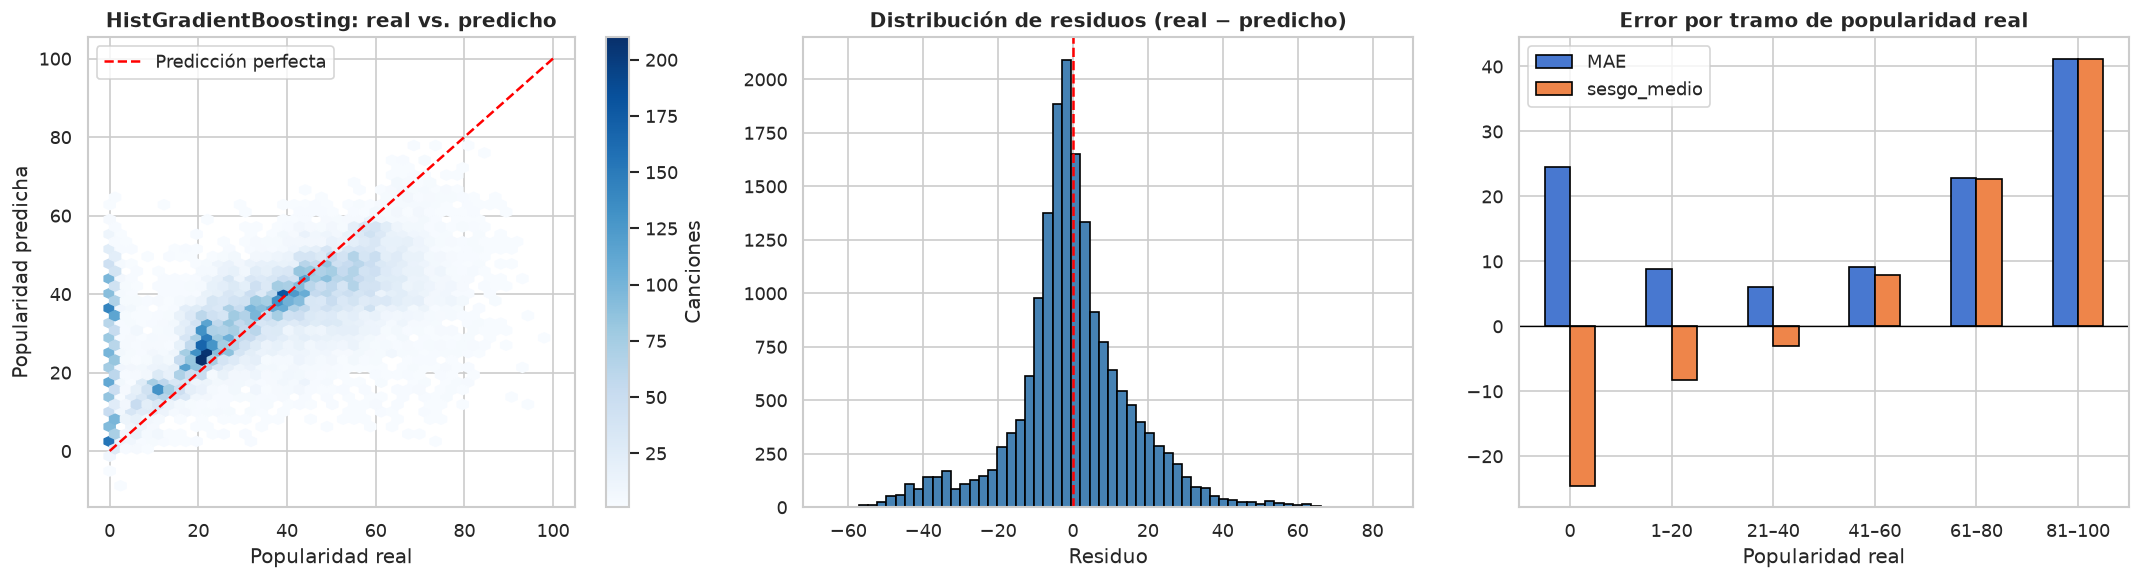

,canciones,MAE,sesgo_medio
tramo,,,
0,1800,24.5800,-24.5700
1–20,3122,8.8100,-8.2500
21–40,6037,6.0000,-3.1200
41–60,5099,9.1400,7.8800
61–80,1689,22.8400,22.6800
81–100,96,41.2100,41.2100


In [36]:
pred = predicciones_reg[MEJOR_REGRESOR]
residuos = y_test_reg.to_numpy() - pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hb = axes[0].hexbin(y_test_reg, pred, gridsize=40, cmap='Blues', mincnt=1)
axes[0].plot([0, 100], [0, 100], color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Popularidad real'); axes[0].set_ylabel('Popularidad predicha')
axes[0].set_title(f'{MEJOR_REGRESOR}: real vs. predicho', fontweight='bold'); axes[0].legend()
fig.colorbar(hb, ax=axes[0], label='Canciones')
axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de residuos (real − predicho)', fontweight='bold'); axes[1].set_xlabel('Residuo')
tramos = pd.cut(y_test_reg, [-0.1, 0.5, 20, 40, 60, 80, 100.1], labels=['0', '1–20', '21–40', '41–60', '61–80', '81–100'])
error_tramo = pd.DataFrame({'tramo': tramos, 'error_abs': np.abs(residuos), 'sesgo': residuos}).groupby('tramo', observed=True)
error_tramo.agg(MAE=('error_abs', 'mean'), sesgo_medio=('sesgo', 'mean'))[['MAE', 'sesgo_medio']].plot.bar(ax=axes[2], edgecolor='black')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Error por tramo de popularidad real', fontweight='bold'); axes[2].set_xlabel('Popularidad real')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '14_regresion_test.png', dpi=150, bbox_inches='tight')
plt.show()
display(error_tramo.agg(canciones=('error_abs', 'size'), MAE=('error_abs', 'mean'), sesgo_medio=('sesgo', 'mean')).round(2))

#### Interpretación — regresión en prueba

- **HistGradientBoosting: MAE 11,05, RMSE 15,77, R² 0,410**, un 35,6% menos error que el
  baseline. Las métricas de prueba son iguales o algo mejores que las de CV, así que **no
  hay sobreajuste** y la partición sin fuga funciona como se esperaba.
- **Dónde falla:** el modelo **se contrae hacia la media**.
  - Las canciones con popularidad **0** se sobreestiman en ~25 puntos. Muchas son
    reediciones con otro ID cuya versión principal sí es popular: el audio y el género no
    pueden distinguirlas (ruido de la fuente, ver Fase 3).
  - Los **éxitos (61–100) se subestiman** entre 23 y 41 puntos. La popularidad extrema
    depende de factores ausentes en los datos: artista, marketing, inclusión en playlists,
    fecha de lanzamiento.
  - En el rango 21–40, donde está la mayoría del catálogo, el MAE es de solo 6 puntos.
- **Implicación:** el regresor sirve para estimar el **nivel general** de una canción, pero
  no para identificar éxitos individuales. Para esa tarea conviene el clasificador con
  ranking de probabilidad (5.2).

### 5.2 Clasificación en el conjunto de prueba

In [37]:
baseline_clf = PipelineImb([('prep', crear_preprocesador()),
                            ('modelo', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train_clf)
modelos_eval_clf = {'Baseline (clase mayoritaria)': baseline_clf, **clasificadores}
filas = {}
probabilidades = {}
for nombre, modelo in modelos_eval_clf.items():
    p = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)
    probabilidades[nombre] = pd.DataFrame(proba, columns=modelo.classes_, index=X_test.index)
    filas[nombre] = {
        'balanceo': resultados_cv_clf.loc[nombre, 'balanceo'] if nombre in resultados_cv_clf.index else '—',
        'Accuracy': accuracy_score(y_test_clf, p),
        'Balanced_acc': balanced_accuracy_score(y_test_clf, p),
        'F1_macro': f1_score(y_test_clf, p, average='macro'),
        'Recall_alto': recall_score(y_test_clf, p, labels=['alto'], average='macro', zero_division=0),
        'Precision_alto': precision_score(y_test_clf, p, labels=['alto'], average='macro', zero_division=0),
        'ROC_AUC_ovr': roc_auc_score(y_test_clf, proba, multi_class='ovr', labels=modelo.classes_),
    }
resultados_test_clf = pd.DataFrame(filas).T
resultados_test_clf['F1_macro_cv'] = resultados_cv_clf['F1_macro_cv']
resultados_test_clf.to_csv(PROCESSED_DIR / 'resultados_test_clasificacion.csv')
display(resultados_test_clf.round(3))

MEJOR_CLASIFICADOR = resultados_cv_clf.drop('Baseline (clase mayoritaria)')['F1_macro_cv'].astype(float).idxmax()
print(f'Mejor clasificador según CV (F1 macro): {MEJOR_CLASIFICADOR}')
print(f'Mejor en prueba (F1 macro): {resultados_test_clf.drop("Baseline (clase mayoritaria)")["F1_macro"].astype(float).idxmax()}')

,balanceo,Accuracy,Balanced_acc,F1_macro,Recall_alto,Precision_alto,ROC_AUC_ovr,F1_macro_cv
Baseline (clase mayoritaria),—,0.4485,0.3333,0.2064,0.0000,0.0000,0.5000,0.2080
Regresión logística,SMOTE,0.6695,0.6790,0.6252,0.7089,0.3235,0.8529,0.6200
KNN,ROS,0.6091,0.6203,0.5689,0.6547,0.2761,0.7932,0.5500
Random Forest,ROS,0.7382,0.6799,0.6781,0.5051,0.4870,0.8794,0.6720
HistGradientBoosting,SMOTE,0.7363,0.6754,0.6734,0.4934,0.4737,0.8805,0.6680


Mejor clasificador según CV (F1 macro): Random Forest
Mejor en prueba (F1 macro): Random Forest


              precision    recall  f1-score   support

        bajo      0.810     0.758     0.784      8003
       medio      0.735     0.776     0.755      7868
        alto      0.487     0.505     0.496      1972

    accuracy                          0.738     17843
   macro avg      0.677     0.680     0.678     17843
weighted avg      0.741     0.738     0.739     17843



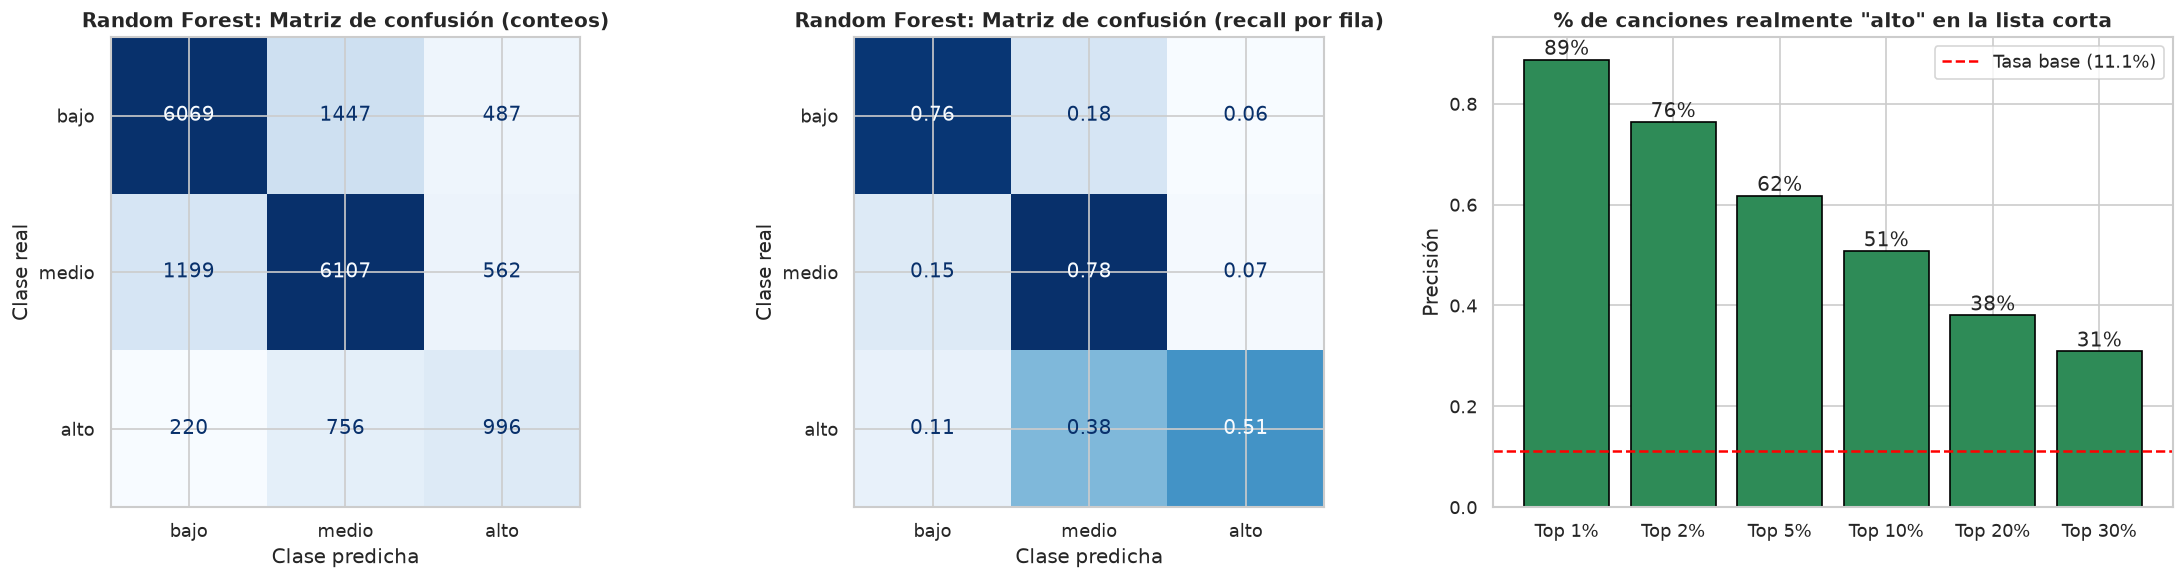

,lista_corta,precision_alto,lift_vs_azar
0,Top 1%,0.8880,8.0320
1,Top 2%,0.7640,6.9130
2,Top 5%,0.6180,5.5890
3,Top 10%,0.5080,4.5950
4,Top 20%,0.3810,3.4440
5,Top 30%,0.3090,2.7960


In [38]:
modelo_clf = clasificadores[MEJOR_CLASIFICADOR]
pred_clf = modelo_clf.predict(X_test)
print(classification_report(y_test_clf, pred_clf, labels=ETIQUETAS_CLASE, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, normalizar, titulo in [(axes[0], None, 'Matriz de confusión (conteos)'),
                               (axes[1], 'true', 'Matriz de confusión (recall por fila)')]:
    ConfusionMatrixDisplay.from_predictions(y_test_clf, pred_clf, labels=ETIQUETAS_CLASE, normalize=normalizar,
                                            values_format='.2f' if normalizar else 'd', cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'{MEJOR_CLASIFICADOR}: {titulo}', fontweight='bold')
    ax.set_xlabel('Clase predicha'); ax.set_ylabel('Clase real')

# Lectura de negocio: precisión de una lista corta ordenada por probabilidad de "alto"
p_alto = probabilidades[MEJOR_CLASIFICADOR]['alto']
es_alto = y_test_clf.eq('alto')
porcentajes = [1, 2, 5, 10, 20, 30]
precision_top = [es_alto[p_alto.rank(ascending=False, method='first') <= len(p_alto) * q / 100].mean() for q in porcentajes]
axes[2].bar([f'Top {q}%' for q in porcentajes], precision_top, color='seagreen', edgecolor='black')
axes[2].axhline(es_alto.mean(), color='red', linestyle='--', label=f'Tasa base ({es_alto.mean():.1%})')
for x, v in enumerate(precision_top):
    axes[2].text(x, v, f'{v:.0%}', ha='center', va='bottom')
axes[2].set_title('% de canciones realmente "alto" en la lista corta', fontweight='bold')
axes[2].set_ylabel('Precisión'); axes[2].legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '15_clasificacion_test.png', dpi=150, bbox_inches='tight')
plt.show()
lift = pd.DataFrame({'lista_corta': [f'Top {q}%' for q in porcentajes], 'precision_alto': precision_top})
lift['lift_vs_azar'] = lift['precision_alto'] / es_alto.mean()
display(lift.round(3))

#### Interpretación — clasificación en prueba

- **Random Forest + ROS:** accuracy 0,738, F1 macro 0,678, ROC-AUC 0,879. Las métricas de
  prueba coinciden con las de CV (0,672), lo que confirma la estabilidad del modelo.
- Por clase: "bajo" y "medio" se reconocen bien (F1 ≈ 0,78 y 0,76). La clase **"alto"** es
  la difícil (precisión 0,49, recall 0,51), y su error típico es confundirse con "medio"
  (38%), casi nunca con "bajo" (11%). **Los errores son entre clases vecinas.**
- **Valor de negocio (lista corta):** ordenando las canciones por probabilidad de "alto":
  - en el **1% superior, 89% son realmente populares** (8× la tasa base de 11%);
  - en el 5% superior, el 62%;
  - en el 10% superior, el 51%.

  Un curador que revise solo las 180 canciones mejor rankeadas de un lote de ~18.000
  encuentra 160 éxitos. Es el uso recomendado: **priorizar la escucha humana**, no
  decidir automáticamente.
- **Trade-off:** si el negocio prefiere no dejar pasar posibles éxitos, la regresión
  logística + SMOTE alcanza recall "alto" de 0,71, pero con precisión de 0,32 (más
  canciones que revisar).

### 5.3 Importancia de variables y sesgo por género

- **Importancia por permutación** (sobre una muestra de 5.000 canciones de prueba): mide
  cuánto empeora el MAE del mejor regresor al desordenar una variable. Las 114 columnas de
  género se permutan **juntas**, como una sola variable "género musical", para que sea
  comparable con las demás. A diferencia de la importancia interna de los árboles, no
  favorece variables con muchos valores distintos.
- **Error por género:** compromiso de la EP1 (matriz de riesgos): el error no debe
  evaluarse solo de forma global.

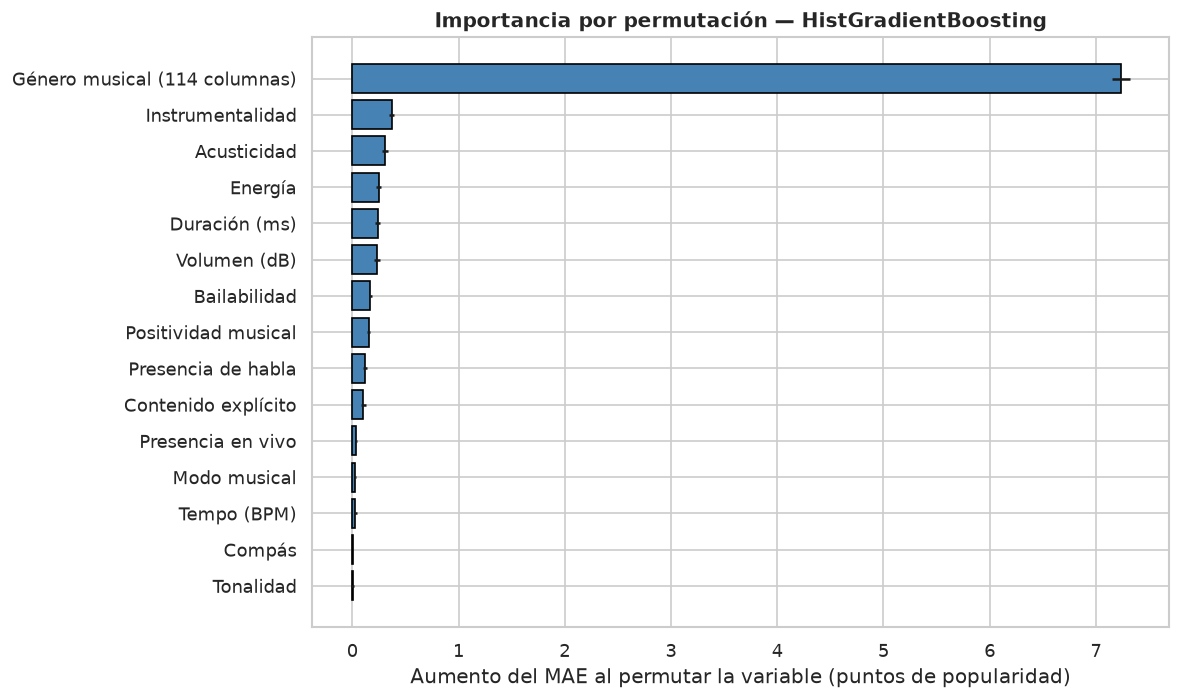

,aumento_MAE,std
variable,,
Género musical (114 columnas),7.2340,0.0850
Instrumentalidad,0.3720,0.0240
Acusticidad,0.3100,0.0260
Energía,0.2480,0.0210
Duración (ms),0.2410,0.0230
Volumen (dB),0.2310,0.0290
Bailabilidad,0.1700,0.0170
Positividad musical,0.1540,0.0110
Presencia de habla,0.1200,0.0160


In [39]:
def importancia_permutacion(modelo, X_, y_, grupos_variables, repeticiones=5):
    base = mean_absolute_error(y_, modelo.predict(X_))
    rng_local = np.random.default_rng(SEMILLA)
    filas = []
    for nombre, columnas in grupos_variables.items():
        aumentos = []
        for _ in range(repeticiones):
            Xp = X_.copy()
            orden = rng_local.permutation(len(Xp))
            Xp[columnas] = Xp[columnas].to_numpy()[orden]
            aumentos.append(mean_absolute_error(y_, modelo.predict(Xp)) - base)
        filas.append({'variable': nombre, 'aumento_MAE': np.mean(aumentos), 'std': np.std(aumentos)})
    return pd.DataFrame(filas).set_index('variable').sort_values('aumento_MAE')

muestra_test = X_test.sample(5_000, random_state=SEMILLA)
grupos_variables = {ETIQUETAS[c]: [c] for c in variables_numericas + variables_categoricas_modelo}
grupos_variables['Género musical (114 columnas)'] = columnas_genero
importancia = importancia_permutacion(regresores[MEJOR_REGRESOR], muestra_test,
                                      y_test_reg.loc[muestra_test.index], grupos_variables)
importancia.to_csv(PROCESSED_DIR / 'importancia_permutacion.csv')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancia.index, importancia['aumento_MAE'], xerr=importancia['std'], color='steelblue', edgecolor='black')
ax.set_title(f'Importancia por permutación — {MEJOR_REGRESOR}', fontweight='bold')
ax.set_xlabel('Aumento del MAE al permutar la variable (puntos de popularidad)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '16_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
display(importancia.sort_values('aumento_MAE', ascending=False).round(3))

MAE global: 11.05 | MAE por género: mín 2.60, máx 32.90
Géneros con MAE > 1,5 × global: 23 de 114
Género "sleep" (afectado por la limpieza en EP1): MAE 10.74, n = 174


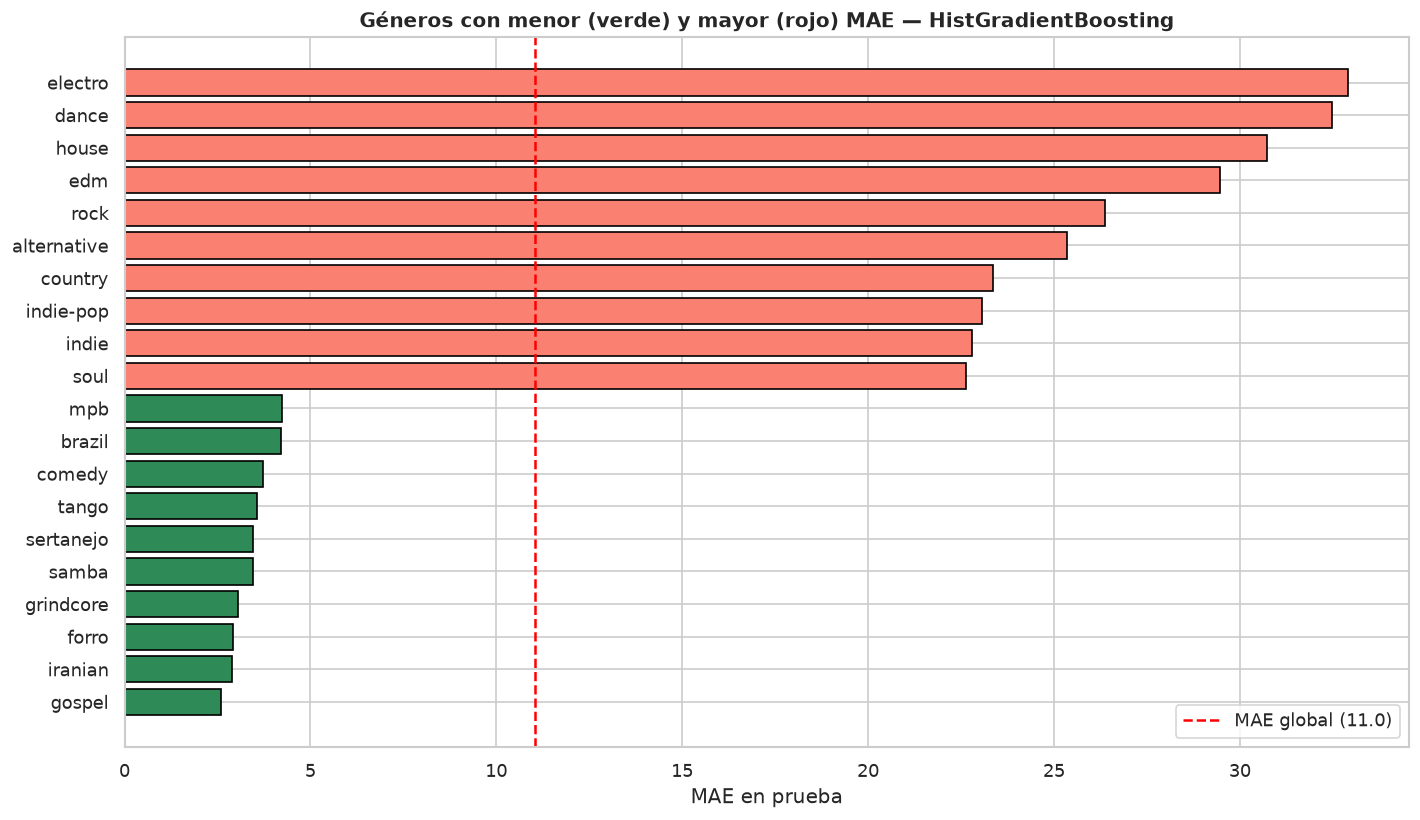

,canciones_test,popularidad_media,MAE,sesgo_medio
genero,,,,
gospel,195,41.6500,2.6000,0.4300
iranian,188,2.0900,2.8800,-0.9200
forro,200,41.6700,2.9200,0.4700
grindcore,213,14.5400,3.0600,-0.8700
samba,207,38.4300,3.4400,0.2300
sertanejo,181,47.8500,3.4500,0.4400
tango,194,20.1200,3.5600,-0.5400
comedy,185,24.5100,3.7300,-0.6600
brazil,189,45.1800,4.2200,0.6700


Correlación entre popularidad media del género y su MAE: 0.04


In [40]:
filas_genero = []
abs_error = np.abs(y_test_reg.to_numpy() - predicciones_reg[MEJOR_REGRESOR])
for g in columnas_genero:
    mascara = X_test[g].eq(1).to_numpy()
    if mascara.sum() >= 30:
        filas_genero.append({'genero': g.replace('genero_', ''), 'canciones_test': int(mascara.sum()),
                             'popularidad_media': y_test_reg.to_numpy()[mascara].mean(),
                             'MAE': abs_error[mascara].mean(),
                             'sesgo_medio': (y_test_reg.to_numpy() - predicciones_reg[MEJOR_REGRESOR])[mascara].mean()})
error_genero = pd.DataFrame(filas_genero).set_index('genero').sort_values('MAE')
error_genero.to_csv(PROCESSED_DIR / 'errores_por_genero.csv')
mae_global = abs_error.mean()
print(f'MAE global: {mae_global:.2f} | MAE por género: mín {error_genero["MAE"].min():.2f}, '
      f'máx {error_genero["MAE"].max():.2f}')
print(f'Géneros con MAE > 1,5 × global: {(error_genero["MAE"] > 1.5 * mae_global).sum()} de {len(error_genero)}')
if 'sleep' in error_genero.index:
    print(f'Género "sleep" (afectado por la limpieza en EP1): MAE {error_genero.loc["sleep", "MAE"]:.2f}, '
          f'n = {error_genero.loc["sleep", "canciones_test"]}')

fig, ax = plt.subplots(figsize=(12, 7))
extremos = pd.concat([error_genero.head(10), error_genero.tail(10)])
colores = ['seagreen'] * 10 + ['salmon'] * 10
ax.barh(extremos.index, extremos['MAE'], color=colores, edgecolor='black')
ax.axvline(mae_global, color='red', linestyle='--', label=f'MAE global ({mae_global:.1f})')
ax.set_title(f'Géneros con menor (verde) y mayor (rojo) MAE — {MEJOR_REGRESOR}', fontweight='bold')
ax.set_xlabel('MAE en prueba'); ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '17_error_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()
display(extremos.round(2))
print(f'Correlación entre popularidad media del género y su MAE: '
      f'{error_genero["popularidad_media"].corr(error_genero["MAE"]):.2f}')

#### Interpretación — importancia y sesgo

- **El género es por lejos la variable más importante.** Permutarlo aumenta el MAE en 7,2
  puntos; la siguiente variable, instrumentalidad, solo en 0,37. Le siguen acusticidad,
  energía, duración y volumen. Tempo, compás y tonalidad casi no aportan, lo que coincide
  con las correlaciones de la EP1. Respuesta al problema de negocio: **los atributos de
  audio por sí solos explican poco** (R² ≈ 0,10). El contexto de género es lo que hace útil
  al modelo.
- **Sesgo por género:** el error es **muy desigual**, con MAE de 2,6 (gospel, forró,
  samba) a 32,9 (electro, dance, house, edm). En 23 de 114 géneros el MAE supera en 50% al
  global.
  - No depende de la popularidad media del género (r = 0,04). Depende de su
    **heterogeneidad**: los géneros con error alto mezclan muchos éxitos y muchas
    reediciones con popularidad 0.
  - Las recomendaciones del modelo para electrónica, dance, rock, indie y country deben
    tomarse con mayor cautela.
- **Género `sleep`** (el más afectado por la limpieza de EP1): MAE 10,7, similar al
  global. **No se observa que la eliminación de ceros lo haya perjudicado** en el
  desempeño.

### 5.4 Cumplimiento de KPIs

In [41]:
r_reg = resultados_test_reg.loc[MEJOR_REGRESOR]
r_clf = resultados_test_clf.loc[MEJOR_CLASIFICADOR]
kpis = pd.DataFrame([
    ('Cobertura de datos', 'Calidad', '≥ 0,99', len(df_limpio) / len(df_crudo), len(df_limpio) / len(df_crudo) >= 0.99),
    ('Claves artista+título compartidas train/test', 'Calidad', '0', len(compartidas), len(compartidas) == 0),
    (f'MAE ({MEJOR_REGRESOR})', 'Regresión', '< 10', r_reg['MAE'], r_reg['MAE'] < 10),
    (f'RMSE ({MEJOR_REGRESOR})', 'Regresión', '< 15', r_reg['RMSE'], r_reg['RMSE'] < 15),
    (f'R² ({MEJOR_REGRESOR})', 'Regresión', '> 0,20', r_reg['R2'], r_reg['R2'] > 0.20),
    (f'Accuracy ({MEJOR_CLASIFICADOR})', 'Clasificación', '> 0,50', r_clf['Accuracy'], r_clf['Accuracy'] > 0.50),
    (f'F1 macro ({MEJOR_CLASIFICADOR})', 'Clasificación', '> 0,45', r_clf['F1_macro'], r_clf['F1_macro'] > 0.45),
    (f'Recall "alto" ({MEJOR_CLASIFICADOR})', 'Clasificación', '≥ 0,60', r_clf['Recall_alto'], r_clf['Recall_alto'] >= 0.60),
    (f'Silueta K-Means (k={K_PERFILES}, prueba)', 'No supervisado', '≥ 0,15', metricas_kmeans['silueta_test'],
     metricas_kmeans['silueta_test'] >= 0.15),
], columns=['KPI', 'Tipo', 'Umbral', 'Valor', 'Cumple'])
kpis['Valor'] = kpis['Valor'].astype(float).round(3)
kpis['Cumple'] = np.where(kpis['Cumple'], '✅ Sí', '❌ No')
kpis.to_csv(PROCESSED_DIR / 'kpis_ep2.csv', index=False)
display(kpis)

,KPI,Tipo,Umbral,Valor,Cumple
0,Cobertura de datos,Calidad,"≥ 0,99",0.9990,✅ Sí
1,Claves artista+título compartidas train/test,Calidad,0,0.0000,✅ Sí
2,MAE (HistGradientBoosting),Regresión,< 10,11.0480,❌ No
3,RMSE (HistGradientBoosting),Regresión,< 15,15.7710,❌ No
4,R² (HistGradientBoosting),Regresión,"> 0,20",0.4100,✅ Sí
5,Accuracy (Random Forest),Clasificación,"> 0,50",0.7380,✅ Sí
6,F1 macro (Random Forest),Clasificación,"> 0,45",0.6780,✅ Sí
7,"Recall ""alto"" (Random Forest)",Clasificación,"≥ 0,60",0.5050,❌ No
8,"Silueta K-Means (k=7, prueba)",No supervisado,"≥ 0,15",0.1920,✅ Sí


#### Interpretación de KPIs

| KPI no cumplido | Valor | Lectura |
|---|---|---|
| MAE < 10 | 11,05 | Faltan ~1 punto. El error se concentra en extremos (ceros por reediciones y éxitos) que dependen de información ausente. |
| RMSE < 15 | 15,77 | El RMSE penaliza esos errores grandes en los extremos. |
| Recall "alto" ≥ 0,60 | 0,51 (RF) | El modelo con mejor F1 macro sacrifica recall. La regresión logística + SMOTE sí lo cumple (0,71), con menor precisión. El umbral de decisión de RF también podría bajarse. |

Se cumplen los KPIs de calidad, R² (0,41 > 0,20), accuracy, F1 macro y silueta. Los
umbrales se mantuvieron como se definieron antes de evaluar, sin ajustarlos para "pasar".

## Fase 6: Deployment (propuesta)

Se serializan los artefactos necesarios para reutilizar los modelos sin reentrenar.
Cada archivo es un **pipeline completo** (preprocesamiento + modelo), por lo que recibe
las variables originales en el mismo formato que `X` (sección 3.13).

In [42]:
artefactos = {
    'regresor_popularidad.joblib': regresores[MEJOR_REGRESOR],
    'clasificador_popularidad.joblib': clasificadores[MEJOR_CLASIFICADOR],
    'kmeans_perfiles_sonoros.joblib': Pipeline([('escalador', escalador_cluster), ('kmeans', kmeans)]),
    'familias_genero.joblib': familia_de_genero,
}
LIMITE_MB = 50  # GitHub rechaza archivos > 100 MB; se deja margen.
for archivo, objeto in artefactos.items():
    ruta = MODELS_DIR / archivo
    joblib.dump(objeto, ruta, compress=('xz', 6))
    tamano = ruta.stat().st_size / 1e6
    if tamano > LIMITE_MB:
        ruta.unlink()
        print(f'{archivo}: {tamano:.1f} MB > {LIMITE_MB} MB, no se guarda (se regenera ejecutando este notebook).')
    else:
        print(f'{archivo}: {tamano:.2f} MB')

def cargar_o_usar(archivo, objeto_en_memoria):
    ruta = MODELS_DIR / archivo
    return joblib.load(ruta) if ruta.is_file() else objeto_en_memoria

# Ejemplo de uso: cargar y predecir 3 canciones de prueba
regresor_cargado = cargar_o_usar('regresor_popularidad.joblib', regresores[MEJOR_REGRESOR])
clasificador_cargado = cargar_o_usar('clasificador_popularidad.joblib', clasificadores[MEJOR_CLASIFICADOR])
ejemplo = X_test.head(3)
display(pd.DataFrame({
    'cancion': df_modelo['nombre_cancion'].iloc[idx_test[:3]].to_numpy(),
    'popularidad_real': y_test_reg.head(3).to_numpy(),
    'popularidad_predicha': regresor_cargado.predict(ejemplo).round(1),
    'clase_real': y_test_clf.head(3).to_numpy(),
    'clase_predicha': clasificador_cargado.predict(ejemplo),
    'prob_alto': clasificador_cargado.predict_proba(ejemplo)[:, list(clasificador_cargado.classes_).index('alto')].round(3),
}))

regresor_popularidad.joblib: 1.34 MB


clasificador_popularidad.joblib: 28.36 MB
kmeans_perfiles_sonoros.joblib: 0.03 MB
familias_genero.joblib: 0.00 MB


,cancion,popularidad_real,popularidad_predicha,clase_real,clase_predicha,prob_alto
0,Addiction,21.0000,21.5000,bajo,bajo,0.1460
1,"Hips, Tits, Lips, Power!",20.0000,35.7000,bajo,bajo,0.2810
2,Got You On My Mind,58.0000,46.1000,medio,medio,0.4170


**Uso propuesto y monitoreo**

| Aspecto | Propuesta |
|---|---|
| Uso | Herramienta de **apoyo** a la curaduría: ordenar lanzamientos por probabilidad de "alto" y proponer una lista corta para revisión humana; los perfiles sonoros y familias de géneros alimentan playlists temáticas. No se usa para decisiones automáticas sobre artistas. |
| Entradas | Atributos de audio de la API de Spotify, género(s), contenido explícito, tonalidad, modo y compás. |
| Monitoreo | Recalcular mensualmente MAE, F1 macro y recall "alto" con canciones nuevas cuya popularidad ya se observó; vigilar la deriva de las variables de entrada (p. ej., distribución de energía y géneros) y el error por género. |
| Reentrenamiento | Cuando el F1 macro caiga más de 0,05 respecto de esta línea base, o se incorporen géneros nuevos. |
| Riesgos | Ciclo de retroalimentación (lo que se promociona se vuelve popular), popularidad dependiente del momento de extracción, sesgo de la limpieza sobre `sleep`. Mantener supervisión humana. |

## Conclusiones y recomendaciones

1. **Metodología:** se completó el ciclo CRISP-DM. La revisión del EP1 corrigió una fuga de
   información real (1.894 canciones artista + título habrían quedado en train y test), la
   sobrerrepresentación multi-género y un target de clasificación sin significado de negocio.
2. **Regresión:** HistGradientBoosting es el mejor modelo (MAE 11,05; R² 0,41; 36% menos
   error que el baseline). Es útil para estimar el nivel general de una canción, no para
   predecir éxitos puntuales.
3. **Clasificación:** Random Forest + sobremuestreo aleatorio (F1 macro 0,68; AUC 0,88).
   Su mayor valor está en **rankear**: el 1% superior tiene 89% de canciones realmente
   populares.
4. **Balanceo:** sin balancear, los modelos ignoran la clase "alto" (recall < 0,3).
   Sobremuestreo (ROS/SMOTE) maximiza el F1 macro; `class_weight` maximiza el recall de
   "alto" sin aumentar los datos. SMOTENC no compensó su costo.
5. **No supervisado:** K-Means encontró 7 perfiles sonoros estables y generalizables. Los
   "bailables y alegres" e "intensos" concentran la mayor tasa de éxitos. El clustering
   jerárquico redujo 114 géneros a 11 familias coherentes y reveló que muchas etiquetas de
   género son acústicamente equivalentes.
6. **Hallazgo central:** la popularidad depende más del **contexto cultural del género**
   que del sonido. El audio explica ~10% de la varianza; con género, ~40%.
7. **Recomendaciones:**
   - Usar el clasificador como **filtro de priorización** para curadores, con revisión humana.
   - Usar los perfiles sonoros para playlists por contexto.
   - Para mejorar, incorporar variables de artista (seguidores, historial), fecha de
     lanzamiento y exposición en playlists.
   - Deduplicar las reediciones por artista + título en la fuente.
   - Monitorear el error por género.